# Homework 3 — Kernel and Non-Kernel Learning Under Real-World Data Imperfections

## Dataset 1: Airbnb Open Data — Five-City Listings

This notebook starts the first real-world dataset of the project: Airbnb listings data collected from five cities: Amsterdam, Barcelona, Chicago, New York, and Madrid.

The goal is not only to train machine learning models, but also to investigate how real-world data problems such as missing values, outliers, redundant features, leakage, and biased labels affect model performance.

For the combined five-city Airbnb dataset, we will solve two prediction tasks:

1. **Regression Task:** Predict the listing price.
2. **Classification Task:** Predict whether the host is a superhost.

The workflow follows the assignment requirements:

- Data loading and schema inspection
- Missing value analysis
- Feature quality analysis
- Outlier investigation
- Target construction
- Feature engineering
- Baseline preprocessing
- From-scratch model development
- Kernel and non-kernel model comparison
- Failure analysis
- Dataset-specific discussion

In [ ]:
# ============================================================
# Section 0: Project Setup
# ============================================================

import os
import re
import time
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)

print("Libraries imported successfully.")
print(f"Random seed fixed at: {RANDOM_STATE}")

Libraries imported successfully.
Random seed fixed at: 42


## 1. Loading the Five-City Airbnb Dataset

In this section, we load the raw Airbnb listing datasets for five cities and combine them into one modeling dataframe.

Before any cleaning or modeling, we must understand the raw structure of the data:

- Number of rows
- Number of columns
- Column names
- Data types
- First few records
- Whether every city dataset was loaded correctly
- Whether the combined dataframe preserves the city source of each listing

This step is important because real-world datasets often contain mixed data types, currency-formatted values, URL columns, text columns, missing values, and target columns that need transformation before modeling.

Each row receives a new `city` column. This is important because city-level differences can affect price, availability, review behavior, and superhost patterns.


In [ ]:
# ============================================================
# Section 1: Load Five-City Airbnb Dataset
# ============================================================

# The original notebook was written for one city.
# This version keeps the same downstream variable name `df_raw`,
# but now `df_raw` contains all five city datasets stacked together.

CITY_DATASETS = {
    "Amsterdam": [
        Path("amsterdam-listing(2).csv"),
        Path("amsterdam-listing(1).csv"),
        Path("amsterdam-listing.csv"),
        Path("/mnt/data/amsterdam-listing(2).csv"),
        Path("/mnt/data/amsterdam-listing(1).csv"),
        Path("/mnt/data/amsterdam-listing.csv"),
    ],
    "Barcelona": [
        Path("barcelona-listing.csv"),
        Path("/mnt/data/barcelona-listing.csv"),
    ],
    "Chicago": [
        Path("chicago-listing(1).csv"),
        Path("chicago-listing.csv"),
        Path("/mnt/data/chicago-listing(1).csv"),
        Path("/mnt/data/chicago-listing.csv"),
    ],
    "New York": [
        Path("newyork-listing.csv"),
        Path("new-york-listing.csv"),
        Path("/mnt/data/newyork-listing.csv"),
        Path("/mnt/data/new-york-listing.csv"),
    ],
    "Madrid": [
        Path("madrid-listing.csv"),
        Path("/mnt/data/madrid-listing.csv"),
    ],
}

def resolve_existing_path(candidate_paths):
    """
    Return the first existing path from a list of candidate paths.
    This makes the notebook work both locally and inside /mnt/data.
    """
    for path in candidate_paths:
        if path.exists():
            return path
    return None


loaded_city_frames = []
city_loading_rows = []

for city_name, candidate_paths in CITY_DATASETS.items():
    file_path = resolve_existing_path(candidate_paths)

    if file_path is None:
        raise FileNotFoundError(
            f"No CSV file was found for {city_name}. "
            f"Checked these paths: {[str(p) for p in candidate_paths]}"
        )

    city_df = pd.read_csv(file_path, low_memory=False)

    # Add city source before concatenation.
    # This is essential because the final dataframe combines five different urban markets.
    city_df.insert(0, "city", city_name)

    loaded_city_frames.append(city_df)

    city_loading_rows.append({
        "city": city_name,
        "file_path": str(file_path),
        "rows": city_df.shape[0],
        "columns": city_df.shape[1],
        "original_columns_before_city_added": city_df.shape[1] - 1
    })

# Concatenate with sort=False so that all city-specific columns are preserved.
# Some city files have extra columns, so pandas automatically creates NaN
# where a column does not exist for a particular city.
df_raw = pd.concat(
    loaded_city_frames,
    axis=0,
    ignore_index=True,
    sort=False
)

city_loading_summary = pd.DataFrame(city_loading_rows)

print("All five Airbnb city datasets loaded successfully.")
display(city_loading_summary)

print("\nCombined dataset shape:")
print(f"Number of rows: {df_raw.shape[0]}")
print(f"Number of columns: {df_raw.shape[1]}")

print("\nRows per city:")
display(df_raw["city"].value_counts())

print("\nCombined dataframe preview:")
display(df_raw.head())


## 1A. City-Level Coverage Audit

Because this notebook now uses five Airbnb city datasets, we must verify that the combined dataframe preserves the source city of each listing.

This section checks:

- Number of rows per city
- Number of columns per city before concatenation
- Which columns are shared across all cities
- Which columns exist only in some city files

This is important because the five files do not necessarily have exactly the same schema. When schemas differ, missing values can be created by concatenation. These missing values should be interpreted as city/file-level structural missingness, not ordinary listing-level missingness.


In [ ]:
# ============================================================
# Section 1A: City-Level Coverage and Schema Audit
# ============================================================

city_coverage_table = (
    df_raw
    .groupby("city")
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
)

city_coverage_table["row_rate"] = city_coverage_table["row_count"] / len(df_raw)

display(city_coverage_table)

# Schema availability by city
schema_availability_rows = []

for city_name in df_raw["city"].dropna().unique():
    city_subset = df_raw[df_raw["city"] == city_name]

    for col in df_raw.columns:
        schema_availability_rows.append({
            "city": city_name,
            "column": col,
            "non_missing_count": city_subset[col].notna().sum(),
            "missing_rate_within_city": city_subset[col].isna().mean(),
            "exists_with_non_missing_values": city_subset[col].notna().sum() > 0
        })

city_schema_availability = pd.DataFrame(schema_availability_rows)

column_city_presence = (
    city_schema_availability
    .groupby("column")["exists_with_non_missing_values"]
    .sum()
    .reset_index(name="number_of_cities_with_non_missing_values")
)

column_city_presence["available_in_all_5_cities"] = (
    column_city_presence["number_of_cities_with_non_missing_values"] == 5
)

column_city_presence = column_city_presence.sort_values(
    ["available_in_all_5_cities", "number_of_cities_with_non_missing_values", "column"],
    ascending=[True, True, True]
).reset_index(drop=True)

print("Column availability across the five cities:")
display(column_city_presence)

print("Columns that are not available with non-missing values in all five cities:")
display(column_city_presence[~column_city_presence["available_in_all_5_cities"]])


## 2. Basic Schema Inspection

The purpose of schema inspection is to understand what kind of variables exist in the dataset.

Airbnb data usually contains different feature groups:

- Listing identifiers
- Host information
- Location information
- Textual descriptions
- Property characteristics
- Price and availability information
- Review-related features
- Calendar-related features

A raw schema inspection helps us decide which features are useful, which features may cause leakage, and which features should be dropped before modeling.

In [ ]:
# ============================================================
# Section 2: Basic Schema Inspection
# ============================================================

print("Column names:")
for i, col in enumerate(df_raw.columns, start=1):
    print(f"{i:02d}. {col}")

print("\nData type summary:")
display(df_raw.dtypes.value_counts())

schema_table = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "non_null_count": df_raw.notna().sum().values,
    "missing_count": df_raw.isna().sum().values,
    "missing_rate": df_raw.isna().mean().values,
    "unique_values": df_raw.nunique(dropna=False).values
})

schema_table = schema_table.sort_values("missing_rate", ascending=False).reset_index(drop=True)

display(schema_table)

Column names:
01. id
02. listing_url
03. scrape_id
04. last_scraped
05. source
06. name
07. description
08. neighborhood_overview
09. picture_url
10. host_id
11. host_url
12. host_name
13. host_since
14. host_location
15. host_about
16. host_response_time
17. host_response_rate
18. host_acceptance_rate
19. host_is_superhost
20. host_thumbnail_url
21. host_picture_url
22. host_neighbourhood
23. host_listings_count
24. host_total_listings_count
25. host_verifications
26. host_has_profile_pic
27. host_identity_verified
28. neighbourhood
29. neighbourhood_cleansed
30. neighbourhood_group_cleansed
31. latitude
32. longitude
33. property_type
34. room_type
35. accommodates
36. bathrooms
37. bathrooms_text
38. bedrooms
39. beds
40. amenities
41. price
42. minimum_nights
43. maximum_nights
44. minimum_minimum_nights
45. maximum_minimum_nights
46. minimum_maximum_nights
47. maximum_maximum_nights
48. minimum_nights_avg_ntm
49. maximum_nights_avg_ntm
50. calendar_updated
51. has_availability
52.

object     35
float64    24
int64      20
Name: count, dtype: int64

,column,dtype,non_null_count,missing_count,missing_rate,unique_values
0,neighbourhood_group_cleansed,float64,0,10480,1.000000,1
1,calendar_updated,float64,0,10480,1.000000,1
2,host_neighbourhood,object,2790,7690,0.733779,73
3,neighbourhood,object,5192,5288,0.504580,42
4,neighborhood_overview,object,5192,5288,0.504580,4847
5,host_about,object,5510,4970,0.474237,4571
6,estimated_revenue_l365d,float64,5874,4606,0.439504,2637
7,price,object,5874,4606,0.439504,664
8,beds,float64,5904,4576,0.436641,23
9,bathrooms,float64,5932,4548,0.433969,16


## 3. Target Identification for Airbnb Tasks

The assignment defines two prediction targets for the Airbnb dataset:

1. **Price prediction** as a regression task.
2. **Superhost status prediction** as a classification task.

However, raw Airbnb data often stores price as a string, for example:

`$132.00`

Therefore, the price column must be converted into a numeric variable before regression modeling.

The superhost column is usually stored as:

- `t` for true
- `f` for false

This must be converted into a binary numerical label:

- `1` for superhost
- `0` for non-superhost

Rows with missing target values cannot be used directly for supervised learning, because supervised models require known labels.

In [ ]:
# ============================================================
# Section 3: Initial Target Identification
# ============================================================

df = df_raw.copy()

print("Checking target columns:")

target_candidates = ["price", "host_is_superhost"]

for col in target_candidates:
    if col in df.columns:
        print(f"Column '{col}' exists.")
    else:
        print(f"Column '{col}' is missing.")

print("\nRaw price examples:")
display(df["price"].head(10))

print("\nRaw superhost label distribution:")
display(df["host_is_superhost"].value_counts(dropna=False))

Checking target columns:
Column 'price' exists.
Column 'host_is_superhost' exists.

Raw price examples:


0    $132.00
1     $89.00
2     $61.00
3        NaN
4        NaN
5    $322.00
6    $457.00
7    $198.00
8    $162.00
9        NaN
Name: price, dtype: object


Raw superhost label distribution:


host_is_superhost
f      8503
t      1862
NaN     115
Name: count, dtype: int64

## 4. Cleaning the Target Variables

In this section, we create clean target variables for both machine learning tasks.

### Regression Target

The raw `price` column is converted from a currency-formatted string into a numeric value.

Example:

`$132.00` becomes `132.00`

### Classification Target

The raw `host_is_superhost` column is converted into a binary target:

- `t` becomes `1`
- `f` becomes `0`

Rows with missing target values are kept in the raw dataframe for data-quality analysis, but they will be removed later when building supervised learning datasets.

In [ ]:
# ============================================================
# Section 4: Clean Regression and Classification Targets
# ============================================================

def clean_price(value):
    """
    Convert Airbnb price strings such as '$132.00' into float values.
    Missing values remain as NaN.
    """
    if pd.isna(value):
        return np.nan
    
    value = str(value)
    value = value.replace("$", "").replace(",", "").strip()
    
    try:
        return float(value)
    except ValueError:
        return np.nan


def clean_superhost(value):
    """
    Convert Airbnb superhost labels into binary values.
    t -> 1
    f -> 0
    missing or unknown -> NaN
    """
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip().lower()
    
    if value == "t":
        return 1
    elif value == "f":
        return 0
    else:
        return np.nan


df["price_numeric"] = df["price"].apply(clean_price)
df["superhost_binary"] = df["host_is_superhost"].apply(clean_superhost)

print("Clean target summary:")

target_summary = pd.DataFrame({
    "target": ["price_numeric", "superhost_binary"],
    "non_missing_count": [
        df["price_numeric"].notna().sum(),
        df["superhost_binary"].notna().sum()
    ],
    "missing_count": [
        df["price_numeric"].isna().sum(),
        df["superhost_binary"].isna().sum()
    ],
    "missing_rate": [
        df["price_numeric"].isna().mean(),
        df["superhost_binary"].isna().mean()
    ]
})

display(target_summary)

print("\nPrice numeric summary:")
display(df["price_numeric"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

print("\nSuperhost binary distribution:")
display(df["superhost_binary"].value_counts(dropna=False))

Clean target summary:


,target,non_missing_count,missing_count,missing_rate
0,price_numeric,5874,4606,0.439504
1,superhost_binary,10365,115,0.010973



Price numeric summary:


count     5874.000000
mean       336.785155
std       1985.661882
min         35.000000
1%          66.000000
5%          93.000000
25%        161.000000
50%        222.000000
75%        314.000000
95%        550.000000
99%        991.620000
max      80018.000000
Name: price_numeric, dtype: float64


Superhost binary distribution:


superhost_binary
0.0    8503
1.0    1862
NaN     115
Name: count, dtype: int64

## 4A. City-Level Target Diagnostics

After cleaning the two target variables, we inspect them separately for each city.

This is necessary because different Airbnb markets may have different price distributions and different superhost rates.

If we only analyze the combined dataset, one large city may dominate the global statistics and hide city-specific data-quality problems.


In [ ]:
# ============================================================
# Section 4A: City-Level Target Diagnostics
# ============================================================

if "city" in df.columns:
    city_price_summary = (
        df
        .groupby("city")["price_numeric"]
        .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
        .reset_index()
    )

    print("Price target summary by city:")
    display(city_price_summary)

    city_superhost_summary = (
        df
        .groupby("city")["superhost_binary"]
        .agg(
            non_missing_count="count",
            missing_count=lambda x: x.isna().sum(),
            superhost_rate="mean"
        )
        .reset_index()
    )

    print("\nSuperhost target summary by city:")
    display(city_superhost_summary)

    print("\nRaw superhost label counts by city:")
    display(pd.crosstab(df["city"], df["host_is_superhost"], dropna=False))
else:
    print("No city column found. City-level target diagnostics skipped.")


## 5. Initial Missing Value Analysis

Missing values are one of the central data-quality problems in this assignment.

At this stage, we calculate:

- Missing count
- Missing rate
- Data type
- Number of unique values

This allows us to classify columns into different groups:

1. Columns with no missing values
2. Columns with low missingness
3. Columns with moderate missingness
4. Columns with high missingness
5. Columns that are completely missing

This classification is useful because different missing rates require different strategies.

For example:

- A column with very low missingness may be imputed.
- A column with very high missingness may be dropped or converted into a missingness indicator.
- A descriptive text column may be converted into a binary feature such as `has_description`.

In [ ]:
# ============================================================
# Section 5: Initial Missing Value Analysis
# ============================================================

missing_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_rate": df.isna().mean().values,
    "non_missing_count": df.notna().sum().values,
    "unique_values": df.nunique(dropna=False).values
})

def missing_group(rate):
    if rate == 0:
        return "No missing"
    elif rate <= 0.05:
        return "Low missingness"
    elif rate <= 0.30:
        return "Moderate missingness"
    elif rate < 1.00:
        return "High missingness"
    else:
        return "Completely missing"

missing_summary["missing_group"] = missing_summary["missing_rate"].apply(missing_group)

missing_summary = missing_summary.sort_values(
    by=["missing_rate", "unique_values"],
    ascending=[False, True]
).reset_index(drop=True)

display(missing_summary)

print("Missingness group counts:")
display(missing_summary["missing_group"].value_counts())

,column,dtype,missing_count,missing_rate,non_missing_count,unique_values,missing_group
0,neighbourhood_group_cleansed,float64,10480,1.000000,0,1,Completely missing
1,calendar_updated,float64,10480,1.000000,0,1,Completely missing
2,host_neighbourhood,object,7690,0.733779,2790,73,High missingness
3,neighbourhood,object,5288,0.504580,5192,42,High missingness
4,neighborhood_overview,object,5288,0.504580,5192,4847,High missingness
5,host_about,object,4970,0.474237,5510,4571,High missingness
6,price,object,4606,0.439504,5874,664,High missingness
7,price_numeric,float64,4606,0.439504,5874,664,High missingness
8,estimated_revenue_l365d,float64,4606,0.439504,5874,2637,High missingness
9,beds,float64,4576,0.436641,5904,23,High missingness


Missingness group counts:


missing_group
No missing              36
Low missingness         20
Moderate missingness    12
High missingness        11
Completely missing       2
Name: count, dtype: int64

## 5A. City-Level Missing Value Analysis

The combined dataset contains five city files. Some missingness can come from the listing itself, while some missingness can come from schema differences between city files.

Therefore, we compute missing value rates by city.

This helps us distinguish:

- Listing-level missingness
- City-level structural missingness
- Columns that are reliable across all five cities
- Columns that should be dropped or handled carefully because they are not consistently available


In [ ]:
# ============================================================
# Section 5A: City-Level Missing Value Analysis
# ============================================================

if "city" in df.columns:
    city_missing_rows = []

    for city_name, city_subset in df.groupby("city"):
        for col in df.columns:
            city_missing_rows.append({
                "city": city_name,
                "column": col,
                "dtype": str(df[col].dtype),
                "missing_count": city_subset[col].isna().sum(),
                "missing_rate": city_subset[col].isna().mean(),
                "non_missing_count": city_subset[col].notna().sum()
            })

    city_missing_summary = pd.DataFrame(city_missing_rows)

    print("City-level missingness summary preview:")
    display(city_missing_summary.sort_values(["city", "missing_rate"], ascending=[True, False]).head(100))

    # Columns with very different missingness across cities
    city_missing_variability = (
        city_missing_summary
        .groupby("column")["missing_rate"]
        .agg(["min", "max", "mean"])
        .reset_index()
    )

    city_missing_variability["missing_rate_range_across_cities"] = (
        city_missing_variability["max"] - city_missing_variability["min"]
    )

    city_missing_variability = city_missing_variability.sort_values(
        "missing_rate_range_across_cities",
        ascending=False
    ).reset_index(drop=True)

    print("\nColumns with the largest missingness differences across cities:")
    display(city_missing_variability.head(50))
else:
    city_missing_summary = pd.DataFrame()
    city_missing_variability = pd.DataFrame()
    print("No city column found. City-level missingness analysis skipped.")


## 6. Visualizing Missing Value Rates

A table is useful, but a plot makes the missingness pattern easier to understand.

In this section, we visualize the columns with the highest missing value rates.

This helps us quickly identify problematic variables that may require dropping, special imputation, or transformation into indicator variables.

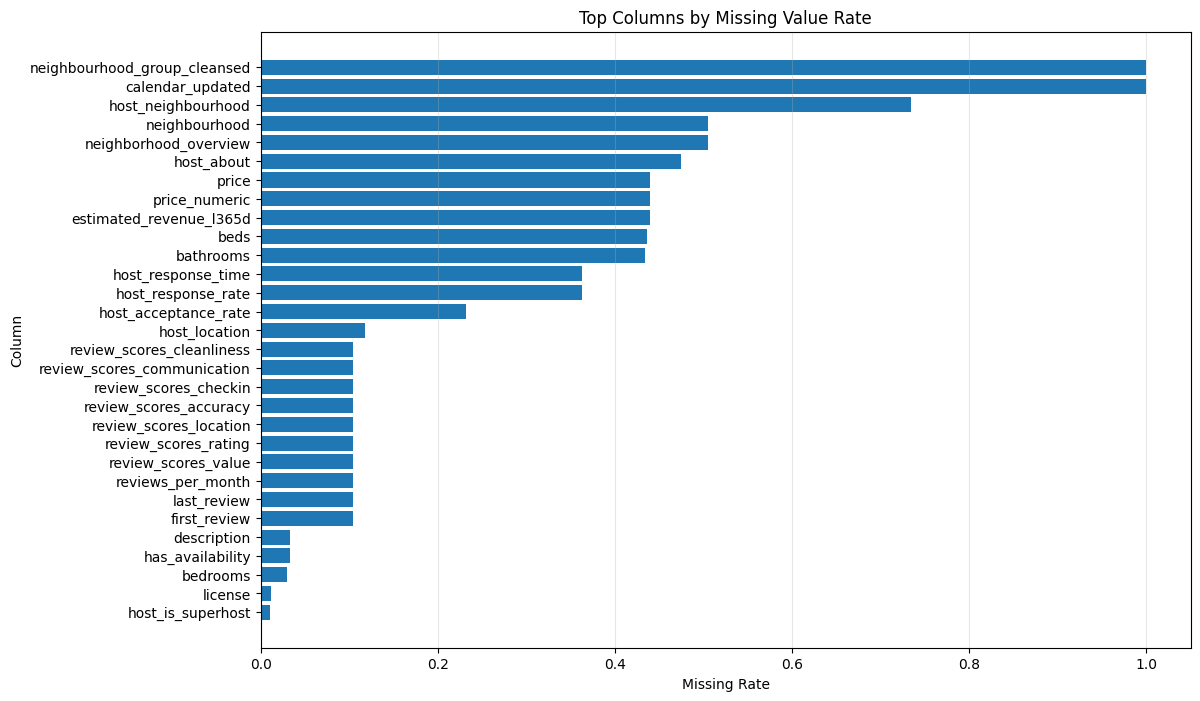

In [ ]:
# ============================================================
# Section 6: Visualize Missing Value Rates
# ============================================================

top_missing = missing_summary[missing_summary["missing_rate"] > 0].head(30)

plt.figure(figsize=(12, 8))
plt.barh(top_missing["column"][::-1], top_missing["missing_rate"][::-1])
plt.xlabel("Missing Rate")
plt.ylabel("Column")
plt.title("Top Columns by Missing Value Rate")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 7. First Column Decision Table

Before preprocessing, we create an initial decision table for feature handling.

The goal is not to permanently decide everything at once, but to document a transparent reasoning process.

Each column can be assigned one of the following preliminary decisions:

- `drop_identifier`: ID, URL, image, or scraping metadata that should not help generalization.
- `drop_empty`: column is completely missing.
- `drop_high_missing`: column has very high missingness and weak modeling value.
- `keep_numeric`: useful numerical feature.
- `keep_categorical`: useful categorical feature.
- `engineer_text_indicator`: descriptive text column converted into a binary indicator.
- `target`: prediction target.
- `review_later`: needs deeper analysis before final decision.

This table will later be used in the report to justify feature dropping and preprocessing choices.

In [ ]:
# ============================================================
# Section 7: First Column Decision Table
# ============================================================

identifier_keywords = [
    "id", "url", "picture", "thumbnail", "scrape", "name"
]

text_columns = [
    "description",
    "neighborhood_overview",
    "host_about",
    "amenities"
]

target_columns = [
    "price",
    "price_numeric",
    "host_is_superhost",
    "superhost_binary"
]

def initial_column_decision(row):
    col = row["column"]
    dtype = row["dtype"]
    missing_rate = row["missing_rate"]
    
    # Targets
    if col in target_columns:
        return "target"
    
    # Completely missing columns
    if missing_rate == 1.0:
        return "drop_empty"
    
    # Identifier / URL / metadata columns
    if any(key in col.lower() for key in identifier_keywords):
        return "drop_identifier"
    
    # Descriptive text columns
    if col in text_columns:
        return "engineer_text_indicator"
    
    # Very high missingness
    if missing_rate >= 0.70:
        return "drop_high_missing"
    
    # Numeric features
    if dtype in ["int64", "float64"]:
        return "keep_numeric"
    
    # Categorical/object features
    if dtype == "object":
        return "keep_categorical"
    
    return "review_later"


column_decision_table = missing_summary.copy()
column_decision_table["initial_decision"] = column_decision_table.apply(initial_column_decision, axis=1)

display(column_decision_table.sort_values(["initial_decision", "missing_rate"], ascending=[True, False]))

print("Initial decision counts:")
display(column_decision_table["initial_decision"].value_counts())

,column,dtype,missing_count,missing_rate,non_missing_count,unique_values,missing_group,initial_decision
0,neighbourhood_group_cleansed,float64,10480,1.000000,0,1,Completely missing,drop_empty
1,calendar_updated,float64,10480,1.000000,0,1,Completely missing,drop_empty
2,host_neighbourhood,object,7690,0.733779,2790,73,High missingness,drop_high_missing
37,host_identity_verified,object,3,0.000286,10477,3,Low missingness,drop_identifier
42,host_name,object,3,0.000286,10477,3858,Low missingness,drop_identifier
43,host_thumbnail_url,object,3,0.000286,10477,9059,Low missingness,drop_identifier
44,host_picture_url,object,3,0.000286,10477,9059,Low missingness,drop_identifier
45,scrape_id,int64,0,0.000000,10480,1,No missing,drop_identifier
46,last_scraped,object,0,0.000000,10480,1,No missing,drop_identifier
47,calendar_last_scraped,object,0,0.000000,10480,1,No missing,drop_identifier


Initial decision counts:


initial_decision
keep_numeric               39
keep_categorical           18
drop_identifier            13
target                      4
engineer_text_indicator     4
drop_empty                  2
drop_high_missing           1
Name: count, dtype: int64

## 8. Engineering Binary Indicators from Descriptive Text Features

Some columns are descriptive text fields. Directly imputing them with a numeric statistic such as mean or median is not meaningful.

Instead of dropping them immediately, we extract simple and interpretable indicator features.

For example:

- `has_description = 1` if the listing has a description.
- `has_description = 0` if the description is missing.

This is useful because the existence of a description can itself carry information. A host who writes a detailed description may behave differently from a host who leaves it empty.

We also create text length features because longer descriptions may reflect listing quality, host effort, or information richness.

In [ ]:
# ============================================================
# Section 8: Text Feature Indicator Engineering
# ============================================================

text_features_to_engineer = [
    "description",
    "neighborhood_overview",
    "host_about",
    "amenities"
]

for col in text_features_to_engineer:
    if col in df.columns:
        df[f"has_{col}"] = df[col].notna().astype(int)
        df[f"{col}_length"] = df[col].fillna("").astype(str).str.len()

engineered_text_features = [
    col for col in df.columns 
    if col.startswith("has_") or col.endswith("_length")
]

print("Engineered text-based features:")
print(engineered_text_features)

display(df[engineered_text_features].head())

print("\nSummary of engineered text features:")
display(df[engineered_text_features].describe())

Engineered text-based features:
['has_availability', 'has_description', 'description_length', 'has_neighborhood_overview', 'neighborhood_overview_length', 'has_host_about', 'host_about_length', 'has_amenities', 'amenities_length']


,has_availability,has_description,description_length,has_neighborhood_overview,neighborhood_overview_length,has_host_about,host_about_length,has_amenities,amenities_length
0,t,1,269,1,42,1,228,1,999
1,t,1,41,1,44,1,2,1,281
2,t,1,91,1,74,1,2,1,274
3,t,1,500,1,198,1,58,1,517
4,t,1,376,1,145,0,0,1,687



Summary of engineered text features:


,has_description,description_length,has_neighborhood_overview,neighborhood_overview_length,has_host_about,host_about_length,has_amenities,amenities_length
count,10480.000000,10480.000000,10480.000000,10480.000000,10480.000000,10480.000000,10480.0,10480.000000
mean,0.966794,384.960019,0.495420,223.028149,0.525763,144.608492,1.0,567.397042
std,0.179183,144.330183,0.500003,306.402709,0.499360,227.385117,0.0,315.630620
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,2.000000
25%,1.000000,299.000000,0.000000,0.000000,0.000000,0.000000,1.0,320.000000
50%,1.000000,443.000000,0.000000,0.000000,1.000000,27.000000,1.0,541.500000
75%,1.000000,497.000000,1.000000,368.000000,1.000000,240.000000,1.0,769.000000
max,1.000000,1000.000000,1.000000,1000.000000,1.000000,4966.000000,1.0,2192.000000


## 9. Duplicate Rows and Near-Constant Features

Real-world datasets may contain duplicated observations or features with almost no variation.

Duplicate rows can bias the model by over-representing repeated listings.

Near-constant features are usually not useful for prediction because they contain almost no information. They may also increase computational cost without improving performance.

In this section, we check:

- Full duplicated rows
- Duplicated listing IDs
- Columns with only one unique value
- Near-constant columns where one value dominates more than 99% of the data

In [ ]:
# ============================================================
# Section 9: Duplicate and Near-Constant Feature Check
# ============================================================

full_duplicate_count = df.duplicated().sum()

print(f"Number of fully duplicated rows: {full_duplicate_count}")

if "id" in df.columns:
    duplicate_id_count = df["id"].duplicated().sum()
    print(f"Number of duplicated listing IDs: {duplicate_id_count}")

constant_columns = []
near_constant_columns = []

for col in df.columns:
    value_counts_normalized = df[col].value_counts(dropna=False, normalize=True)
    
    if len(value_counts_normalized) == 1:
        constant_columns.append(col)
    elif value_counts_normalized.iloc[0] >= 0.99:
        near_constant_columns.append({
            "column": col,
            "dominant_value": value_counts_normalized.index[0],
            "dominant_rate": value_counts_normalized.iloc[0],
            "unique_values": df[col].nunique(dropna=False)
        })

near_constant_table = pd.DataFrame(near_constant_columns)

print("\nConstant columns:")
print(constant_columns)

print("\nNear-constant columns:")
display(near_constant_table)

# City-aware duplicate check for the five-city setting.
# Listing IDs may be globally unique, but this check is safer because the notebook now combines multiple city files.
if "city" in df.columns and "id" in df.columns:
    duplicate_city_id_count = df.duplicated(subset=["city", "id"]).sum()
    print(f"Number of duplicated city + listing ID pairs: {duplicate_city_id_count}")

    city_duplicate_id_table = (
        df
        .groupby("city")["id"]
        .apply(lambda s: s.duplicated().sum())
        .reset_index(name="duplicated_listing_ids_within_city")
    )

    display(city_duplicate_id_table)


## 10. Save the Initial Working Dataframe

At this stage, we have not completed full preprocessing yet.

However, we created important target variables and simple text-based engineered features.

We save this intermediate dataframe so that the next sections can continue from a stable checkpoint.

In [ ]:
# ============================================================
# Section 10: Save Initial Working Dataframe
# ============================================================

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

initial_output_path = OUTPUT_DIR / "airbnb_initial_working_dataframe.csv"
missing_summary_path = OUTPUT_DIR / "airbnb_missing_summary.csv"
column_decision_path = OUTPUT_DIR / "airbnb_initial_column_decision_table.csv"

df.to_csv(initial_output_path, index=False)
missing_summary.to_csv(missing_summary_path, index=False)
column_decision_table.to_csv(column_decision_path, index=False)

print("Saved files:")
print(f"1. {initial_output_path}")
print(f"2. {missing_summary_path}")
print(f"3. {column_decision_path}")

# Save five-city loading and schema-audit outputs if available.
if "city_loading_summary" in globals():
    city_loading_summary.to_csv(OUTPUT_DIR / "airbnb_five_city_loading_summary.csv", index=False)

if "column_city_presence" in globals():
    column_city_presence.to_csv(OUTPUT_DIR / "airbnb_column_city_presence.csv", index=False)

if "city_schema_availability" in globals():
    city_schema_availability.to_csv(OUTPUT_DIR / "airbnb_city_schema_availability.csv", index=False)

if "city_coverage_table" in globals():
    city_coverage_table.to_csv(OUTPUT_DIR / "airbnb_city_coverage_table.csv", index=False)


## 11. Missingness Mechanisms: MCAR, MAR, and MNAR

A major requirement of this assignment is to investigate the nature of missing values before applying imputation.

In real-world data, missingness is not always random. The reason why a value is missing can carry information about the data-generating process.

We classify missingness into three main categories:

### MCAR — Missing Completely At Random

A variable is MCAR if the probability of being missing is unrelated to both observed and unobserved variables.

Example:

A value is missing because of a random technical error during data export.

If missingness is MCAR, simple imputation such as mean or median imputation is less risky.

### MAR — Missing At Random

A variable is MAR if the probability of being missing depends on other observed variables.

Example:

`review_scores_rating` may be missing mostly for new listings with zero reviews.

In this case, missingness is not completely random, but it can be explained using observed features such as `number_of_reviews`.

### MNAR — Missing Not At Random

A variable is MNAR if the probability of being missing depends on the missing value itself or on an unobserved reason.

Example:

A host may hide or fail to report information because the value is undesirable.

MNAR is the hardest case because the missingness mechanism cannot be fully verified from the observed data alone.

In this notebook, we use statistical association tests and domain reasoning to assign an evidence-based missingness category to each important column.

## 12. Selecting Important Columns for Missingness Investigation

Not every column needs deep missingness investigation.

Some columns are identifiers, URLs, names, or metadata and should be dropped before modeling.

In this section, we focus on columns that are important for modeling or data-quality discussion, especially:

- Target-related columns
- Price-related columns
- Host-related columns
- Review-related columns
- Availability-related columns
- Property-related columns
- Descriptive text columns

For each selected column, we will later test whether its missingness is associated with other observed variables.

In [ ]:
# ============================================================
# Section 12: Select Important Columns for Missingness Investigation
# ============================================================

# Columns that are usually important for Airbnb modeling and data-quality discussion.
important_missingness_columns = [
    # Targets and target-related
    "price",
    "price_numeric",
    "host_is_superhost",
    "superhost_binary",
    
    # Host behavior and reliability
    "host_response_time",
    "host_response_rate",
    "host_acceptance_rate",
    "host_since",
    "host_location",
    "host_about",
    "host_has_profile_pic",
    "host_identity_verified",
    
    # Property information
    "bathrooms",
    "bathrooms_text",
    "bedrooms",
    "beds",
    
    # Textual / descriptive features
    "description",
    "neighborhood_overview",
    "amenities",
    
    # Reviews
    "first_review",
    "last_review",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "reviews_per_month",
    
    # Revenue / occupancy features
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

# Keep only columns that actually exist in the dataset.
important_missingness_columns = [
    col for col in important_missingness_columns
    if col in df.columns
]

important_missingness_table = pd.DataFrame({
    "column": important_missingness_columns,
    "dtype": [str(df[col].dtype) for col in important_missingness_columns],
    "missing_count": [df[col].isna().sum() for col in important_missingness_columns],
    "missing_rate": [df[col].isna().mean() for col in important_missingness_columns],
    "unique_values": [df[col].nunique(dropna=False) for col in important_missingness_columns]
}).sort_values("missing_rate", ascending=False).reset_index(drop=True)

display(important_missingness_table)

,column,dtype,missing_count,missing_rate,unique_values
0,neighborhood_overview,object,5288,0.504580,4847
1,host_about,object,4970,0.474237,4571
2,price_numeric,float64,4606,0.439504,664
3,estimated_revenue_l365d,float64,4606,0.439504,2637
4,price,object,4606,0.439504,664
5,beds,float64,4576,0.436641,23
6,bathrooms,float64,4548,0.433969,16
7,host_response_rate,object,3797,0.362309,65
8,host_response_time,object,3797,0.362309,5
9,host_acceptance_rate,object,2430,0.231870,102


## 13. Creating Missingness Indicator Variables

For each important column with missing values, we create a binary missingness indicator.

For a column `x`, the indicator is:

- `1` if `x` is missing
- `0` if `x` is observed

These indicators are useful for two reasons:

1. They allow us to test whether missingness is related to other observed variables.
2. They can later be used as features if missingness itself carries predictive information.

For example, if `review_scores_rating` is missing mostly when `number_of_reviews = 0`, then this missingness is informative and should not be ignored.

In [ ]:
# ============================================================
# Section 13: Create Missingness Indicators
# ============================================================

missing_indicator_columns = []

for col in important_missingness_columns:
    if df[col].isna().sum() > 0:
        indicator_col = f"is_missing__{col}"
        df[indicator_col] = df[col].isna().astype(int)
        missing_indicator_columns.append(indicator_col)

print(f"Number of missingness indicators created: {len(missing_indicator_columns)}")
print("Created indicators:")
for col in missing_indicator_columns:
    print("-", col)

display(df[missing_indicator_columns].head())

Number of missingness indicators created: 29
Created indicators:
- is_missing__price
- is_missing__price_numeric
- is_missing__host_is_superhost
- is_missing__superhost_binary
- is_missing__host_response_time
- is_missing__host_response_rate
- is_missing__host_acceptance_rate
- is_missing__host_since
- is_missing__host_location
- is_missing__host_about
- is_missing__host_has_profile_pic
- is_missing__host_identity_verified
- is_missing__bathrooms
- is_missing__bathrooms_text
- is_missing__bedrooms
- is_missing__beds
- is_missing__description
- is_missing__neighborhood_overview
- is_missing__first_review
- is_missing__last_review
- is_missing__review_scores_rating
- is_missing__review_scores_accuracy
- is_missing__review_scores_cleanliness
- is_missing__review_scores_checkin
- is_missing__review_scores_communication
- is_missing__review_scores_location
- is_missing__review_scores_value
- is_missing__reviews_per_month
- is_missing__estimated_revenue_l365d


,is_missing__price,is_missing__price_numeric,is_missing__host_is_superhost,is_missing__superhost_binary,is_missing__host_response_time,is_missing__host_response_rate,is_missing__host_acceptance_rate,is_missing__host_since,is_missing__host_location,is_missing__host_about,is_missing__host_has_profile_pic,is_missing__host_identity_verified,is_missing__bathrooms,is_missing__bathrooms_text,is_missing__bedrooms,is_missing__beds,is_missing__description,is_missing__neighborhood_overview,is_missing__first_review,is_missing__last_review,is_missing__review_scores_rating,is_missing__review_scores_accuracy,is_missing__review_scores_cleanliness,is_missing__review_scores_checkin,is_missing__review_scores_communication,is_missing__review_scores_location,is_missing__review_scores_value,is_missing__reviews_per_month,is_missing__estimated_revenue_l365d
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,1,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,1,1,0,0,1,1,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1


# ============================================================
# Section 13: Create Missingness Indicators
# ============================================================

missing_indicator_columns = []

for col in important_missingness_columns:
    if df[col].isna().sum() > 0:
        indicator_col = f"is_missing__{col}"
        df[indicator_col] = df[col].isna().astype(int)
        missing_indicator_columns.append(indicator_col)

print(f"Number of missingness indicators created: {len(missing_indicator_columns)}")
print("Created indicators:")
for col in missing_indicator_columns:
    print("-", col)

display(df[missing_indicator_columns].head())

In [ ]:
# ============================================================
# Section 14: Statistical Tests for Missingness Association
# ============================================================

from scipy import stats

# Candidate observed variables used to explain missingness.
# These variables should themselves be useful, interpretable, and not pure identifiers.
candidate_numeric_explainers = [
    "latitude",
    "longitude",
    "accommodates",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "reviews_per_month",
    "price_numeric",
    "superhost_binary"
]

candidate_categorical_explainers = [
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "instant_bookable",
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "has_availability"
]

candidate_numeric_explainers = [
    col for col in candidate_numeric_explainers
    if col in df.columns
]

candidate_categorical_explainers = [
    col for col in candidate_categorical_explainers
    if col in df.columns
]

def mann_whitney_missingness_test(data, missing_col, numeric_col, min_group_size=20):
    """
    Test whether a numeric observed variable differs between missing and observed groups.
    
    missing_col: binary indicator where 1 means missing and 0 means observed
    numeric_col: observed numerical variable
    """
    temp = data[[missing_col, numeric_col]].dropna()
    
    group_missing = temp.loc[temp[missing_col] == 1, numeric_col]
    group_observed = temp.loc[temp[missing_col] == 0, numeric_col]
    
    if len(group_missing) < min_group_size or len(group_observed) < min_group_size:
        return None
    
    try:
        statistic, p_value = stats.mannwhitneyu(
            group_missing,
            group_observed,
            alternative="two-sided"
        )
    except Exception:
        return None
    
    return {
        "test_type": "Mann-Whitney U",
        "missing_indicator": missing_col,
        "explainer": numeric_col,
        "group_missing_mean": group_missing.mean(),
        "group_observed_mean": group_observed.mean(),
        "group_missing_median": group_missing.median(),
        "group_observed_median": group_observed.median(),
        "p_value": p_value,
        "n_missing_group": len(group_missing),
        "n_observed_group": len(group_observed)
    }


def chi_square_missingness_test(data, missing_col, categorical_col, max_categories=30):
    """
    Test whether a categorical observed variable is associated with missingness.
    
    missing_col: binary indicator where 1 means missing and 0 means observed
    categorical_col: observed categorical variable
    """
    temp = data[[missing_col, categorical_col]].dropna()
    
    if temp[missing_col].nunique() < 2:
        return None
    
    # Avoid extremely high-cardinality categorical variables.
    if temp[categorical_col].nunique() > max_categories:
        top_categories = temp[categorical_col].value_counts().head(max_categories).index
        temp[categorical_col] = np.where(
            temp[categorical_col].isin(top_categories),
            temp[categorical_col],
            "OTHER"
        )
    
    contingency = pd.crosstab(temp[missing_col], temp[categorical_col])
    
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return None
    
    try:
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    except Exception:
        return None
    
    return {
        "test_type": "Chi-square",
        "missing_indicator": missing_col,
        "explainer": categorical_col,
        "chi2": chi2,
        "degrees_of_freedom": dof,
        "p_value": p_value,
        "n_rows": len(temp),
        "n_categories": temp[categorical_col].nunique()
    }


association_results = []

for missing_indicator in missing_indicator_columns:
    original_col = missing_indicator.replace("is_missing__", "")
    
    for numeric_col in candidate_numeric_explainers:
        # Avoid testing a column against its own missingness-created target.
        if numeric_col == original_col:
            continue
        
        result = mann_whitney_missingness_test(df, missing_indicator, numeric_col)
        if result is not None:
            result["original_missing_column"] = original_col
            association_results.append(result)
    
    for categorical_col in candidate_categorical_explainers:
        if categorical_col == original_col:
            continue
        
        result = chi_square_missingness_test(df, missing_indicator, categorical_col)
        if result is not None:
            result["original_missing_column"] = original_col
            association_results.append(result)

association_results_df = pd.DataFrame(association_results)

if len(association_results_df) > 0:
    association_results_df = association_results_df.sort_values(
        ["original_missing_column", "p_value"],
        ascending=[True, True]
    ).reset_index(drop=True)

display(association_results_df.head(100))

,test_type,missing_indicator,explainer,group_missing_mean,group_observed_mean,group_missing_median,group_observed_median,p_value,n_missing_group,n_observed_group,original_missing_column,chi2,degrees_of_freedom,n_rows,n_categories
0,Mann-Whitney U,is_missing__bathrooms,availability_30,1.170185,8.213082,0.000000,5.000000,0.000000e+00,4548.0,5932.0,bathrooms,NaN,NaN,NaN,NaN
1,Mann-Whitney U,is_missing__bathrooms,availability_60,2.707564,19.799393,0.000000,14.000000,0.000000e+00,4548.0,5932.0,bathrooms,NaN,NaN,NaN,NaN
2,Mann-Whitney U,is_missing__bathrooms,availability_90,4.484609,34.466285,0.000000,30.000000,0.000000e+00,4548.0,5932.0,bathrooms,NaN,NaN,NaN,NaN
3,Mann-Whitney U,is_missing__bathrooms,availability_365,16.547493,153.381659,0.000000,127.000000,0.000000e+00,4548.0,5932.0,bathrooms,NaN,NaN,NaN,NaN
4,Mann-Whitney U,is_missing__bathrooms,number_of_reviews_ltm,2.704705,13.098786,0.000000,4.000000,0.000000e+00,4548.0,5932.0,bathrooms,NaN,NaN,NaN,NaN
5,Mann-Whitney U,is_missing__bathrooms,reviews_per_month,0.463259,1.417980,0.260000,0.600000,0.000000e+00,4121.0,5262.0,bathrooms,NaN,NaN,NaN,NaN
6,Mann-Whitney U,is_missing__bathrooms,number_of_reviews_l30d,0.229112,1.036413,0.000000,0.000000,1.203123e-181,4548.0,5932.0,bathrooms,NaN,NaN,NaN,NaN
7,Mann-Whitney U,is_missing__bathrooms,superhost_binary,0.077248,0.257960,0.000000,0.000000,1.157052e-124,4492.0,5873.0,bathrooms,NaN,NaN,NaN,NaN
8,Chi-square,is_missing__bathrooms,host_is_superhost,NaN,NaN,NaN,NaN,2.080001e-124,NaN,NaN,bathrooms,562.788342,1.0,10365.0,2.0
9,Chi-square,is_missing__bathrooms,property_type,NaN,NaN,NaN,NaN,8.627286e-96,NaN,NaN,bathrooms,544.497245,30.0,10480.0,31.0


## 15. Summarizing Strong Missingness Associations

The full association table can be large, so we summarize the strongest relationships.

A small p-value suggests that the missingness of a column is statistically associated with an observed variable.

For this project, we use this evidence to support the missingness classification:

- Many significant associations → evidence for MAR
- Few or no significant associations → possible MCAR
- Domain-based missingness reason → suspected MNAR

We should be careful: statistical tests cannot fully prove MNAR. MNAR usually requires domain reasoning.

In [ ]:
# ============================================================
# Section 15: Summarize Strong Missingness Associations
# ============================================================

SIGNIFICANCE_LEVEL = 0.01

if len(association_results_df) > 0:
    strong_associations = association_results_df[
        association_results_df["p_value"] < SIGNIFICANCE_LEVEL
    ].copy()
else:
    strong_associations = pd.DataFrame()

summary_rows = []

for indicator in missing_indicator_columns:
    original_col = indicator.replace("is_missing__", "")
    
    col_results = association_results_df[
        association_results_df["original_missing_column"] == original_col
    ] if len(association_results_df) > 0 else pd.DataFrame()
    
    strong_col_results = strong_associations[
        strong_associations["original_missing_column"] == original_col
    ] if len(strong_associations) > 0 else pd.DataFrame()
    
    top_explainers = []
    
    if len(strong_col_results) > 0:
        top_explainers = (
            strong_col_results
            .sort_values("p_value")
            .head(5)["explainer"]
            .tolist()
        )
    
    summary_rows.append({
        "column": original_col,
        "missing_count": df[original_col].isna().sum(),
        "missing_rate": df[original_col].isna().mean(),
        "number_of_tests": len(col_results),
        "number_of_significant_associations": len(strong_col_results),
        "top_associated_observed_features": ", ".join(top_explainers)
    })

missingness_association_summary = pd.DataFrame(summary_rows)
missingness_association_summary = missingness_association_summary.sort_values(
    ["missing_rate", "number_of_significant_associations"],
    ascending=[False, False]
).reset_index(drop=True)

display(missingness_association_summary)

,column,missing_count,missing_rate,number_of_tests,number_of_significant_associations,top_associated_observed_features
0,neighborhood_overview,5288,0.504580,26,20,"number_of_reviews, property_type, superhost_bi..."
1,host_about,4970,0.474237,26,20,"number_of_reviews, superhost_binary, host_is_s..."
2,price,4606,0.439504,25,20,"availability_30, availability_60, availability..."
3,price_numeric,4606,0.439504,25,20,"availability_30, availability_60, availability..."
4,estimated_revenue_l365d,4606,0.439504,25,20,"availability_30, availability_60, availability..."
5,beds,4576,0.436641,25,20,"availability_30, availability_60, availability..."
6,bathrooms,4548,0.433969,25,21,"availability_30, availability_60, availability..."
7,host_response_time,3797,0.362309,26,22,"availability_30, availability_60, availability..."
8,host_response_rate,3797,0.362309,26,22,"availability_30, availability_60, availability..."
9,host_acceptance_rate,2430,0.231870,26,23,"availability_60, availability_90, availability..."


## 16. Evidence-Based Missingness Classification

In this section, we assign a preliminary missingness mechanism to each important column.

The classification is based on:

1. Missing rate
2. Statistical associations with observed variables
3. Airbnb domain knowledge
4. Whether the missingness has a natural explanation

Important note:

MNAR cannot usually be proven from observed data alone. Therefore, we use the label `Suspected MNAR` when the missingness may depend on hidden host behavior, platform policy, or unobserved listing quality.

This classification will be used later to justify the imputation strategy.

In [ ]:
# ============================================================
# Section 16: Evidence-Based Missingness Classification
# ============================================================

def classify_missingness(row):
    """
    Assign a practical missingness category using statistical evidence and domain rules.
    """
    col = row["column"]
    missing_rate = row["missing_rate"]
    sig_count = row["number_of_significant_associations"]
    
    # No missing values
    if missing_rate == 0:
        return "No missing"
    
    # Domain-driven MAR examples:
    # Review scores are often missing because listings have no reviews.
    review_related_keywords = [
        "review_scores",
        "reviews_per_month",
        "first_review",
        "last_review"
    ]
    
    if any(keyword in col for keyword in review_related_keywords):
        return "MAR"
    
    # Price-related missingness can be related to platform/calendar availability.
    if col in ["price", "price_numeric", "estimated_revenue_l365d"]:
        return "MAR / Suspected MNAR"
    
    # Host response fields often depend on host activity and platform interaction.
    if col in ["host_response_time", "host_response_rate", "host_acceptance_rate"]:
        return "MAR"
    
    # Descriptive text fields may reflect host effort or willingness to disclose.
    if col in ["description", "neighborhood_overview", "host_about"]:
        return "MAR / Suspected MNAR"
    
    # If many significant associations exist, missingness is unlikely to be MCAR.
    if sig_count >= 3:
        return "MAR"
    
    # Low missingness with weak evidence can be treated as approximately MCAR.
    if missing_rate <= 0.05 and sig_count == 0:
        return "Approximately MCAR"
    
    # Default conservative choice.
    return "Unclear / Needs domain review"


missingness_classification = missingness_association_summary.copy()
missingness_classification["missingness_mechanism"] = missingness_classification.apply(
    classify_missingness,
    axis=1
)

display(missingness_classification)

,column,missing_count,missing_rate,number_of_tests,number_of_significant_associations,top_associated_observed_features,missingness_mechanism
0,neighborhood_overview,5288,0.504580,26,20,"number_of_reviews, property_type, superhost_bi...",MAR / Suspected MNAR
1,host_about,4970,0.474237,26,20,"number_of_reviews, superhost_binary, host_is_s...",MAR / Suspected MNAR
2,price,4606,0.439504,25,20,"availability_30, availability_60, availability...",MAR / Suspected MNAR
3,price_numeric,4606,0.439504,25,20,"availability_30, availability_60, availability...",MAR / Suspected MNAR
4,estimated_revenue_l365d,4606,0.439504,25,20,"availability_30, availability_60, availability...",MAR / Suspected MNAR
5,beds,4576,0.436641,25,20,"availability_30, availability_60, availability...",MAR
6,bathrooms,4548,0.433969,25,21,"availability_30, availability_60, availability...",MAR
7,host_response_time,3797,0.362309,26,22,"availability_30, availability_60, availability...",MAR
8,host_response_rate,3797,0.362309,26,22,"availability_30, availability_60, availability...",MAR
9,host_acceptance_rate,2430,0.231870,26,23,"availability_60, availability_90, availability...",MAR


## 17. Designing the Imputation Strategy

After investigating missingness, we design an imputation strategy.

The strategy must be defensible, not arbitrary.

General rules used in this notebook:

### Numerical variables

For skewed real-world variables such as price, beds, bathrooms, and reviews, we prefer median imputation instead of mean imputation.

Median is more robust to extreme outliers.

### Categorical variables

For categorical variables, we use an explicit category called `Unknown`.

This avoids pretending that the missing category is the same as the most frequent category.

### Text variables

For descriptive text variables, direct imputation is not meaningful.

Instead, we keep the engineered indicators such as:

- `has_description`
- `description_length`

The raw text columns can be dropped before classical numerical modeling.

### Missingness indicators

For columns whose missingness is informative, we keep missingness indicator columns.

This allows the model to learn from the fact that a value was missing.

In [ ]:
# ============================================================
# Section 17: Imputation Strategy Design
# ============================================================

# Columns that should be treated as raw text.
raw_text_columns = [
    "description",
    "neighborhood_overview",
    "host_about",
    "amenities"
]

raw_text_columns = [col for col in raw_text_columns if col in df.columns]

# Columns that are identifiers, URLs, images, or scraping metadata.
drop_metadata_keywords = [
    "url",
    "picture",
    "thumbnail",
    "scrape",
]

explicit_drop_columns = [
    "id",
    "host_id",
    "name",
    "host_name",
    "license",
    "calendar_updated",
    "neighbourhood_group_cleansed"
]

metadata_drop_columns = []

for col in df.columns:
    if any(keyword in col.lower() for keyword in drop_metadata_keywords):
        metadata_drop_columns.append(col)

drop_columns = sorted(set(explicit_drop_columns + metadata_drop_columns + raw_text_columns))
drop_columns = [col for col in drop_columns if col in df.columns]

# Targets should not be included as ordinary features.
target_columns = [
    "price",
    "price_numeric",
    "host_is_superhost",
    "superhost_binary"
]

target_columns = [col for col in target_columns if col in df.columns]

# Feature candidates after removing metadata, raw text, and targets.
feature_candidate_columns = [
    col for col in df.columns
    if col not in drop_columns
    and col not in target_columns
]

numeric_feature_candidates = [
    col for col in feature_candidate_columns
    if pd.api.types.is_numeric_dtype(df[col])
]

categorical_feature_candidates = [
    col for col in feature_candidate_columns
    if df[col].dtype == "object"
]

imputation_strategy_rows = []

for col in numeric_feature_candidates:
    imputation_strategy_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "missing_rate": df[col].isna().mean(),
        "imputation_strategy": "median",
        "reason": "Median is robust to skewness and outliers in real-world Airbnb variables."
    })

for col in categorical_feature_candidates:
    imputation_strategy_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "missing_rate": df[col].isna().mean(),
        "imputation_strategy": "Unknown category",
        "reason": "Missing category may be informative; using Unknown avoids false mode assumptions."
    })

for col in raw_text_columns:
    imputation_strategy_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "missing_rate": df[col].isna().mean(),
        "imputation_strategy": "text indicator + text length",
        "reason": "Raw text cannot be meaningfully imputed by mean or median."
    })

imputation_strategy_table = pd.DataFrame(imputation_strategy_rows)
imputation_strategy_table = imputation_strategy_table.sort_values(
    ["missing_rate", "column"],
    ascending=[False, True]
).reset_index(drop=True)

display(imputation_strategy_table)

,column,dtype,missing_rate,imputation_strategy,reason
0,host_neighbourhood,object,0.733779,Unknown category,Missing category may be informative; using Unk...
1,neighborhood_overview,object,0.504580,text indicator + text length,Raw text cannot be meaningfully imputed by mea...
2,neighbourhood,object,0.504580,Unknown category,Missing category may be informative; using Unk...
3,host_about,object,0.474237,text indicator + text length,Raw text cannot be meaningfully imputed by mea...
4,estimated_revenue_l365d,float64,0.439504,median,Median is robust to skewness and outliers in r...
5,beds,float64,0.436641,median,Median is robust to skewness and outliers in r...
6,bathrooms,float64,0.433969,median,Median is robust to skewness and outliers in r...
7,host_response_rate,object,0.362309,Unknown category,Missing category may be informative; using Unk...
8,host_response_time,object,0.362309,Unknown category,Missing category may be informative; using Unk...
9,host_acceptance_rate,object,0.231870,Unknown category,Missing category may be informative; using Unk...


## 18. Applying Initial Imputation

In this section, we create an initially imputed version of the Airbnb dataframe.

This is not the final modeling dataframe yet.

The purpose is to produce a clean intermediate dataset where:

- Numerical missing values are filled with median values.
- Categorical missing values are filled with `Unknown`.
- Raw text columns are removed after extracting indicator and length features.
- Missingness indicators are preserved.
- Target variables are preserved separately.

This gives us a stable dataset for the next stage: outlier analysis and feature quality analysis.

In [ ]:
# ============================================================
# Section 18: Apply Initial Imputation
# ============================================================

df_imputed = df.copy()

# Drop metadata and raw text columns from the modeling feature space.
df_imputed_features = df_imputed.drop(columns=drop_columns, errors="ignore")

# We keep target columns in df_imputed_features for now,
# but we will separate them during model dataset construction.
for col in numeric_feature_candidates:
    if col in df_imputed_features.columns:
        median_value = df_imputed_features[col].median()
        df_imputed_features[col] = df_imputed_features[col].fillna(median_value)

for col in categorical_feature_candidates:
    if col in df_imputed_features.columns:
        df_imputed_features[col] = df_imputed_features[col].fillna("Unknown")

remaining_missing = df_imputed_features.isna().sum().sort_values(ascending=False)
remaining_missing = remaining_missing[remaining_missing > 0]

print("Shape before dropping metadata/text columns:", df.shape)
print("Shape after dropping metadata/text columns:", df_imputed_features.shape)

print("\nRemaining missing values after initial imputation:")
display(remaining_missing)

display(df_imputed_features.head())

Shape before dropping metadata/text columns: (10480, 118)
Shape after dropping metadata/text columns: (10480, 99)

Remaining missing values after initial imputation:


price                4606
price_numeric        4606
host_is_superhost     115
superhost_binary      115
dtype: int64

,source,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_numeric,superhost_binary,has_description,description_length,has_neighborhood_overview,neighborhood_overview_length,has_host_about,host_about_length,has_amenities,amenities_length,is_missing__price,is_missing__price_numeric,is_missing__host_is_superhost,is_missing__superhost_binary,is_missing__host_response_time,is_missing__host_response_rate,is_missing__host_acceptance_rate,is_missing__host_since,is_missing__host_location,is_missing__host_about,is_missing__host_has_profile_pic,is_missing__host_identity_verified,is_missing__bathrooms,is_missing__bathrooms_text,is_missing__bedrooms,is_missing__beds,is_missing__description,is_missing__neighborhood_overview,is_missing__first_review,is_missing__last_review,is_missing__review_scores_rating,is_missing__review_scores_accuracy,is_missing__review_scores_cleanliness,is_missing__review_scores_checkin,is_missing__review_scores_communication,is_missing__review_scores_location,is_missing__review_scores_value,is_missing__reviews_per_month,is_missing__estimated_revenue_l365d
0,city scrape,2010-03-23,"Amsterdam, Netherlands",within an hour,100%,97%,t,Westelijke Eilanden,1.0,1.0,"['email', 'phone']",t,t,"Amsterdam, North Holland, Netherlands",Centrum-West,52.387610,4.89188,Private room in houseboat,Private room,2,1.5,1.5 baths,1.0,1.0,$132.00,3,356,3.0,3.0,30.0,30.0,3.0,30.0,t,2,5,16,17,311,33,3,17,26,255,33660.0,2012-01-09,2025-09-07,4.92,4.90,4.94,4.95,4.93,4.90,4.78,f,1,0,1,0,1.87,132.0,1.0,1,269,1,42,1,228,1,999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,city scrape,2010-05-13,"Amsterdam, Netherlands",within an hour,100%,99%,t,Amsterdam Centrum,2.0,2.0,"['email', 'phone']",t,t,"Amsterdam, North Holland, Netherlands",Centrum-West,52.367750,4.89092,Private room in rental unit,Private room,2,1.0,1 shared bath,1.0,1.0,$89.00,2,730,1.0,2.0,730.0,730.0,2.0,730.0,t,0,2,10,126,732,93,9,15,96,255,22695.0,2010-08-22,2025-09-07,4.87,4.90,4.86,4.94,4.94,4.93,4.83,f,2,0,2,0,3.99,89.0,1.0,1,41,1,44,1,2,1,281,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,city scrape,2010-05-13,"Amsterdam, Netherlands",within an hour,100%,99%,t,Amsterdam Centrum,2.0,2.0,"['email', 'phone']",t,t,"Amsterdam, North Holland, Netherlands",Centrum-Oost,52.365840,4.89111,Private room in condo,Private room,2,1.0,1 shared bath,1.0,1.0,$61.00,2,730,1.0,2.0,730.0,730.0,2.0,730.0,t,0,1,13,95,849,86,8,13,88,255,15555.0,2011-03-16,2025-09-08,4.81,4.88,4.83,4.93,4.92,4.87,4.79,f,2,0,2,0,4.81,61.0,1.0,1,91,1,74,1,2,1,274,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,previous scrape,2010-08-08,"Amsterdam, Netherlands",Unknown,Unknown,Unknown,f,Oostelijke Eilanden en Kadijken,1.0,1.0,"['email', 'phone']",t,t,"Amsterdam, Noord-Holland, Netherlands",Centrum-Oost,52.371680,4.91471,Entire rental unit,Entire home/apt,4,1.0,1.5 baths,2.0,1.0,NaN,3,730,3.0,

## 19. Saving Missingness and Imputation Outputs

The assignment requires deep documentation of data-quality decisions.

Therefore, we save the following outputs:

- Missingness association test results
- Missingness classification table
- Imputation strategy table
- Initially imputed Airbnb dataframe

These files can later be used in the final mini-conference paper.

In [ ]:
# ============================================================
# Section 19: Save Missingness and Imputation Outputs
# ============================================================

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

association_results_path = OUTPUT_DIR / "airbnb_missingness_association_tests.csv"
missingness_classification_path = OUTPUT_DIR / "airbnb_missingness_classification.csv"
imputation_strategy_path = OUTPUT_DIR / "airbnb_imputation_strategy.csv"
imputed_dataframe_path = OUTPUT_DIR / "airbnb_initial_imputed_dataframe.csv"

association_results_df.to_csv(association_results_path, index=False)
missingness_classification.to_csv(missingness_classification_path, index=False)
imputation_strategy_table.to_csv(imputation_strategy_path, index=False)
df_imputed_features.to_csv(imputed_dataframe_path, index=False)

print("Saved files:")
print(f"1. {association_results_path}")
print(f"2. {missingness_classification_path}")
print(f"3. {imputation_strategy_path}")
print(f"4. {imputed_dataframe_path}")

# Save city-level missingness outputs if available.
if "city_missing_summary" in globals():
    city_missing_summary.to_csv(OUTPUT_DIR / "airbnb_city_missing_summary.csv", index=False)

if "city_missing_variability" in globals():
    city_missing_variability.to_csv(OUTPUT_DIR / "airbnb_city_missing_variability.csv", index=False)


## 20. Report-Ready Missingness Summary

The following text summarizes the missingness analysis in a form that can later be adapted into the final report.

The Airbnb dataset contains several types of missingness. Some missing values are likely caused by platform structure, while others are related to host behavior or listing activity.

Review-related variables are mostly classified as MAR because their missingness is strongly connected to whether a listing has received reviews. For example, listings with zero or very few reviews naturally lack review scores.

Textual fields such as `description`, `neighborhood_overview`, and `host_about` are not imputed directly. Instead, we extract binary indicators and text-length features. This is more meaningful because the absence of a description may itself indicate host effort, listing quality, or information disclosure behavior.

Numerical variables are imputed using the median because Airbnb variables such as price, number of reviews, beds, and availability are often skewed and may contain extreme values. Median imputation is more robust than mean imputation in the presence of outliers.

Categorical variables are imputed with an explicit `Unknown` category. This avoids incorrectly assuming that missing values belong to the most frequent category and preserves missingness as a potentially informative state.

For variables whose missingness is statistically associated with observed features, missingness indicators are retained so that downstream models can use missingness itself as a signal.

## 21. Outlier Analysis Overview

Outlier analysis is a required part of the data-quality investigation.

In real-world Airbnb data, outliers are expected because listings can be very different from each other. For example, a luxury apartment, a shared room, and a large house may all exist in the same dataset.

However, not every extreme value is necessarily an error.

In this section, we compare three outlier detection methods:

1. **Z-score**
2. **IQR rule**
3. **Simple Isolation Forest implemented from scratch with NumPy**

The goal is not to blindly remove all outliers. Instead, we want to understand:

- Which variables contain extreme values?
- Which method is too sensitive?
- Which method is more robust for skewed Airbnb distributions?
- Which observations are suspicious across multiple methods?
- Should we remove, cap, transform, or preserve these values?

This follows the assignment requirement to compare and contrast the effectiveness of Z-score, IQR, and Isolation Forest on the dataset distributions.

## 22. Selecting Numeric Variables for Outlier Analysis

Outlier detection is mainly meaningful on numerical variables.

For Airbnb, we focus on numerical variables related to:

- Price
- Capacity
- Rooms and beds
- Minimum and maximum nights
- Availability
- Review activity
- Host listing counts
- Estimated occupancy and revenue

Some of these variables are highly skewed. This is important because Z-score assumes a roughly symmetric distribution and may fail when the distribution has a long right tail.

In [ ]:
# ============================================================
# Section 22: Select Numeric Columns for Outlier Analysis
# ============================================================

# Safety check: if this notebook starts from this section, recreate cleaned targets.
if "price_numeric" not in df.columns:
    def clean_price(value):
        if pd.isna(value):
            return np.nan
        value = str(value).replace("$", "").replace(",", "").strip()
        try:
            return float(value)
        except ValueError:
            return np.nan
    
    df["price_numeric"] = df["price"].apply(clean_price)

if "superhost_binary" not in df.columns and "host_is_superhost" in df.columns:
    def clean_superhost(value):
        if pd.isna(value):
            return np.nan
        value = str(value).strip().lower()
        if value == "t":
            return 1
        elif value == "f":
            return 0
        else:
            return np.nan
    
    df["superhost_binary"] = df["host_is_superhost"].apply(clean_superhost)


candidate_outlier_columns = [
    "price_numeric",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

outlier_numeric_columns = [
    col for col in candidate_outlier_columns
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

print("Numeric columns selected for outlier analysis:")
for col in outlier_numeric_columns:
    print("-", col)

print(f"\nNumber of selected numeric columns: {len(outlier_numeric_columns)}")

Numeric columns selected for outlier analysis:
- price_numeric
- accommodates
- bathrooms
- bedrooms
- beds
- minimum_nights
- maximum_nights
- availability_30
- availability_60
- availability_90
- availability_365
- number_of_reviews
- number_of_reviews_ltm
- number_of_reviews_l30d
- reviews_per_month
- calculated_host_listings_count
- calculated_host_listings_count_entire_homes
- calculated_host_listings_count_private_rooms
- calculated_host_listings_count_shared_rooms
- estimated_occupancy_l365d
- estimated_revenue_l365d

Number of selected numeric columns: 21


# ============================================================
# Section 22: Select Numeric Columns for Outlier Analysis
# ============================================================

# Safety check: if this notebook starts from this section, recreate cleaned targets.
if "price_numeric" not in df.columns:
    def clean_price(value):
        if pd.isna(value):
            return np.nan
        value = str(value).replace("$", "").replace(",", "").strip()
        try:
            return float(value)
        except ValueError:
            return np.nan
    
    df["price_numeric"] = df["price"].apply(clean_price)

if "superhost_binary" not in df.columns and "host_is_superhost" in df.columns:
    def clean_superhost(value):
        if pd.isna(value):
            return np.nan
        value = str(value).strip().lower()
        if value == "t":
            return 1
        elif value == "f":
            return 0
        else:
            return np.nan
    
    df["superhost_binary"] = df["host_is_superhost"].apply(clean_superhost)


candidate_outlier_columns = [
    "price_numeric",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

outlier_numeric_columns = [
    col for col in candidate_outlier_columns
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

print("Numeric columns selected for outlier analysis:")
for col in outlier_numeric_columns:
    print("-", col)

print(f"\nNumber of selected numeric columns: {len(outlier_numeric_columns)}")

In [ ]:
# ============================================================
# Section 22: Select Numeric Columns for Outlier Analysis
# ============================================================

# Safety check: if this notebook starts from this section, recreate cleaned targets.
if "price_numeric" not in df.columns:
    def clean_price(value):
        if pd.isna(value):
            return np.nan
        value = str(value).replace("$", "").replace(",", "").strip()
        try:
            return float(value)
        except ValueError:
            return np.nan
    
    df["price_numeric"] = df["price"].apply(clean_price)

if "superhost_binary" not in df.columns and "host_is_superhost" in df.columns:
    def clean_superhost(value):
        if pd.isna(value):
            return np.nan
        value = str(value).strip().lower()
        if value == "t":
            return 1
        elif value == "f":
            return 0
        else:
            return np.nan
    
    df["superhost_binary"] = df["host_is_superhost"].apply(clean_superhost)


candidate_outlier_columns = [
    "price_numeric",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

outlier_numeric_columns = [
    col for col in candidate_outlier_columns
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

print("Numeric columns selected for outlier analysis:")
for col in outlier_numeric_columns:
    print("-", col)

print(f"\nNumber of selected numeric columns: {len(outlier_numeric_columns)}")

Numeric columns selected for outlier analysis:
- price_numeric
- accommodates
- bathrooms
- bedrooms
- beds
- minimum_nights
- maximum_nights
- availability_30
- availability_60
- availability_90
- availability_365
- number_of_reviews
- number_of_reviews_ltm
- number_of_reviews_l30d
- reviews_per_month
- calculated_host_listings_count
- calculated_host_listings_count_entire_homes
- calculated_host_listings_count_private_rooms
- calculated_host_listings_count_shared_rooms
- estimated_occupancy_l365d
- estimated_revenue_l365d

Number of selected numeric columns: 21


## 24. Visualizing Important Skewed Variables

Airbnb variables such as price, reviews, revenue, and minimum nights are often heavily skewed.

We visualize selected variables using histograms.

For highly skewed variables, we also visualize the log-transformed version using `log1p`.

The transformation is:

`log1p(x) = log(1 + x)`

This transformation reduces the effect of extremely large values and helps us understand the main body of the distribution.

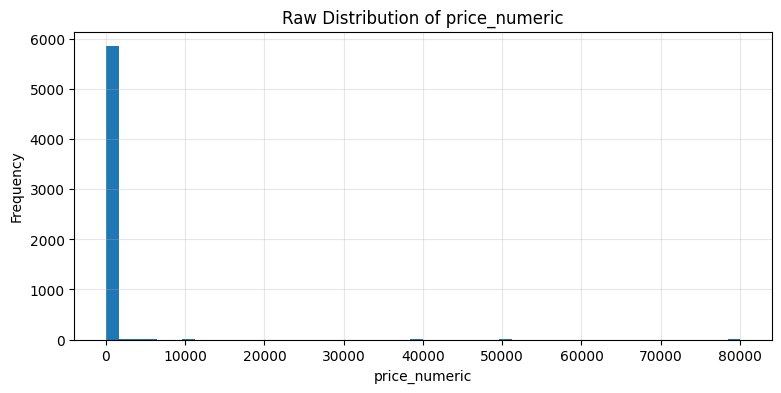

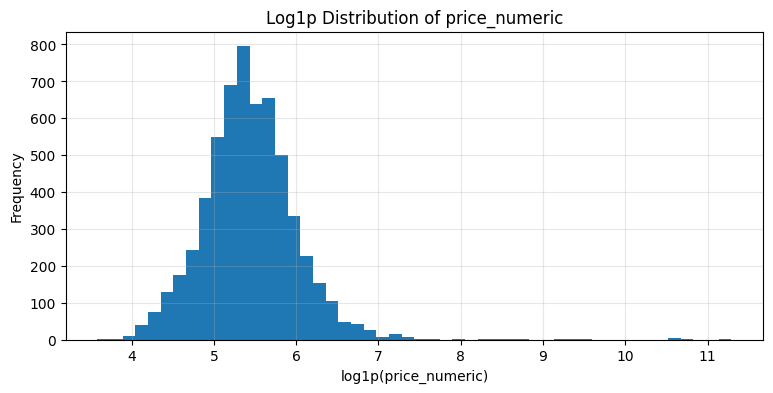

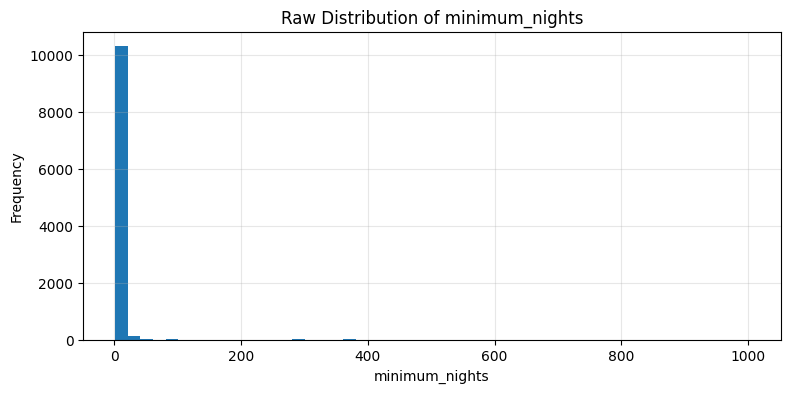

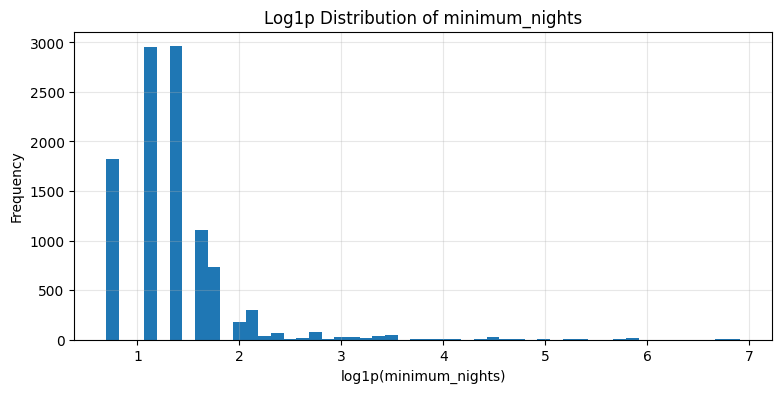

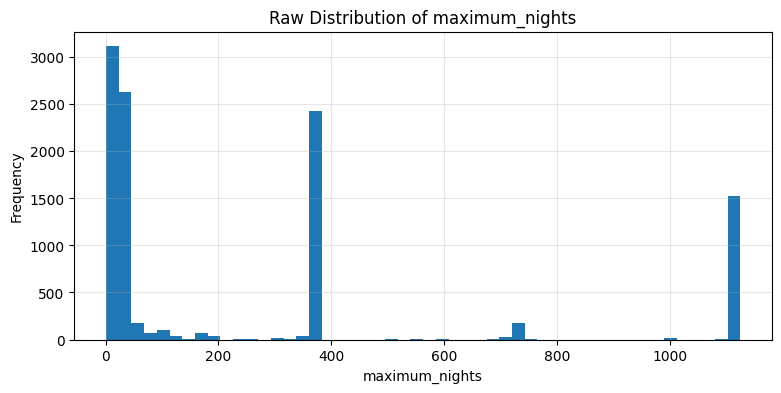

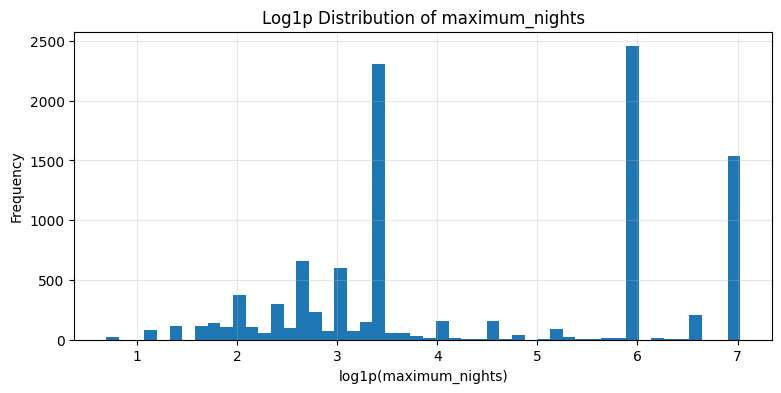

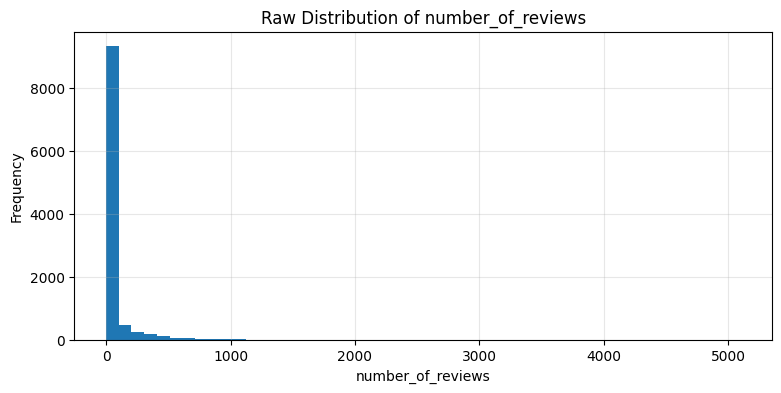

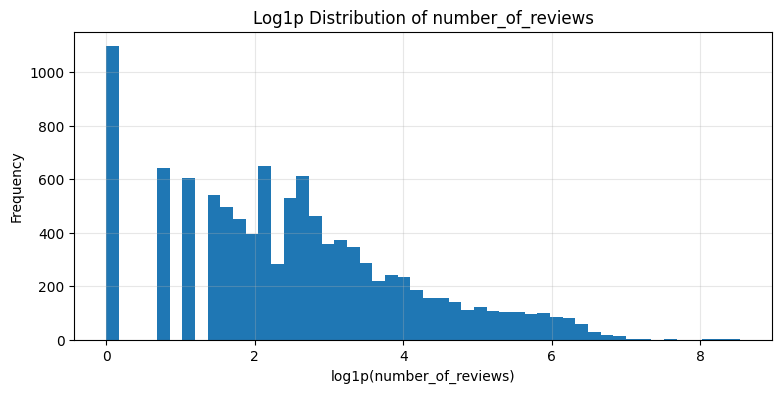

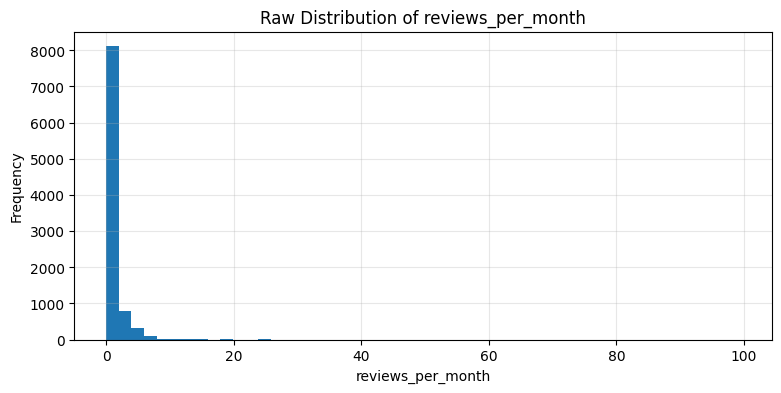

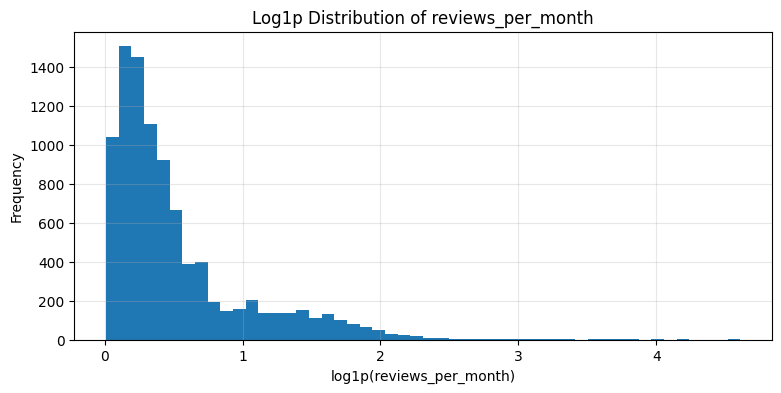

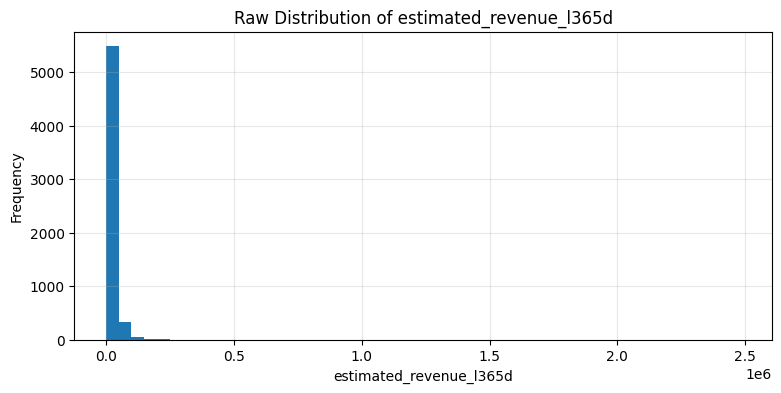

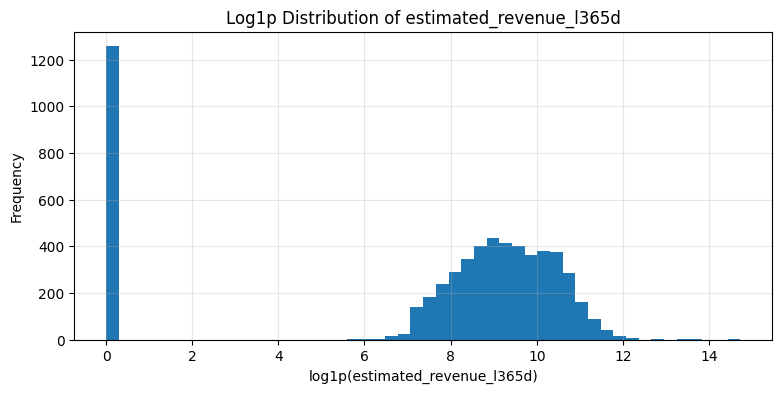

In [ ]:
# ============================================================
# Section 24: Visualize Important Skewed Variables
# ============================================================

important_plot_columns = [
    "price_numeric",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "estimated_revenue_l365d"
]

important_plot_columns = [
    col for col in important_plot_columns
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

for col in important_plot_columns:
    x = df[col].dropna()
    
    if len(x) == 0:
        continue
    
    plt.figure(figsize=(9, 4))
    plt.hist(x, bins=50)
    plt.title(f"Raw Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()
    
    if x.min() >= 0:
        plt.figure(figsize=(9, 4))
        plt.hist(np.log1p(x), bins=50)
        plt.title(f"Log1p Distribution of {col}")
        plt.xlabel(f"log1p({col})")
        plt.ylabel("Frequency")
        plt.grid(alpha=0.3)
        plt.show()

## 25. Z-score Outlier Detection

The Z-score method measures how far each value is from the mean in units of standard deviation.

A common rule is:

`|z| > 3`

This means the observation is more than 3 standard deviations away from the mean.

However, Z-score can be problematic for Airbnb data because many variables are highly skewed. When the mean and standard deviation are distorted by extreme values, Z-score may fail to identify realistic outliers or may under-detect extreme long-tail values.

Therefore, we use Z-score as one baseline method, not as the only decision rule.

In [ ]:
# ============================================================
# Section 25: Z-score Outlier Detection
# ============================================================

def detect_zscore_outliers(data, columns, threshold=3.0):
    """
    Detect univariate outliers using the Z-score rule.
    
    A value is flagged as an outlier if:
        abs((x - mean) / std) > threshold
    
    Parameters
    ----------
    data : pandas.DataFrame
        Input dataframe.
    columns : list
        Numeric columns to analyze.
    threshold : float
        Z-score threshold.
    
    Returns
    -------
    flags : pandas.DataFrame
        Boolean outlier flags for each column and a combined flag.
    summary : pandas.DataFrame
        Outlier count and rate for each column.
    """
    flags = pd.DataFrame(index=data.index)
    summary_rows = []
    
    for col in columns:
        x = data[col].astype(float)
        mean_value = x.mean(skipna=True)
        std_value = x.std(skipna=True)
        
        if pd.isna(std_value) or std_value == 0:
            flags[f"z_outlier__{col}"] = False
            continue
        
        z_scores = ((x - mean_value) / std_value).abs()
        col_flag = z_scores > threshold
        col_flag = col_flag.fillna(False)
        
        flags[f"z_outlier__{col}"] = col_flag
        
        summary_rows.append({
            "column": col,
            "method": "Z-score",
            "threshold": threshold,
            "mean": mean_value,
            "std": std_value,
            "outlier_count": int(col_flag.sum()),
            "outlier_rate": col_flag.mean()
        })
    
    flags["zscore_outlier_any"] = flags.any(axis=1)
    summary = pd.DataFrame(summary_rows)
    
    return flags, summary


zscore_flags, zscore_summary = detect_zscore_outliers(
    data=df,
    columns=outlier_numeric_columns,
    threshold=3.0
)

zscore_summary = zscore_summary.sort_values(
    "outlier_rate",
    ascending=False
).reset_index(drop=True)

display(zscore_summary)

print("Total rows flagged by Z-score in at least one variable:")
print(zscore_flags["zscore_outlier_any"].sum())

print("Z-score overall outlier rate:")
print(zscore_flags["zscore_outlier_any"].mean())

,column,method,threshold,mean,std,outlier_count,outlier_rate
0,calculated_host_listings_count_private_rooms,Z-score,3.0,0.560115,1.713971,312,0.029771
1,calculated_host_listings_count,Z-score,3.0,1.844084,3.159096,232,0.022137
2,number_of_reviews,Z-score,3.0,47.813359,131.507440,225,0.021469
3,calculated_host_listings_count_entire_homes,Z-score,3.0,1.217748,2.433486,156,0.014885
4,bathrooms,Z-score,3.0,1.229855,0.536533,106,0.010115
5,number_of_reviews_ltm,Z-score,3.0,8.588073,25.195305,106,0.010115
6,accommodates,Z-score,3.0,2.920515,1.276192,94,0.008969
7,number_of_reviews_l30d,Z-score,3.0,0.686069,2.233509,86,0.008206
8,calculated_host_listings_count_shared_rooms,Z-score,3.0,0.029103,0.409605,70,0.006679
9,reviews_per_month,Z-score,3.0,0.998668,2.306143,70,0.006679


Total rows flagged by Z-score in at least one variable:
1025
Z-score overall outlier rate:
0.09780534351145038


## 26. IQR Outlier Detection

The IQR method is based on quartiles and is more robust than Z-score for skewed data.

The interquartile range is:

`IQR = Q3 - Q1`

The standard outlier rule is:

- Lower bound: `Q1 - 1.5 * IQR`
- Upper bound: `Q3 + 1.5 * IQR`

Values outside these bounds are flagged as outliers.

This method is often better than Z-score for real-world data because it relies on quartiles instead of the mean and standard deviation.

However, in naturally long-tailed distributions, IQR may flag too many valid high-end observations.

In [ ]:
# ============================================================
# Section 26: IQR Outlier Detection
# ============================================================

def detect_iqr_outliers(data, columns, multiplier=1.5):
    """
    Detect univariate outliers using the IQR rule.
    
    A value is flagged if:
        x < Q1 - multiplier * IQR
        or
        x > Q3 + multiplier * IQR
    
    Parameters
    ----------
    data : pandas.DataFrame
        Input dataframe.
    columns : list
        Numeric columns to analyze.
    multiplier : float
        IQR multiplier. The common value is 1.5.
    
    Returns
    -------
    flags : pandas.DataFrame
        Boolean outlier flags for each column and a combined flag.
    summary : pandas.DataFrame
        Outlier count, rate, and bounds for each column.
    """
    flags = pd.DataFrame(index=data.index)
    summary_rows = []
    
    for col in columns:
        x = data[col].astype(float)
        
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        
        if pd.isna(iqr) or iqr == 0:
            flags[f"iqr_outlier__{col}"] = False
            continue
        
        lower_bound = q1 - multiplier * iqr
        upper_bound = q3 + multiplier * iqr
        
        col_flag = (x < lower_bound) | (x > upper_bound)
        col_flag = col_flag.fillna(False)
        
        flags[f"iqr_outlier__{col}"] = col_flag
        
        summary_rows.append({
            "column": col,
            "method": "IQR",
            "multiplier": multiplier,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(col_flag.sum()),
            "outlier_rate": col_flag.mean()
        })
    
    flags["iqr_outlier_any"] = flags.any(axis=1)
    summary = pd.DataFrame(summary_rows)
    
    return flags, summary


iqr_flags, iqr_summary = detect_iqr_outliers(
    data=df,
    columns=outlier_numeric_columns,
    multiplier=1.5
)

iqr_summary = iqr_summary.sort_values(
    "outlier_rate",
    ascending=False
).reset_index(drop=True)

display(iqr_summary)

print("Total rows flagged by IQR in at least one variable:")
print(iqr_flags["iqr_outlier_any"].sum())

print("IQR overall outlier rate:")
print(iqr_flags["iqr_outlier_any"].mean())

,column,method,multiplier,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_rate
0,maximum_nights,IQR,1.5,20.0,365.00,345.00,-497.500,882.500,1541,0.147042
1,number_of_reviews,IQR,1.5,3.0,30.00,27.00,-37.500,70.500,1482,0.141412
2,estimated_occupancy_l365d,IQR,1.5,0.0,48.00,48.00,-72.000,120.000,1426,0.136069
3,number_of_reviews_ltm,IQR,1.5,0.0,6.00,6.00,-9.000,15.000,1366,0.130344
4,availability_30,IQR,1.5,0.0,7.00,7.00,-10.500,17.500,1286,0.122710
5,reviews_per_month,IQR,1.5,0.2,0.91,0.71,-0.865,1.975,1285,0.122615
6,number_of_reviews_l30d,IQR,1.5,0.0,1.00,1.00,-1.500,2.500,889,0.084828
7,availability_60,IQR,1.5,0.0,21.00,21.00,-31.500,52.500,639,0.060973
8,beds,IQR,1.5,1.0,2.00,1.00,-0.500,3.500,514,0.049046
9,minimum_nights,IQR,1.5,2.0,4.00,2.00,-1.000,7.000,426,0.040649


Total rows flagged by IQR in at least one variable:
4835
IQR overall outlier rate:
0.4613549618320611


## 27. Simple Isolation Forest from Scratch

Z-score and IQR are univariate methods. They analyze each feature separately.

However, an observation may not look extreme in one variable alone, but it may be unusual when several variables are considered together.

Isolation Forest is a multivariate anomaly detection method.

The main idea is:

- Randomly select a feature.
- Randomly select a split value.
- Recursively split the data.
- Anomalies are isolated faster because they require fewer random splits.

A short path length means the observation is easier to isolate, so it is more likely to be an anomaly.

In this section, we implement a simplified Isolation Forest from scratch using NumPy.

We do not use scikit-learn for the core implementation.

In [ ]:
# ============================================================
# Section 27: Simple Isolation Forest from Scratch with NumPy
# ============================================================

def average_path_length(n):
    """
    Compute the average path length c(n) used in Isolation Forest.
    
    This approximates the expected path length of unsuccessful searches
    in a binary search tree.
    """
    n = np.asarray(n, dtype=float)
    result = np.zeros_like(n, dtype=float)
    
    mask_gt_2 = n > 2
    mask_eq_2 = n == 2
    
    result[mask_eq_2] = 1.0
    
    # Euler-Mascheroni constant approximation is used for harmonic number.
    result[mask_gt_2] = (
        2.0 * (np.log(n[mask_gt_2] - 1.0) + 0.5772156649)
        - (2.0 * (n[mask_gt_2] - 1.0) / n[mask_gt_2])
    )
    
    return result


class IsolationTreeNode:
    """
    Node used inside a simple isolation tree.
    """
    def __init__(
        self,
        size,
        depth,
        feature_index=None,
        split_value=None,
        left=None,
        right=None
    ):
        self.size = size
        self.depth = depth
        self.feature_index = feature_index
        self.split_value = split_value
        self.left = left
        self.right = right
    
    @property
    def is_external(self):
        return self.left is None and self.right is None


class IsolationTree:
    """
    A single isolation tree.
    """
    def __init__(self, max_depth, random_state=None):
        self.max_depth = max_depth
        self.rng = np.random.default_rng(random_state)
        self.root = None
    
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.root = self._build_tree(X, depth=0)
        return self
    
    def _build_tree(self, X, depth):
        n_samples, n_features = X.shape
        
        # Stop if max depth is reached or the node is too small.
        if depth >= self.max_depth or n_samples <= 1:
            return IsolationTreeNode(size=n_samples, depth=depth)
        
        feature_mins = np.nanmin(X, axis=0)
        feature_maxs = np.nanmax(X, axis=0)
        
        # A feature can split only if it has more than one value.
        valid_features = np.where(feature_maxs > feature_mins)[0]
        
        if len(valid_features) == 0:
            return IsolationTreeNode(size=n_samples, depth=depth)
        
        feature_index = int(self.rng.choice(valid_features))
        min_value = feature_mins[feature_index]
        max_value = feature_maxs[feature_index]
        
        split_value = float(self.rng.uniform(min_value, max_value))
        
        left_mask = X[:, feature_index] < split_value
        right_mask = ~left_mask
        
        # If the split fails, make this an external node.
        if left_mask.sum() == 0 or right_mask.sum() == 0:
            return IsolationTreeNode(size=n_samples, depth=depth)
        
        left_child = self._build_tree(X[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], depth + 1)
        
        return IsolationTreeNode(
            size=n_samples,
            depth=depth,
            feature_index=feature_index,
            split_value=split_value,
            left=left_child,
            right=right_child
        )
    
    def path_length_one(self, x, node=None, depth=0):
        """
        Compute path length for one observation.
        """
        if node is None:
            node = self.root
        
        if node.is_external:
            return depth + float(average_path_length(np.array([node.size]))[0])
        
        if x[node.feature_index] < node.split_value:
            return self.path_length_one(x, node.left, depth + 1)
        else:
            return self.path_length_one(x, node.right, depth + 1)
    
    def path_length(self, X):
        """
        Compute path lengths for all observations.
        """
        X = np.asarray(X, dtype=float)
        return np.array([self.path_length_one(row) for row in X], dtype=float)


class SimpleIsolationForest:
    """
    A simplified Isolation Forest implemented from scratch with NumPy.
    """
    def __init__(
        self,
        n_trees=100,
        sample_size=256,
        max_depth=None,
        random_state=42
    ):
        self.n_trees = n_trees
        self.sample_size = sample_size
        self.max_depth = max_depth
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.trees = []
        self.actual_sample_size_ = None
    
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]
        
        self.actual_sample_size_ = min(self.sample_size, n_samples)
        
        if self.max_depth is None:
            self.max_depth = int(np.ceil(np.log2(self.actual_sample_size_)))
        
        self.trees = []
        
        for _ in range(self.n_trees):
            sample_indices = self.rng.choice(
                n_samples,
                size=self.actual_sample_size_,
                replace=False
            )
            
            X_sample = X[sample_indices]
            
            tree = IsolationTree(
                max_depth=self.max_depth,
                random_state=self.rng.integers(0, 10**9)
            )
            
            tree.fit(X_sample)
            self.trees.append(tree)
        
        return self
    
    def path_length(self, X):
        X = np.asarray(X, dtype=float)
        
        path_lengths = np.zeros((X.shape[0], len(self.trees)), dtype=float)
        
        for tree_index, tree in enumerate(self.trees):
            path_lengths[:, tree_index] = tree.path_length(X)
        
        return path_lengths.mean(axis=1)
    
    def anomaly_score(self, X):
        """
        Compute Isolation Forest anomaly scores.
        
        Higher score means more anomalous.
        """
        avg_path_lengths = self.path_length(X)
        c_n = float(average_path_length(np.array([self.actual_sample_size_]))[0])
        
        if c_n == 0:
            return np.ones_like(avg_path_lengths)
        
        scores = 2.0 ** (-avg_path_lengths / c_n)
        return scores
    
    def predict(self, X, contamination=0.05):
        """
        Predict anomalies based on a contamination rate.
        
        Returns
        -------
        labels : numpy.ndarray
            1 means anomaly, 0 means normal.
        scores : numpy.ndarray
            Anomaly scores.
        threshold : float
            Score threshold used for anomaly classification.
        """
        scores = self.anomaly_score(X)
        threshold = np.quantile(scores, 1.0 - contamination)
        labels = (scores >= threshold).astype(int)
        
        return labels, scores, threshold


print("Simple Isolation Forest classes defined successfully.")

Simple Isolation Forest classes defined successfully.


## 28. Preparing Data for Simple Isolation Forest

Isolation Forest works on a numerical matrix.

Before fitting the model, we prepare the selected numerical variables:

1. Missing values are filled using the median.
2. Highly skewed non-negative variables are transformed using `log1p`.
3. Variables are robustly scaled using median and IQR.
4. Extreme scaled values are clipped to reduce numerical instability.

This preprocessing is not used to hide outliers. It is used to prevent one variable with a very large scale from dominating the random split process.

In [ ]:
# ============================================================
# Section 28: Prepare Data for Simple Isolation Forest
# ============================================================

def prepare_isolation_forest_matrix(
    data,
    columns,
    log_skew_threshold=1.0,
    clip_value=10.0
):
    """
    Prepare a numerical matrix for the custom Isolation Forest.
    
    Steps:
    - Select numeric columns.
    - Apply log1p to highly skewed non-negative columns.
    - Fill missing values with median.
    - Robust scale using median and IQR.
    - Clip extreme scaled values for numerical stability.
    """
    X_df = data[columns].copy()
    transform_rows = []
    
    for col in X_df.columns:
        x = X_df[col].astype(float)
        
        original_skewness = x.dropna().skew()
        min_value = x.min(skipna=True)
        log_applied = False
        
        # Apply log1p only when values are non-negative and highly skewed.
        if (
            pd.notna(original_skewness)
            and original_skewness > log_skew_threshold
            and pd.notna(min_value)
            and min_value >= 0
        ):
            X_df[col] = np.log1p(x)
            log_applied = True
        
        median_value = X_df[col].median()
        X_df[col] = X_df[col].fillna(median_value)
        
        q1 = X_df[col].quantile(0.25)
        q3 = X_df[col].quantile(0.75)
        iqr = q3 - q1
        
        if pd.isna(iqr) or iqr == 0:
            iqr = 1.0
        
        X_df[col] = (X_df[col] - median_value) / iqr
        X_df[col] = X_df[col].clip(-clip_value, clip_value)
        
        transform_rows.append({
            "column": col,
            "original_skewness": original_skewness,
            "log1p_applied": log_applied,
            "median_after_log_if_any": median_value,
            "iqr_after_log_if_any": iqr
        })
    
    transform_table = pd.DataFrame(transform_rows)
    X_matrix = X_df.values.astype(float)
    
    return X_matrix, transform_table, X_df


X_iso, isolation_transform_table, X_iso_df = prepare_isolation_forest_matrix(
    data=df,
    columns=outlier_numeric_columns,
    log_skew_threshold=1.0,
    clip_value=10.0
)

print("Isolation Forest matrix shape:")
print(X_iso.shape)

print("\nTransformation summary:")
display(isolation_transform_table)

display(X_iso_df.head())

Isolation Forest matrix shape:
(10480, 21)

Transformation summary:


,column,original_skewness,log1p_applied,median_after_log_if_any,iqr_after_log_if_any
0,price_numeric,31.549598,True,5.407172,0.138925
1,accommodates,2.424186,True,1.098612,0.510826
2,bathrooms,7.580523,True,0.693147,1.000000
3,bedrooms,2.148833,True,0.693147,0.405465
4,beds,7.532439,True,0.693147,0.405465
5,minimum_nights,27.304065,True,1.386294,0.510826
6,maximum_nights,1.378576,True,3.433987,2.858111
7,availability_30,1.618080,True,0.000000,2.079442
8,availability_60,1.334555,True,0.693147,3.091042
9,availability_90,1.074312,True,1.098612,3.761200


,price_numeric,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,reviews_per_month,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,estimated_occupancy_l365d,estimated_revenue_l365d
0,-3.720143,0.0,0.223144,0.0,0.0,0.000000,0.855022,0.528321,0.355418,0.461183,-0.029880,1.633598,1.247616,2.000000,1.881400,0.000000,-0.693147,0.693147,0.0,0.696837,3.496292
1,-6.531287,0.0,0.000000,0.0,0.0,-0.563171,1.105775,0.000000,0.131174,0.345444,0.348836,2.050723,1.770217,3.321928,3.345611,0.405465,-0.693147,1.098612,0.0,0.696837,2.617105
2,-9.213842,0.0,0.000000,0.0,0.0,-0.563171,1.105775,0.000000,0.000000,0.409562,0.294594,2.123044,1.730448,3.169925,3.748363,0.405465,-0.693147,1.098612,0.0,0.696837,1.774519
3,0.000000,1.0,0.000000,1.0,0.0,0.000000,1.105775,0.000000,-0.224244,-0.292091,-0.590132,0.665776,-0.564575,0.000000,-0.361538,0.000000,0.000000,0.000000,0.0,-0.727992,0.000000
4,0.000000,1.0,0.000000,1.0,0.0,0.000000,1.256928,0.000000,-0.224244,-0.292091,-0.590132,-0.296009,-0.564575,0.000000,-0.449056,0.000000,0.000000,0.000000,0.0,-0.727992,0.000000


## 29. Running the Simple Isolation Forest

We now fit the custom Isolation Forest.

The contamination value controls the expected fraction of anomalies.

For the initial investigation, we use:

`contamination = 0.05`

This means that the top 5% highest anomaly scores are flagged as potential outliers.

This does not mean that exactly 5% of the data must be removed. It only identifies suspicious observations for analysis.

In [ ]:
# ============================================================
# Section 29: Run Simple Isolation Forest
# ============================================================

start_time = time.time()

simple_iforest = SimpleIsolationForest(
    n_trees=100,
    sample_size=256,
    random_state=RANDOM_STATE
)

simple_iforest.fit(X_iso)

iforest_labels, iforest_scores, iforest_threshold = simple_iforest.predict(
    X_iso,
    contamination=0.05
)

iforest_runtime = time.time() - start_time

df["simple_iforest_score"] = iforest_scores
df["simple_iforest_outlier"] = iforest_labels

print("Simple Isolation Forest finished.")
print(f"Runtime: {iforest_runtime:.4f} seconds")
print(f"Anomaly score threshold: {iforest_threshold:.6f}")
print(f"Number of anomalies: {df['simple_iforest_outlier'].sum()}")
print(f"Anomaly rate: {df['simple_iforest_outlier'].mean():.4f}")

display(
    df[["simple_iforest_score", "simple_iforest_outlier"]]
    .sort_values("simple_iforest_score", ascending=False)
    .head(20)
)

Simple Isolation Forest finished.
Runtime: 21.6441 seconds
Anomaly score threshold: 0.547708
Number of anomalies: 524
Anomaly rate: 0.0500


,simple_iforest_score,simple_iforest_outlier
3992,0.692502,1
3588,0.673472,1
1355,0.673192,1
7037,0.672451,1
7125,0.668064,1
4939,0.661486,1
4060,0.660774,1
3791,0.657976,1
4059,0.655510,1
3015,0.654186,1


## 30. Comparing Outlier Detection Methods

Now we compare the three methods:

- Z-score
- IQR
- Simple Isolation Forest

The comparison focuses on:

1. Number of rows flagged by each method
2. Outlier rate of each method
3. Agreement between methods
4. Observations flagged by multiple methods

Rows flagged by multiple methods are more suspicious than rows flagged by only one method.

This comparison helps us avoid blindly trusting a single detection rule.

In [ ]:
# ============================================================
# Section 30: Compare Z-score, IQR, and Simple Isolation Forest
# ============================================================

outlier_comparison = pd.DataFrame(index=df.index)

outlier_comparison["zscore_outlier"] = zscore_flags["zscore_outlier_any"].astype(int)
outlier_comparison["iqr_outlier"] = iqr_flags["iqr_outlier_any"].astype(int)
outlier_comparison["simple_iforest_outlier"] = df["simple_iforest_outlier"].astype(int)

outlier_comparison["number_of_methods_flagged"] = outlier_comparison[
    ["zscore_outlier", "iqr_outlier", "simple_iforest_outlier"]
].sum(axis=1)

method_summary = pd.DataFrame({
    "method": ["Z-score", "IQR", "Simple Isolation Forest"],
    "outlier_count": [
        outlier_comparison["zscore_outlier"].sum(),
        outlier_comparison["iqr_outlier"].sum(),
        outlier_comparison["simple_iforest_outlier"].sum()
    ],
    "outlier_rate": [
        outlier_comparison["zscore_outlier"].mean(),
        outlier_comparison["iqr_outlier"].mean(),
        outlier_comparison["simple_iforest_outlier"].mean()
    ]
})

display(method_summary)

print("Distribution of number of methods that flagged each row:")
display(outlier_comparison["number_of_methods_flagged"].value_counts().sort_index())

# Pairwise agreement table
agreement_matrix = pd.DataFrame(
    index=["zscore_outlier", "iqr_outlier", "simple_iforest_outlier"],
    columns=["zscore_outlier", "iqr_outlier", "simple_iforest_outlier"],
    dtype=float
)

for row_method in agreement_matrix.index:
    for col_method in agreement_matrix.columns:
        both_flagged = (
            (outlier_comparison[row_method] == 1)
            & (outlier_comparison[col_method] == 1)
        ).sum()
        
        either_flagged = (
            (outlier_comparison[row_method] == 1)
            | (outlier_comparison[col_method] == 1)
        ).sum()
        
        if either_flagged == 0:
            agreement = 0
        else:
            agreement = both_flagged / either_flagged
        
        agreement_matrix.loc[row_method, col_method] = agreement

print("Pairwise Jaccard agreement between methods:")
display(agreement_matrix)

,method,outlier_count,outlier_rate
0,Z-score,1025,0.097805
1,IQR,4835,0.461355
2,Simple Isolation Forest,524,0.050000


Distribution of number of methods that flagged each row:


number_of_methods_flagged
0    5512
1    3954
2     612
3     402
Name: count, dtype: int64

Pairwise Jaccard agreement between methods:


,zscore_outlier,iqr_outlier,simple_iforest_outlier
zscore_outlier,1.000000,0.180262,0.398014
iqr_outlier,0.180262,1.000000,0.098831
simple_iforest_outlier,0.398014,0.098831,1.000000


## 30A. City-Level Outlier Comparison

Because the dataset now combines five different Airbnb markets, outlier rates should also be compared by city.

A listing may be extreme in the combined dataset but normal within its own city. For example, high prices in New York may not have the same meaning as high prices in another city.

This section summarizes how often each outlier method flags listings in each city.


In [ ]:
# ============================================================
# Section 30A: City-Level Outlier Comparison
# ============================================================

if "city" in df.columns:
    city_outlier_comparison = outlier_comparison.copy()
    city_outlier_comparison["city"] = df["city"].values

    city_outlier_summary = (
        city_outlier_comparison
        .groupby("city")
        .agg(
            row_count=("city", "size"),
            zscore_outlier_rate=("zscore_outlier", "mean"),
            iqr_outlier_rate=("iqr_outlier", "mean"),
            simple_iforest_outlier_rate=("simple_iforest_outlier", "mean"),
            avg_number_of_methods_flagged=("number_of_methods_flagged", "mean")
        )
        .reset_index()
        .sort_values("simple_iforest_outlier_rate", ascending=False)
    )

    display(city_outlier_summary)
else:
    city_outlier_summary = pd.DataFrame()
    print("No city column found. City-level outlier comparison skipped.")


## 31. Inspecting the Most Suspicious Listings

Instead of removing outliers immediately, we inspect the most suspicious records.

We focus on rows that are:

- Flagged by multiple methods
- Assigned high Isolation Forest anomaly scores
- Extreme in price, reviews, nights, or revenue

This manual inspection step is important because an outlier can be either:

1. A data error
2. A valid but rare luxury listing
3. A special operational case
4. A noisy record that may distort model training

This distinction matters for the final cleaning decision.

In [ ]:
# ============================================================
# Section 31: Inspect Most Suspicious Airbnb Listings
# ============================================================

inspection_columns = [
    "id",
    "name",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "price",
    "price_numeric",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "simple_iforest_score"
]

inspection_columns = [
    col for col in inspection_columns
    if col in df.columns
]

df_outlier_inspection = df.copy()
df_outlier_inspection["zscore_outlier"] = outlier_comparison["zscore_outlier"]
df_outlier_inspection["iqr_outlier"] = outlier_comparison["iqr_outlier"]
df_outlier_inspection["simple_iforest_outlier"] = outlier_comparison["simple_iforest_outlier"]
df_outlier_inspection["number_of_methods_flagged"] = outlier_comparison["number_of_methods_flagged"]

most_suspicious = df_outlier_inspection.sort_values(
    ["number_of_methods_flagged", "simple_iforest_score"],
    ascending=[False, False]
)

display(
    most_suspicious[
        inspection_columns
        + ["zscore_outlier", "iqr_outlier", "simple_iforest_outlier", "number_of_methods_flagged"]
    ].head(30)
)

,id,name,room_type,property_type,neighbourhood_cleansed,price,price_numeric,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_365,number_of_reviews,reviews_per_month,estimated_occupancy_l365d,estimated_revenue_l365d,simple_iforest_score,zscore_outlier,iqr_outlier,simple_iforest_outlier,number_of_methods_flagged
3992,45539425,Sleeping in a Church - Shared Pod for 1 at Bunk,Shared room,Shared room in hotel,Oud-Noord,$101.00,101.0,1,0.0,1.0,1.0,1,365,170,1026,23.95,255,25755.0,0.692502,1,1,1,3
3588,39725240,Hotel schip Bracksand Amsterdam in zomer én wi...,Entire home/apt,Boat,Oud-Noord,"$1,082.00",1082.0,16,5.5,8.0,24.0,2,1125,162,114,1.61,195,210990.0,0.673472,1,1,1,3
1355,12596322,The Mansion,Entire home/apt,Entire home,Centrum-Oost,$841.00,841.0,16,5.0,5.0,16.0,3,365,72,260,2.29,70,58870.0,0.673192,1,1,1,3
7037,978859671690039553,Spacious & Bright 9 PAX Apt. with rooftop terrace,Entire home/apt,Entire rental unit,Westerpark,$650.00,650.0,9,2.5,5.0,6.0,1,1125,120,0,NaN,0,0.0,0.672451,1,1,1,3
7125,991732630720429296,Comfortabel schip Amsterdam,Entire home/apt,Boat,Noord-Oost,"$1,287.00",1287.0,16,5.5,8.0,24.0,2,720,162,0,NaN,0,0.0,0.668064,1,1,1,3
4939,643315499225242586,Enjoy ShipStays in Amsterdam!,Entire home/apt,Boat,Oud-Noord,"$5,200.00",5200.0,16,17.0,17.0,30.0,1,14,358,0,NaN,0,0.0,0.661486,1,1,1,3
4060,46592126,Cityden | 3-Bedroom Apartment | Aparthotel,Entire home/apt,Entire serviced apartment,Bos en Lommer,$438.00,438.0,8,0.0,1.0,6.0,1,365,284,536,9.64,255,111690.0,0.660774,1,1,1,3
3791,42446371,Spacious Serviced Apartment with River View,Entire home/apt,Entire serviced apartment,Centrum-Oost,$781.00,781.0,8,2.0,3.0,5.0,1,1125,174,633,9.94,255,199155.0,0.657976,1,1,1,3
4059,46592073,Cityden | 2Bed & 2Bathroom Apartment | Aparthotel,Entire home/apt,Entire serviced apartment,Bos en Lommer,$295.00,295.0,6,0.0,1.0,4.0,1,365,290,744,13.63,255,75225.0,0.655510,1,1,1,3
3015,31945260,Bed in 8 Bed Dorm Ensuite,Shared room,Shared room in hostel,Centrum-West,$60.00,60.0,1,1.0,1.0,1.0,1,1125,0,170,2.28,0,0.0,0.654186,1,1,1,3


## 32. Outlier Treatment Strategy

After comparing the methods, we do not remove all outliers automatically.

The treatment strategy is:

### 1. Preserve outlier indicators

We keep outlier indicator columns because being unusual may itself carry predictive information.

### 2. Use log transformation for highly skewed variables

For variables such as price, reviews, and revenue, log transformation is often more appropriate than direct deletion.

### 3. Winsorize extreme numerical values

For selected highly skewed variables, we cap values at the 1st and 99th percentiles.

This reduces the influence of extreme values while preserving the row.

### 4. Remove only clearly invalid values

Examples:

- Negative price
- Zero or negative capacity
- Impossible room or bed counts

### 5. Keep suspicious but valid luxury listings

A very expensive Airbnb listing may be a valid luxury property. Removing it blindly would bias the dataset.

In [ ]:
# ============================================================
# Section 32: Outlier Treatment Strategy
# ============================================================

df_outlier_treated = df.copy()

# Add method-level outlier indicators to the treated dataframe.
df_outlier_treated["zscore_outlier_any"] = outlier_comparison["zscore_outlier"]
df_outlier_treated["iqr_outlier_any"] = outlier_comparison["iqr_outlier"]
df_outlier_treated["simple_iforest_outlier"] = outlier_comparison["simple_iforest_outlier"]
df_outlier_treated["number_of_outlier_methods_flagged"] = outlier_comparison["number_of_methods_flagged"]

# Create a stronger suspicious-outlier flag.
# This marks rows detected by Isolation Forest and at least one univariate method.
df_outlier_treated["high_confidence_outlier"] = (
    (df_outlier_treated["simple_iforest_outlier"] == 1)
    & (
        (df_outlier_treated["zscore_outlier_any"] == 1)
        | (df_outlier_treated["iqr_outlier_any"] == 1)
    )
).astype(int)

# Create log-transformed target and important skewed variables.
log_transform_columns = [
    "price_numeric",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

log_transform_columns = [
    col for col in log_transform_columns
    if col in df_outlier_treated.columns
    and pd.api.types.is_numeric_dtype(df_outlier_treated[col])
]

for col in log_transform_columns:
    min_value = df_outlier_treated[col].min(skipna=True)
    
    if pd.notna(min_value) and min_value >= 0:
        df_outlier_treated[f"log1p_{col}"] = np.log1p(df_outlier_treated[col])

# Winsorize selected skewed variables.
winsorize_columns = [
    "price_numeric",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

winsorize_columns = [
    col for col in winsorize_columns
    if col in df_outlier_treated.columns
    and pd.api.types.is_numeric_dtype(df_outlier_treated[col])
]

winsorization_rows = []

for col in winsorize_columns:
    lower = df_outlier_treated[col].quantile(0.01)
    upper = df_outlier_treated[col].quantile(0.99)
    
    new_col = f"{col}_winsorized_p01_p99"
    df_outlier_treated[new_col] = df_outlier_treated[col].clip(lower, upper)
    
    winsorization_rows.append({
        "column": col,
        "winsorized_column": new_col,
        "lower_cap_p01": lower,
        "upper_cap_p99": upper,
        "values_below_lower_cap": int((df_outlier_treated[col] < lower).sum()),
        "values_above_upper_cap": int((df_outlier_treated[col] > upper).sum())
    })

winsorization_table = pd.DataFrame(winsorization_rows)

display(winsorization_table)

print("High-confidence outlier count:")
print(df_outlier_treated["high_confidence_outlier"].sum())

print("High-confidence outlier rate:")
print(df_outlier_treated["high_confidence_outlier"].mean())

,column,winsorized_column,lower_cap_p01,upper_cap_p99,values_below_lower_cap,values_above_upper_cap
0,price_numeric,price_numeric_winsorized_p01_p99,66.00,991.6200,55,59
1,minimum_nights,minimum_nights_winsorized_p01_p99,1.00,30.0000,0,71
2,maximum_nights,maximum_nights_winsorized_p01_p99,3.00,1125.0000,97,0
3,number_of_reviews,number_of_reviews_winsorized_p01_p99,0.00,574.8400,0,105
4,reviews_per_month,reviews_per_month_winsorized_p01_p99,0.03,7.2118,76,94
5,estimated_occupancy_l365d,estimated_occupancy_l365d_winsorized_p01_p99,0.00,255.0000,0,0
6,estimated_revenue_l365d,estimated_revenue_l365d_winsorized_p01_p99,0.00,101813.8500,0,59


High-confidence outlier count:
521
High-confidence outlier rate:
0.049713740458015264


## 33. Invalid Value Checks

Some values are not just outliers; they may be invalid.

For example:

- Price cannot be negative.
- Accommodates should be positive.
- Beds and bedrooms should not be negative.
- Minimum nights should not be negative.

These invalid values should be treated differently from rare but valid outliers.

In this section, we explicitly check for invalid values.

In [ ]:
# ============================================================
# Section 33: Invalid Value Checks
# ============================================================

invalid_rules = []

if "price_numeric" in df_outlier_treated.columns:
    invalid_rules.append({
        "rule": "price_numeric <= 0",
        "invalid_count": int((df_outlier_treated["price_numeric"] <= 0).sum())
    })

if "accommodates" in df_outlier_treated.columns:
    invalid_rules.append({
        "rule": "accommodates <= 0",
        "invalid_count": int((df_outlier_treated["accommodates"] <= 0).sum())
    })

for col in ["bathrooms", "bedrooms", "beds", "minimum_nights", "maximum_nights"]:
    if col in df_outlier_treated.columns:
        invalid_rules.append({
            "rule": f"{col} < 0",
            "invalid_count": int((df_outlier_treated[col] < 0).sum())
        })

invalid_value_table = pd.DataFrame(invalid_rules)

display(invalid_value_table)

,rule,invalid_count
0,price_numeric <= 0,0
1,accommodates <= 0,0
2,bathrooms < 0,0
3,bedrooms < 0,0
4,beds < 0,0
5,minimum_nights < 0,0
6,maximum_nights < 0,0


## 34. Final Outlier Method Comparison Summary

This section creates a report-ready comparison table.

The interpretation is:

- Z-score is simple but sensitive to mean and standard deviation.
- IQR is more robust but may over-flag long-tailed variables.
- Isolation Forest is multivariate and can detect unusual combinations of features.

For Airbnb data, we expect IQR to flag many observations because several variables are naturally right-skewed.

Isolation Forest is more useful for identifying unusual listing profiles, not just extreme values in one column.

In [ ]:
# ============================================================
# Section 34: Final Outlier Method Comparison Summary
# ============================================================

outlier_method_interpretation = pd.DataFrame({
    "method": [
        "Z-score",
        "IQR",
        "Simple Isolation Forest"
    ],
    "type": [
        "Univariate",
        "Univariate",
        "Multivariate"
    ],
    "main_strength": [
        "Simple and easy to explain.",
        "Robust to moderate skewness because it uses quartiles.",
        "Detects unusual combinations of multiple variables."
    ],
    "main_weakness": [
        "Unreliable for highly skewed distributions.",
        "May over-flag valid long-tail Airbnb listings.",
        "Requires preprocessing and has more computational cost."
    ],
    "recommended_use_in_this_project": [
        "Baseline diagnostic method only.",
        "Useful for variable-level inspection and winsorization bounds.",
        "Useful for suspicious listing detection and failure analysis."
    ]
})

display(method_summary)
display(outlier_method_interpretation)
display(winsorization_table)
display(invalid_value_table)

,method,outlier_count,outlier_rate
0,Z-score,1025,0.097805
1,IQR,4835,0.461355
2,Simple Isolation Forest,524,0.050000


,method,type,main_strength,main_weakness,recommended_use_in_this_project
0,Z-score,Univariate,Simple and easy to explain.,Unreliable for highly skewed distributions.,Baseline diagnostic method only.
1,IQR,Univariate,Robust to moderate skewness because it uses qu...,May over-flag valid long-tail Airbnb listings.,Useful for variable-level inspection and winso...
2,Simple Isolation Forest,Multivariate,Detects unusual combinations of multiple varia...,Requires preprocessing and has more computatio...,Useful for suspicious listing detection and fa...


,column,winsorized_column,lower_cap_p01,upper_cap_p99,values_below_lower_cap,values_above_upper_cap
0,price_numeric,price_numeric_winsorized_p01_p99,66.00,991.6200,55,59
1,minimum_nights,minimum_nights_winsorized_p01_p99,1.00,30.0000,0,71
2,maximum_nights,maximum_nights_winsorized_p01_p99,3.00,1125.0000,97,0
3,number_of_reviews,number_of_reviews_winsorized_p01_p99,0.00,574.8400,0,105
4,reviews_per_month,reviews_per_month_winsorized_p01_p99,0.03,7.2118,76,94
5,estimated_occupancy_l365d,estimated_occupancy_l365d_winsorized_p01_p99,0.00,255.0000,0,0
6,estimated_revenue_l365d,estimated_revenue_l365d_winsorized_p01_p99,0.00,101813.8500,0,59


,rule,invalid_count
0,price_numeric <= 0,0
1,accommodates <= 0,0
2,bathrooms < 0,0
3,bedrooms < 0,0
4,beds < 0,0
5,minimum_nights < 0,0
6,maximum_nights < 0,0


## 35. Saving Outlier Analysis Outputs

We save all outlier-related outputs so they can be reused later in the final report.

Saved outputs include:

- Numeric distribution profile
- Z-score summary
- IQR summary
- Isolation Forest transformation table
- Outlier method comparison
- Winsorization rules
- Invalid value checks
- Outlier-treated Airbnb dataframe

In [ ]:
# ============================================================
# Section 35A: Repair Missing Outlier Objects Before Saving
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Basic safety checks
# ------------------------------------------------------------

if "df" not in globals():
    raise NameError(
        "The dataframe `df` is not defined. Please run the data loading and preprocessing sections first."
    )

if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

# ------------------------------------------------------------
# 2. Recreate price_numeric if needed
# ------------------------------------------------------------

if "price_numeric" not in df.columns and "price" in df.columns:
    def clean_price(value):
        if pd.isna(value):
            return np.nan
        
        value = str(value).replace("$", "").replace(",", "").strip()
        
        try:
            return float(value)
        except ValueError:
            return np.nan
    
    df["price_numeric"] = df["price"].apply(clean_price)

# ------------------------------------------------------------
# 3. Recreate outlier_numeric_columns if needed
# ------------------------------------------------------------

if "outlier_numeric_columns" not in globals() or len(outlier_numeric_columns) == 0:
    candidate_outlier_columns = [
        "price_numeric",
        "accommodates",
        "bathrooms",
        "bedrooms",
        "beds",
        "minimum_nights",
        "maximum_nights",
        "availability_30",
        "availability_60",
        "availability_90",
        "availability_365",
        "number_of_reviews",
        "number_of_reviews_ltm",
        "number_of_reviews_l30d",
        "reviews_per_month",
        "calculated_host_listings_count",
        "calculated_host_listings_count_entire_homes",
        "calculated_host_listings_count_private_rooms",
        "calculated_host_listings_count_shared_rooms",
        "estimated_occupancy_l365d",
        "estimated_revenue_l365d"
    ]
    
    outlier_numeric_columns = [
        col for col in candidate_outlier_columns
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
    ]

print("Outlier numeric columns:")
print(outlier_numeric_columns)

# ------------------------------------------------------------
# 4. Recreate outlier_profile_table if missing
# ------------------------------------------------------------

if "outlier_profile_table" not in globals():
    outlier_profile_rows = []
    
    for col in outlier_numeric_columns:
        x = df[col].dropna()
        
        if len(x) == 0:
            continue
        
        outlier_profile_rows.append({
            "column": col,
            "non_missing_count": len(x),
            "missing_rate": df[col].isna().mean(),
            "mean": x.mean(),
            "median": x.median(),
            "std": x.std(),
            "min": x.min(),
            "p01": x.quantile(0.01),
            "p05": x.quantile(0.05),
            "p25": x.quantile(0.25),
            "p75": x.quantile(0.75),
            "p95": x.quantile(0.95),
            "p99": x.quantile(0.99),
            "max": x.max(),
            "skewness": x.skew()
        })
    
    outlier_profile_table = pd.DataFrame(outlier_profile_rows)
    
    if len(outlier_profile_table) > 0:
        outlier_profile_table = outlier_profile_table.sort_values(
            "skewness",
            ascending=False
        ).reset_index(drop=True)

print("outlier_profile_table is ready.")

# ------------------------------------------------------------
# 5. Recreate Z-score outputs if missing
# ------------------------------------------------------------

def detect_zscore_outliers(data, columns, threshold=3.0):
    flags = pd.DataFrame(index=data.index)
    summary_rows = []
    
    for col in columns:
        x = data[col].astype(float)
        mean_value = x.mean(skipna=True)
        std_value = x.std(skipna=True)
        
        if pd.isna(std_value) or std_value == 0:
            flags[f"z_outlier__{col}"] = False
            continue
        
        z_scores = ((x - mean_value) / std_value).abs()
        col_flag = (z_scores > threshold).fillna(False)
        
        flags[f"z_outlier__{col}"] = col_flag
        
        summary_rows.append({
            "column": col,
            "method": "Z-score",
            "threshold": threshold,
            "mean": mean_value,
            "std": std_value,
            "outlier_count": int(col_flag.sum()),
            "outlier_rate": col_flag.mean()
        })
    
    flags["zscore_outlier_any"] = flags.any(axis=1)
    summary = pd.DataFrame(summary_rows)
    
    return flags, summary


if "zscore_flags" not in globals() or "zscore_summary" not in globals():
    zscore_flags, zscore_summary = detect_zscore_outliers(
        data=df,
        columns=outlier_numeric_columns,
        threshold=3.0
    )
    
    zscore_summary = zscore_summary.sort_values(
        "outlier_rate",
        ascending=False
    ).reset_index(drop=True)

print("zscore_summary and zscore_flags are ready.")

# ------------------------------------------------------------
# 6. Recreate IQR outputs if missing
# ------------------------------------------------------------

def detect_iqr_outliers(data, columns, multiplier=1.5):
    flags = pd.DataFrame(index=data.index)
    summary_rows = []
    
    for col in columns:
        x = data[col].astype(float)
        
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        
        if pd.isna(iqr) or iqr == 0:
            flags[f"iqr_outlier__{col}"] = False
            continue
        
        lower_bound = q1 - multiplier * iqr
        upper_bound = q3 + multiplier * iqr
        
        col_flag = ((x < lower_bound) | (x > upper_bound)).fillna(False)
        
        flags[f"iqr_outlier__{col}"] = col_flag
        
        summary_rows.append({
            "column": col,
            "method": "IQR",
            "multiplier": multiplier,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(col_flag.sum()),
            "outlier_rate": col_flag.mean()
        })
    
    flags["iqr_outlier_any"] = flags.any(axis=1)
    summary = pd.DataFrame(summary_rows)
    
    return flags, summary


if "iqr_flags" not in globals() or "iqr_summary" not in globals():
    iqr_flags, iqr_summary = detect_iqr_outliers(
        data=df,
        columns=outlier_numeric_columns,
        multiplier=1.5
    )
    
    iqr_summary = iqr_summary.sort_values(
        "outlier_rate",
        ascending=False
    ).reset_index(drop=True)

print("iqr_summary and iqr_flags are ready.")

# ------------------------------------------------------------
# 7. Check Isolation Forest outputs
# ------------------------------------------------------------

if "simple_iforest_score" not in df.columns or "simple_iforest_outlier" not in df.columns:
    raise NameError(
        "Isolation Forest outputs are missing. Please run Sections 27, 28, and 29 before saving. "
        "Specifically, the dataframe must contain `simple_iforest_score` and `simple_iforest_outlier`."
    )

if "isolation_transform_table" not in globals():
    isolation_transform_table = pd.DataFrame({
        "note": [
            "Isolation transform table was not found in memory. "
            "Run Section 28 again if you need the exact transformation details."
        ]
    })

print("Isolation Forest outputs are ready.")

# ------------------------------------------------------------
# 8. Recreate outlier_comparison if missing
# ------------------------------------------------------------

if "outlier_comparison" not in globals():
    outlier_comparison = pd.DataFrame(index=df.index)
    
    outlier_comparison["zscore_outlier"] = zscore_flags["zscore_outlier_any"].astype(int)
    outlier_comparison["iqr_outlier"] = iqr_flags["iqr_outlier_any"].astype(int)
    outlier_comparison["simple_iforest_outlier"] = df["simple_iforest_outlier"].astype(int)
    
    outlier_comparison["number_of_methods_flagged"] = outlier_comparison[
        ["zscore_outlier", "iqr_outlier", "simple_iforest_outlier"]
    ].sum(axis=1)

print("outlier_comparison is ready.")

# ------------------------------------------------------------
# 9. Recreate method_summary if missing
# ------------------------------------------------------------

if "method_summary" not in globals():
    method_summary = pd.DataFrame({
        "method": ["Z-score", "IQR", "Simple Isolation Forest"],
        "outlier_count": [
            outlier_comparison["zscore_outlier"].sum(),
            outlier_comparison["iqr_outlier"].sum(),
            outlier_comparison["simple_iforest_outlier"].sum()
        ],
        "outlier_rate": [
            outlier_comparison["zscore_outlier"].mean(),
            outlier_comparison["iqr_outlier"].mean(),
            outlier_comparison["simple_iforest_outlier"].mean()
        ]
    })

print("method_summary is ready.")

# ------------------------------------------------------------
# 10. Recreate outlier_method_interpretation if missing
# ------------------------------------------------------------

if "outlier_method_interpretation" not in globals():
    outlier_method_interpretation = pd.DataFrame({
        "method": [
            "Z-score",
            "IQR",
            "Simple Isolation Forest"
        ],
        "type": [
            "Univariate",
            "Univariate",
            "Multivariate"
        ],
        "main_strength": [
            "Simple and easy to explain.",
            "Robust to moderate skewness because it uses quartiles.",
            "Detects unusual combinations of multiple variables."
        ],
        "main_weakness": [
            "Unreliable for highly skewed distributions.",
            "May over-flag valid long-tail Airbnb listings.",
            "Requires preprocessing and has more computational cost."
        ],
        "recommended_use_in_this_project": [
            "Baseline diagnostic method only.",
            "Useful for variable-level inspection and winsorization bounds.",
            "Useful for suspicious listing detection and failure analysis."
        ]
    })

print("outlier_method_interpretation is ready.")

# ------------------------------------------------------------
# 11. Recreate df_outlier_treated and winsorization_table if missing
# ------------------------------------------------------------

if "df_outlier_treated" not in globals():
    df_outlier_treated = df.copy()

df_outlier_treated["zscore_outlier_any"] = outlier_comparison["zscore_outlier"].astype(int)
df_outlier_treated["iqr_outlier_any"] = outlier_comparison["iqr_outlier"].astype(int)
df_outlier_treated["simple_iforest_outlier"] = outlier_comparison["simple_iforest_outlier"].astype(int)
df_outlier_treated["number_of_outlier_methods_flagged"] = outlier_comparison["number_of_methods_flagged"].astype(int)

df_outlier_treated["high_confidence_outlier"] = (
    (df_outlier_treated["simple_iforest_outlier"] == 1)
    & (
        (df_outlier_treated["zscore_outlier_any"] == 1)
        | (df_outlier_treated["iqr_outlier_any"] == 1)
    )
).astype(int)

log_transform_columns = [
    "price_numeric",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

log_transform_columns = [
    col for col in log_transform_columns
    if col in df_outlier_treated.columns
    and pd.api.types.is_numeric_dtype(df_outlier_treated[col])
]

for col in log_transform_columns:
    min_value = df_outlier_treated[col].min(skipna=True)
    
    if pd.notna(min_value) and min_value >= 0:
        df_outlier_treated[f"log1p_{col}"] = np.log1p(df_outlier_treated[col])

winsorize_columns = [
    "price_numeric",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

winsorize_columns = [
    col for col in winsorize_columns
    if col in df_outlier_treated.columns
    and pd.api.types.is_numeric_dtype(df_outlier_treated[col])
]

winsorization_rows = []

for col in winsorize_columns:
    lower = df_outlier_treated[col].quantile(0.01)
    upper = df_outlier_treated[col].quantile(0.99)
    
    new_col = f"{col}_winsorized_p01_p99"
    df_outlier_treated[new_col] = df_outlier_treated[col].clip(lower, upper)
    
    winsorization_rows.append({
        "column": col,
        "winsorized_column": new_col,
        "lower_cap_p01": lower,
        "upper_cap_p99": upper,
        "values_below_lower_cap": int((df_outlier_treated[col] < lower).sum()),
        "values_above_upper_cap": int((df_outlier_treated[col] > upper).sum())
    })

winsorization_table = pd.DataFrame(winsorization_rows)

print("df_outlier_treated and winsorization_table are ready.")

# ------------------------------------------------------------
# 12. Recreate invalid_value_table if missing
# ------------------------------------------------------------

invalid_rules = []

if "price_numeric" in df_outlier_treated.columns:
    invalid_rules.append({
        "rule": "price_numeric <= 0",
        "invalid_count": int((df_outlier_treated["price_numeric"] <= 0).sum())
    })

if "accommodates" in df_outlier_treated.columns:
    invalid_rules.append({
        "rule": "accommodates <= 0",
        "invalid_count": int((df_outlier_treated["accommodates"] <= 0).sum())
    })

for col in ["bathrooms", "bedrooms", "beds", "minimum_nights", "maximum_nights"]:
    if col in df_outlier_treated.columns and pd.api.types.is_numeric_dtype(df_outlier_treated[col]):
        invalid_rules.append({
            "rule": f"{col} < 0",
            "invalid_count": int((df_outlier_treated[col] < 0).sum())
        })

invalid_value_table = pd.DataFrame(invalid_rules)

print("invalid_value_table is ready.")

# ------------------------------------------------------------
# 13. Final verification
# ------------------------------------------------------------

required_objects = {
    "outlier_profile_table": outlier_profile_table,
    "zscore_summary": zscore_summary,
    "iqr_summary": iqr_summary,
    "isolation_transform_table": isolation_transform_table,
    "method_summary": method_summary,
    "outlier_method_interpretation": outlier_method_interpretation,
    "winsorization_table": winsorization_table,
    "invalid_value_table": invalid_value_table,
    "df_outlier_treated": df_outlier_treated
}

print("\nFinal object verification:")
for name, obj in required_objects.items():
    if isinstance(obj, pd.DataFrame):
        print(f"{name}: ready, shape = {obj.shape}")
    else:
        print(f"{name}: ready")

Outlier numeric columns:
['price_numeric', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'reviews_per_month', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']
outlier_profile_table is ready.
zscore_summary and zscore_flags are ready.
iqr_summary and iqr_flags are ready.
Isolation Forest outputs are ready.
outlier_comparison is ready.
method_summary is ready.
outlier_method_interpretation is ready.
df_outlier_treated and winsorization_table are ready.
invalid_value_table is ready.

Final object verification:
outlier_profile_table: ready, shape = (21, 15)
zscore_summary: ready, shape = (21, 7)
iqr_summary: ready, shape = (1

In [ ]:
# ============================================================
# Section 35: Save Outlier Analysis Outputs
# ============================================================

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

outlier_profile_path = OUTPUT_DIR / "airbnb_outlier_numeric_profile.csv"
zscore_summary_path = OUTPUT_DIR / "airbnb_zscore_outlier_summary.csv"
iqr_summary_path = OUTPUT_DIR / "airbnb_iqr_outlier_summary.csv"
isolation_transform_path = OUTPUT_DIR / "airbnb_isolation_forest_transform_table.csv"
outlier_method_summary_path = OUTPUT_DIR / "airbnb_outlier_method_summary.csv"
outlier_method_interpretation_path = OUTPUT_DIR / "airbnb_outlier_method_interpretation.csv"
winsorization_path = OUTPUT_DIR / "airbnb_winsorization_table.csv"
invalid_value_path = OUTPUT_DIR / "airbnb_invalid_value_checks.csv"
outlier_treated_path = OUTPUT_DIR / "airbnb_outlier_treated_dataframe.csv"

objects_to_save = {
    outlier_profile_path: outlier_profile_table,
    zscore_summary_path: zscore_summary,
    iqr_summary_path: iqr_summary,
    isolation_transform_path: isolation_transform_table,
    outlier_method_summary_path: method_summary,
    outlier_method_interpretation_path: outlier_method_interpretation,
    winsorization_path: winsorization_table,
    invalid_value_path: invalid_value_table,
    outlier_treated_path: df_outlier_treated
}

for path, obj in objects_to_save.items():
    obj.to_csv(path, index=False)

print("Saved outlier analysis files:")
for i, path in enumerate(objects_to_save.keys(), start=1):
    print(f"{i}. {path}")

# Save city-level outlier summary if available.
if "city_outlier_summary" in globals():
    city_outlier_summary.to_csv(OUTPUT_DIR / "airbnb_city_outlier_summary.csv", index=False)
    print(f"10. {OUTPUT_DIR / 'airbnb_city_outlier_summary.csv'}")


## 37. Feature Quality Analysis Overview

Feature quality analysis is a key part of real-world machine learning.

A model can perform well in a notebook but fail in production if the feature set contains:

- Redundant features
- Near-constant variables
- Identifier columns
- High-cardinality categorical variables
- Data leakage
- Target-derived variables
- Duplicated information
- Features that are not available at prediction time

In this section, we analyze the Airbnb feature space before model training.

The goal is to build a transparent and defensible feature selection strategy for both tasks:

1. **Regression:** predicting `price_numeric`
2. **Classification:** predicting `superhost_binary`

This analysis is performed before implementing the machine learning models.

## 38. Loading the Working Dataframe

For feature quality analysis, we continue from the latest cleaned Airbnb dataframe.

The preferred input is the outlier-treated dataframe created in the previous section because it contains:

- Clean target variables
- Missingness indicators
- Outlier indicators
- Log-transformed variables
- Winsorized variables

If that dataframe is not available in memory, the notebook tries to load it from the saved output file.

In [ ]:
# ============================================================
# Section 38: Load Working Dataframe for Feature Quality Analysis
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs")
outlier_treated_path = OUTPUT_DIR / "airbnb_outlier_treated_dataframe.csv"

if "df_outlier_treated" in globals():
    df_fq = df_outlier_treated.copy()
    print("Using df_outlier_treated from memory.")
elif outlier_treated_path.exists():
    df_fq = pd.read_csv(outlier_treated_path)
    print(f"Loaded dataframe from: {outlier_treated_path}")
elif "df_imputed_features" in globals():
    df_fq = df_imputed_features.copy()
    print("Using df_imputed_features from memory.")
elif "df" in globals():
    df_fq = df.copy()
    print("Using df from memory.")
else:
    raise NameError("No dataframe found. Please run the previous preprocessing sections first.")

print("Feature quality dataframe shape:")
print(df_fq.shape)

display(df_fq.head())

Using df_outlier_treated from memory.
Feature quality dataframe shape:
(10480, 138)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,...,reviews_per_month,price_numeric,superhost_binary,has_description,description_length,has_neighborhood_overview,neighborhood_overview_length,has_host_about,host_about_length,has_amenities,amenities_length,is_missing__price,is_missing__price_numeric,is_missing__host_is_superhost,is_missing__superhost_binary,is_missing__host_response_time,is_missing__host_response_rate,is_missing__host_acceptance_rate,is_missing__host_since,is_missing__host_location,is_missing__host_about,is_missing__host_has_profile_pic,is_missing__host_identity_verified,is_missing__bathrooms,is_missing__bathrooms_text,is_missing__bedrooms,is_missing__beds,is_missing__description,is_missing__neighborhood_overview,is_missing__first_review,is_missing__last_review,is_missing__review_scores_rating,is_missing__review_scores_accuracy,is_missing__review_scores_cleanliness,is_missing__review_scores_checkin,is_missing__review_scores_communication,is_missing__review_scores_location,is_missing__review_scores_value,is_missing__reviews_per_month,is_missing__estimated_revenue_l365d,simple_iforest_score,simple_iforest_outlier,zscore_outlier_any,iqr_outlier_any,number_of_outlier_methods_flagged,high_confidence_outlier,log1p_price_numeric,log1p_minimum_nights,log1p_maximum_nights,log1p_number_of_reviews,log1p_reviews_per_month,log1p_estimated_occupancy_l365d,log1p_estimated_revenue_l365d,price_numeric_winsorized_p01_p99,minimum_nights_winsorized_p01_p99,maximum_nights_winsorized_p01_p99,number_of_reviews_winsorized_p01_p99,reviews_per_month_winsorized_p01_p99,estimated_occupancy_l365d_winsorized_p01_p99,estimated_revenue_l365d_winsorized_p01_p99
0,27886,https://www.airbnb.com/rooms/27886,20250911031321,2025-09-11,city scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,https://www.airbnb.com/users/show/97647,Flip,2010-03-23,"Amsterdam, Netherlands","Marjan works in ""eye"" the dutch filmmuseum, an...",within an hour,100%,97%,t,https://a0.muscache.com/im/users/97647/profile...,https://a0.muscache.com/im/users/97647/profile...,Westelijke Eilanden,1.0,1.0,"['email', 'phone']",t,t,"Amsterdam, North Holland, Netherlands",Centrum-West,NaN,52.387610,4.89188,Private room in houseboat,Private room,2,1.5,1.5 baths,1.0,1.0,"[""Canal view"", ""Coffee"", ""Private backyard \u2...",$132.00,3,356,3.0,3.0,30.0,30.0,3.0,30.0,NaN,t,2,5,16,17,2025-09-11,311,33,3,17,...,1.87,132.0,1.0,1,269,1,42,1,228,1,999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.492036,0,0,1,1,0,4.890349,1.386294,5.877736,5.743003,1.054312,5.545177,10.424095,132.0,3,356,311.00,1.87,255,33660.0
1,28871,https://www.airbnb.com/rooms/28871,20250911031321,2025-09-11,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,Edwin,2010-05-13,"Amsterdam, Netherlands",Hi,

## 39. Reconfirming Target Variables

Before feature selection, we must clearly separate targets from input features.

For this Airbnb dataset:

- `price_numeric` is the regression target.
- `superhost_binary` is the classification target.

Target columns and columns directly derived from targets must not be used as ordinary input features.

This is important because including a target-derived feature creates data leakage and produces unrealistically high performance.

In [ ]:
# ============================================================
# Section 39: Reconfirm Target Variables
# ============================================================

# Recreate price_numeric if needed.
if "price_numeric" not in df_fq.columns and "price" in df_fq.columns:
    def clean_price(value):
        if pd.isna(value):
            return np.nan
        value = str(value).replace("$", "").replace(",", "").strip()
        try:
            return float(value)
        except ValueError:
            return np.nan
    
    df_fq["price_numeric"] = df_fq["price"].apply(clean_price)

# Recreate superhost_binary if needed.
if "superhost_binary" not in df_fq.columns and "host_is_superhost" in df_fq.columns:
    def clean_superhost(value):
        if pd.isna(value):
            return np.nan
        value = str(value).strip().lower()
        if value == "t":
            return 1
        elif value == "f":
            return 0
        else:
            return np.nan
    
    df_fq["superhost_binary"] = df_fq["host_is_superhost"].apply(clean_superhost)

regression_target = "price_numeric"
classification_target = "superhost_binary"

target_status = pd.DataFrame({
    "target": [regression_target, classification_target],
    "exists": [
        regression_target in df_fq.columns,
        classification_target in df_fq.columns
    ],
    "missing_rate": [
        df_fq[regression_target].isna().mean() if regression_target in df_fq.columns else np.nan,
        df_fq[classification_target].isna().mean() if classification_target in df_fq.columns else np.nan
    ],
    "non_missing_count": [
        df_fq[regression_target].notna().sum() if regression_target in df_fq.columns else 0,
        df_fq[classification_target].notna().sum() if classification_target in df_fq.columns else 0
    ]
})

display(target_status)

,target,exists,missing_rate,non_missing_count
0,price_numeric,True,0.439504,5874
1,superhost_binary,True,0.010973,10365


## 40. Feature Type Inventory

In this section, we classify columns into broad feature types.

This helps us decide how each feature should be handled during modeling.

Typical feature types include:

- Numerical features
- Categorical features
- Boolean-like features
- Date or time features
- Identifier and metadata features
- Target-related features

This inventory is useful because different models and preprocessing strategies require different handling for each feature type.

In [ ]:
# ============================================================
# Section 40: Feature Type Inventory
# ============================================================

def is_boolean_like(series):
    """
    Detect whether a column behaves like a binary or boolean variable.
    """
    unique_values = set(series.dropna().astype(str).str.lower().unique())
    boolean_sets = [
        {"0", "1"},
        {"true", "false"},
        {"t", "f"},
        {"yes", "no"}
    ]
    
    return any(unique_values.issubset(s) for s in boolean_sets) and len(unique_values) <= 2


identifier_keywords = [
    "id",
    "url",
    "picture",
    "thumbnail",
    "scrape",
    "license",
    "name"
]

date_keywords = [
    "date",
    "since",
    "review",
    "calendar"
]

target_related_keywords = [
    "price",
    "superhost"
]

feature_inventory_rows = []

for col in df_fq.columns:
    dtype = str(df_fq[col].dtype)
    missing_rate = df_fq[col].isna().mean()
    unique_count = df_fq[col].nunique(dropna=False)
    unique_rate = unique_count / len(df_fq)
    
    if col in [regression_target, classification_target, "price", "host_is_superhost"]:
        feature_type = "target_or_raw_target"
    elif any(key in col.lower() for key in identifier_keywords):
        feature_type = "identifier_or_metadata"
    elif any(key in col.lower() for key in date_keywords) and df_fq[col].dtype == "object":
        feature_type = "date_or_time_candidate"
    elif is_boolean_like(df_fq[col]):
        feature_type = "boolean_like"
    elif pd.api.types.is_numeric_dtype(df_fq[col]):
        feature_type = "numeric"
    elif df_fq[col].dtype == "object":
        feature_type = "categorical_or_text"
    else:
        feature_type = "other"
    
    feature_inventory_rows.append({
        "column": col,
        "dtype": dtype,
        "feature_type": feature_type,
        "missing_rate": missing_rate,
        "unique_count": unique_count,
        "unique_rate": unique_rate
    })

feature_inventory_table = pd.DataFrame(feature_inventory_rows)
feature_inventory_table = feature_inventory_table.sort_values(
    ["feature_type", "missing_rate"],
    ascending=[True, False]
).reset_index(drop=True)

display(feature_inventory_table)

print("Feature type counts:")
display(feature_inventory_table["feature_type"].value_counts())

,column,dtype,feature_type,missing_rate,unique_count,unique_rate
0,neighbourhood_group_cleansed,float64,boolean_like,1.000000,1,0.000095
1,calendar_updated,float64,boolean_like,1.000000,1,0.000095
2,has_availability,object,boolean_like,0.032729,2,0.000191
3,host_has_profile_pic,object,boolean_like,0.000286,3,0.000286
4,instant_bookable,object,boolean_like,0.000000,2,0.000191
...,...,...,...,...,...,...
133,estimated_occupancy_l365d_winsorized_p01_p99,int64,numeric,0.000000,96,0.009160
134,price,object,target_or_raw_target,0.439504,664,0.063359
135,price_numeric,float64,target_or_raw_target,0.439504,664,0.063359
136,host_is_superhost,object,target_or_raw_target,0.010973,3,0.000286


Feature type counts:


feature_type
numeric                   59
boolean_like              40
categorical_or_text       16
identifier_or_metadata    16
target_or_raw_target       4
date_or_time_candidate     3
Name: count, dtype: int64

## 41. Near-Constant Feature Detection

A near-constant feature is a variable where almost all rows have the same value.

Such features usually provide little predictive information and may add noise or computational cost.

We identify:

- Constant features: only one unique value
- Near-constant features: one value dominates at least 99% of the dataset

These features are candidates for removal unless there is a strong domain reason to keep them.

In [ ]:
# ============================================================
# Section 41: Near-Constant Feature Detection
# ============================================================

near_constant_rows = []

for col in df_fq.columns:
    value_counts = df_fq[col].value_counts(dropna=False, normalize=True)
    
    if len(value_counts) == 0:
        continue
    
    dominant_value = value_counts.index[0]
    dominant_rate = value_counts.iloc[0]
    unique_count = df_fq[col].nunique(dropna=False)
    
    if unique_count == 1:
        status = "constant"
    elif dominant_rate >= 0.99:
        status = "near_constant"
    else:
        status = "variable"
    
    if status in ["constant", "near_constant"]:
        near_constant_rows.append({
            "column": col,
            "status": status,
            "dominant_value": dominant_value,
            "dominant_rate": dominant_rate,
            "unique_count": unique_count,
            "missing_rate": df_fq[col].isna().mean()
        })

near_constant_table = pd.DataFrame(near_constant_rows)

if len(near_constant_table) > 0:
    near_constant_table = near_constant_table.sort_values(
        ["status", "dominant_rate"],
        ascending=[True, False]
    ).reset_index(drop=True)

display(near_constant_table)

,column,status,dominant_value,dominant_rate,unique_count,missing_rate
0,scrape_id,constant,20250911031321,1.000000,1,0.0
1,last_scraped,constant,2025-09-11,1.000000,1,0.0
2,neighbourhood_group_cleansed,constant,NaN,1.000000,1,1.0
3,calendar_updated,constant,NaN,1.000000,1,1.0
4,calendar_last_scraped,constant,2025-09-11,1.000000,1,0.0
5,has_amenities,constant,1,1.000000,1,0.0
6,is_missing__host_since,near_constant,0,0.999714,2,0.0
7,is_missing__host_has_profile_pic,near_constant,0,0.999714,2,0.0
8,is_missing__host_identity_verified,near_constant,0,0.999714,2,0.0
9,is_missing__bathrooms_text,near_constant,0,0.998855,2,0.0


## 42. High-Cardinality Categorical Feature Detection

Categorical variables with too many unique values can be problematic.

For example, columns such as listing names, URLs, host names, and IDs may have almost one unique value per row.

Using one-hot encoding on these columns would create too many sparse features and may lead to overfitting.

In this section, we identify high-cardinality categorical columns.

Not all high-cardinality variables must be dropped. For example, neighborhood may have many categories but can still be meaningful. Therefore, we classify each high-cardinality feature as:

- `drop_identifier_like`
- `keep_with_grouping_or_frequency_encoding`
- `review_later`

In [ ]:
# ============================================================
# Section 42: High-Cardinality Categorical Feature Detection
# ============================================================

categorical_columns = [
    col for col in df_fq.columns
    if df_fq[col].dtype == "object"
]

high_cardinality_rows = []

for col in categorical_columns:
    unique_count = df_fq[col].nunique(dropna=False)
    unique_rate = unique_count / len(df_fq)
    top_rate = df_fq[col].value_counts(dropna=False, normalize=True).iloc[0]
    
    if unique_count >= 50 or unique_rate >= 0.20:
        col_lower = col.lower()
        
        if any(key in col_lower for key in ["id", "url", "name", "picture", "license"]):
            recommendation = "drop_identifier_like"
        elif any(key in col_lower for key in ["neighbourhood", "property_type"]):
            recommendation = "keep_with_grouping_or_frequency_encoding"
        elif any(key in col_lower for key in ["description", "about", "amenities"]):
            recommendation = "use_engineered_text_features_only"
        else:
            recommendation = "review_later"
        
        high_cardinality_rows.append({
            "column": col,
            "unique_count": unique_count,
            "unique_rate": unique_rate,
            "top_category_rate": top_rate,
            "recommendation": recommendation
        })

high_cardinality_table = pd.DataFrame(high_cardinality_rows)

if len(high_cardinality_table) > 0:
    high_cardinality_table = high_cardinality_table.sort_values(
        ["unique_count", "unique_rate"],
        ascending=[False, False]
    ).reset_index(drop=True)

display(high_cardinality_table)

,column,unique_count,unique_rate,top_category_rate,recommendation
0,listing_url,10480,1.000000,0.000095,drop_identifier_like
1,picture_url,10396,0.991985,0.000763,drop_identifier_like
2,name,10186,0.971947,0.001908,drop_identifier_like
3,amenities,10059,0.959828,0.002099,use_engineered_text_features_only
4,description,9814,0.936450,0.033206,use_engineered_text_features_only
5,host_url,9201,0.877958,0.003340,drop_identifier_like
6,license,9081,0.866508,0.074237,drop_identifier_like
7,host_thumbnail_url,9059,0.864408,0.013931,drop_identifier_like
8,host_picture_url,9059,0.864408,0.013931,drop_identifier_like
9,neighborhood_overview,4847,0.462500,0.504580,review_later


## 43. Numeric Redundancy Analysis Using Correlation

Redundant numerical features contain highly overlapping information.

For example:

- `availability_30`, `availability_60`, `availability_90`, and `availability_365` may be strongly correlated.
- Different host listing count variables may describe similar host-scale information.
- Raw variables and their transformed versions may be strongly related.

We use Spearman correlation instead of Pearson correlation because Airbnb variables are often skewed and may have monotonic but non-linear relationships.

Highly correlated pairs are not automatically removed, but they are marked for feature selection review.

In [ ]:
# ============================================================
# Section 43: Numeric Redundancy Analysis Using Spearman Correlation
# ============================================================

numeric_columns = [
    col for col in df_fq.columns
    if pd.api.types.is_numeric_dtype(df_fq[col])
]

# Exclude columns with only one unique value.
numeric_corr_columns = [
    col for col in numeric_columns
    if df_fq[col].nunique(dropna=True) > 1
]

corr_matrix = df_fq[numeric_corr_columns].corr(method="spearman").abs()

redundant_pairs = []

for i, col1 in enumerate(corr_matrix.columns):
    for j, col2 in enumerate(corr_matrix.columns):
        if j <= i:
            continue
        
        corr_value = corr_matrix.loc[col1, col2]
        
        if pd.notna(corr_value) and corr_value >= 0.90:
            redundant_pairs.append({
                "feature_1": col1,
                "feature_2": col2,
                "abs_spearman_corr": corr_value
            })

redundant_pairs_table = pd.DataFrame(redundant_pairs)

if len(redundant_pairs_table) > 0:
    redundant_pairs_table = redundant_pairs_table.sort_values(
        "abs_spearman_corr",
        ascending=False
    ).reset_index(drop=True)

display(redundant_pairs_table.head(100))

,feature_1,feature_2,abs_spearman_corr
0,minimum_nights,log1p_minimum_nights,1.000000
1,maximum_nights,log1p_maximum_nights,1.000000
2,number_of_reviews,log1p_number_of_reviews,1.000000
3,estimated_occupancy_l365d,estimated_occupancy_l365d_winsorized_p01_p99,1.000000
4,has_description,is_missing__description,1.000000
5,has_neighborhood_overview,is_missing__neighborhood_overview,1.000000
6,is_missing__price,is_missing__price_numeric,1.000000
7,has_host_about,is_missing__host_about,1.000000
8,is_missing__price_numeric,is_missing__estimated_revenue_l365d,1.000000
9,is_missing__host_is_superhost,is_missing__superhost_binary,1.000000


## 44. Numeric Correlation Heatmap

A heatmap helps us visually inspect correlation patterns among numerical variables.

To keep the plot readable, we focus on selected important numeric columns instead of all columns.

This visualization helps identify feature blocks that carry similar information.

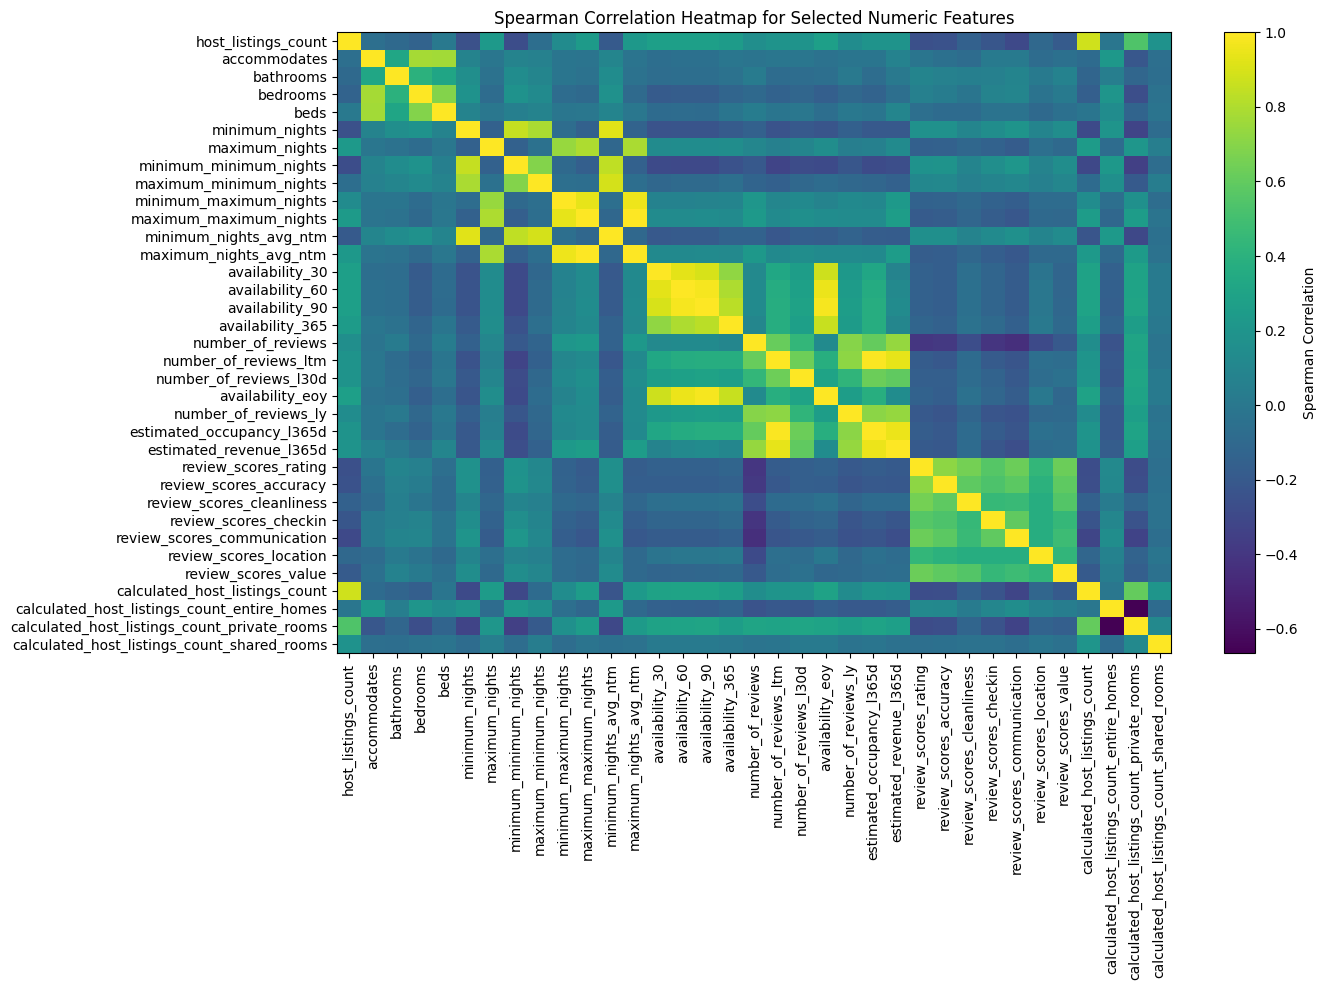

In [ ]:
# ============================================================
# Section 44: Visualize Numeric Correlation Heatmap
# ============================================================

important_corr_keywords = [
    "price",
    "accommodates",
    "bed",
    "bath",
    "minimum",
    "maximum",
    "availability",
    "review",
    "host_listings",
    "occupancy",
    "revenue",
    "outlier"
]

selected_corr_columns = []

for col in numeric_corr_columns:
    if any(keyword in col.lower() for keyword in important_corr_keywords):
        selected_corr_columns.append(col)

# Limit size for readability.
selected_corr_columns = selected_corr_columns[:35]

if len(selected_corr_columns) >= 2:
    selected_corr = df_fq[selected_corr_columns].corr(method="spearman")
    
    plt.figure(figsize=(14, 10))
    plt.imshow(selected_corr, aspect="auto")
    plt.colorbar(label="Spearman Correlation")
    plt.xticks(range(len(selected_corr_columns)), selected_corr_columns, rotation=90)
    plt.yticks(range(len(selected_corr_columns)), selected_corr_columns)
    plt.title("Spearman Correlation Heatmap for Selected Numeric Features")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns selected for heatmap.")

## 45. Data Leakage Candidate Detection

Data leakage occurs when a feature contains information that would not be available at prediction time or directly reveals the target.

Leakage can create unrealistically high performance.

We define two task-specific leakage checks:

### Regression leakage risk

For price prediction, we must not use:

- Raw price column
- Cleaned price target
- Log or winsorized versions of the price target
- Revenue variables that are mechanically derived from price

### Classification leakage risk

For superhost prediction, we must not use:

- Raw superhost column
- Cleaned superhost target
- Any column directly encoding the target

Some review and host-performance variables may be related to superhost status, but they are not automatically direct leakage. They should be marked as high-risk and discussed carefully.

In [ ]:
# ============================================================
# Section 45: Data Leakage Candidate Detection
# ============================================================

def detect_regression_leakage_risk(column_name):
    col = column_name.lower()
    
    if column_name in ["price", "price_numeric"]:
        return "direct_target"
    
    if "price_numeric" in col:
        return "target_derived"
    
    if col.startswith("log1p_price") or "price_numeric_winsorized" in col:
        return "target_derived"
    
    if "revenue" in col:
        return "high_risk_derived_from_price"
    
    return "no_direct_leakage_detected"


def detect_classification_leakage_risk(column_name):
    col = column_name.lower()
    
    if column_name in ["host_is_superhost", "superhost_binary"]:
        return "direct_target"
    
    if "superhost" in col:
        return "target_derived"
    
    return "no_direct_leakage_detected"


leakage_rows = []

for col in df_fq.columns:
    regression_risk = detect_regression_leakage_risk(col)
    classification_risk = detect_classification_leakage_risk(col)
    
    if (
        regression_risk != "no_direct_leakage_detected"
        or classification_risk != "no_direct_leakage_detected"
    ):
        leakage_rows.append({
            "column": col,
            "regression_price_prediction_risk": regression_risk,
            "classification_superhost_prediction_risk": classification_risk
        })

leakage_candidate_table = pd.DataFrame(leakage_rows)

display(leakage_candidate_table)

,column,regression_price_prediction_risk,classification_superhost_prediction_risk
0,host_is_superhost,no_direct_leakage_detected,direct_target
1,price,direct_target,no_direct_leakage_detected
2,estimated_revenue_l365d,high_risk_derived_from_price,no_direct_leakage_detected
3,price_numeric,direct_target,no_direct_leakage_detected
4,superhost_binary,no_direct_leakage_detected,direct_target
5,is_missing__price_numeric,target_derived,no_direct_leakage_detected
6,is_missing__host_is_superhost,no_direct_leakage_detected,target_derived
7,is_missing__superhost_binary,no_direct_leakage_detected,target_derived
8,is_missing__estimated_revenue_l365d,high_risk_derived_from_price,no_direct_leakage_detected
9,log1p_price_numeric,target_derived,no_direct_leakage_detected


## 46. Target Association Diagnostic

Strong association with the target is not automatically leakage.

A useful feature should be related to the target.

However, extremely high association may indicate:

- Direct target leakage
- A target-derived variable
- A duplicate version of the target
- A feature that would not be available at prediction time

In this section, we compute simple target associations for numerical features.

For the regression target, we use Spearman correlation with `price_numeric`.

For the classification target, we compare feature means between superhost and non-superhost groups.

In [ ]:
# ============================================================
# Section 46: Target Association Diagnostic
# ============================================================

target_association_rows = []

# Regression target association
if regression_target in df_fq.columns:
    for col in numeric_corr_columns:
        if col == regression_target:
            continue
        
        temp = df_fq[[col, regression_target]].dropna()
        
        if len(temp) < 30:
            continue
        
        corr_value = temp[col].corr(temp[regression_target], method="spearman")
        
        target_association_rows.append({
            "feature": col,
            "target": regression_target,
            "association_type": "spearman_corr",
            "association_value": corr_value,
            "abs_association_value": abs(corr_value) if pd.notna(corr_value) else np.nan
        })

# Classification target association
if classification_target in df_fq.columns:
    for col in numeric_corr_columns:
        if col == classification_target:
            continue
        
        temp = df_fq[[col, classification_target]].dropna()
        
        if len(temp) < 30 or temp[classification_target].nunique() < 2:
            continue
        
        group_0 = temp.loc[temp[classification_target] == 0, col]
        group_1 = temp.loc[temp[classification_target] == 1, col]
        
        if len(group_0) < 10 or len(group_1) < 10:
            continue
        
        mean_difference = group_1.mean() - group_0.mean()
        pooled_std = temp[col].std()
        
        if pd.isna(pooled_std) or pooled_std == 0:
            standardized_difference = np.nan
        else:
            standardized_difference = mean_difference / pooled_std
        
        target_association_rows.append({
            "feature": col,
            "target": classification_target,
            "association_type": "standardized_mean_difference",
            "association_value": standardized_difference,
            "abs_association_value": abs(standardized_difference) if pd.notna(standardized_difference) else np.nan
        })

target_association_table = pd.DataFrame(target_association_rows)

if len(target_association_table) > 0:
    target_association_table = target_association_table.sort_values(
        "abs_association_value",
        ascending=False
    ).reset_index(drop=True)

display(target_association_table.head(80))

,feature,target,association_type,association_value,abs_association_value
0,estimated_occupancy_l365d_winsorized_p01_p99,superhost_binary,standardized_mean_difference,1.501200,1.501200
1,estimated_occupancy_l365d,superhost_binary,standardized_mean_difference,1.501200,1.501200
2,log1p_estimated_occupancy_l365d,superhost_binary,standardized_mean_difference,1.237108,1.237108
3,log1p_number_of_reviews,superhost_binary,standardized_mean_difference,1.222103,1.222103
4,log1p_reviews_per_month,superhost_binary,standardized_mean_difference,1.206509,1.206509
5,number_of_reviews_winsorized_p01_p99,superhost_binary,standardized_mean_difference,1.134733,1.134733
6,estimated_revenue_l365d_winsorized_p01_p99,superhost_binary,standardized_mean_difference,1.115733,1.115733
7,reviews_per_month_winsorized_p01_p99,superhost_binary,standardized_mean_difference,1.110914,1.110914
8,simple_iforest_score,superhost_binary,standardized_mean_difference,1.003633,1.003633
9,log1p_price_numeric,price_numeric,spearman_corr,1.000000,1.000000


## 47. Building the Final Feature Quality Decision Table

Now we combine all feature-quality signals into one decision table.

For each column, we consider:

- Feature type
- Missing rate
- Constant or near-constant status
- High-cardinality risk
- Redundancy risk
- Regression leakage risk
- Classification leakage risk

The table gives task-specific recommendations:

- Recommendation for price regression
- Recommendation for superhost classification

This table is not only useful for modeling, but also for the final report because it documents the feature selection logic.

In [ ]:
# ============================================================
# Section 47: Build Final Feature Quality Decision Table
# ============================================================

near_constant_set = set(near_constant_table["column"]) if len(near_constant_table) > 0 else set()

high_cardinality_map = {}
if len(high_cardinality_table) > 0:
    high_cardinality_map = dict(
        zip(high_cardinality_table["column"], high_cardinality_table["recommendation"])
    )

# Features appearing in highly correlated pairs.
redundant_feature_set = set()
if len(redundant_pairs_table) > 0:
    redundant_feature_set.update(redundant_pairs_table["feature_1"].tolist())
    redundant_feature_set.update(redundant_pairs_table["feature_2"].tolist())

def base_feature_quality_flag(col):
    if col in near_constant_set:
        return "near_constant_or_constant"
    
    if col in high_cardinality_map:
        return high_cardinality_map[col]
    
    if col in redundant_feature_set:
        return "redundancy_review"
    
    return "no_major_quality_issue_detected"


def regression_recommendation(col):
    regression_risk = detect_regression_leakage_risk(col)
    
    if regression_risk in ["direct_target", "target_derived", "high_risk_derived_from_price"]:
        return "drop_for_price_regression_leakage_risk"
    
    if col in [classification_target, "host_is_superhost"]:
        return "review_task_specific_target_feature"
    
    quality_flag = base_feature_quality_flag(col)
    
    if quality_flag == "near_constant_or_constant":
        return "drop_near_constant"
    
    if quality_flag == "drop_identifier_like":
        return "drop_identifier_like"
    
    if quality_flag == "use_engineered_text_features_only":
        return "drop_raw_text_keep_engineered_features"
    
    if quality_flag == "keep_with_grouping_or_frequency_encoding":
        return "keep_with_encoding_strategy"
    
    if quality_flag == "redundancy_review":
        return "keep_or_drop_after_redundancy_review"
    
    return "keep_candidate"


def classification_recommendation(col):
    classification_risk = detect_classification_leakage_risk(col)
    
    if classification_risk in ["direct_target", "target_derived"]:
        return "drop_for_superhost_classification_leakage_risk"
    
    if col in [regression_target, "price"]:
        return "review_task_specific_target_feature"
    
    quality_flag = base_feature_quality_flag(col)
    
    if quality_flag == "near_constant_or_constant":
        return "drop_near_constant"
    
    if quality_flag == "drop_identifier_like":
        return "drop_identifier_like"
    
    if quality_flag == "use_engineered_text_features_only":
        return "drop_raw_text_keep_engineered_features"
    
    if quality_flag == "keep_with_grouping_or_frequency_encoding":
        return "keep_with_encoding_strategy"
    
    if quality_flag == "redundancy_review":
        return "keep_or_drop_after_redundancy_review"
    
    return "keep_candidate"


feature_quality_rows = []

for col in df_fq.columns:
    inventory_row = feature_inventory_table.loc[
        feature_inventory_table["column"] == col
    ].iloc[0]
    
    feature_quality_rows.append({
        "column": col,
        "dtype": str(df_fq[col].dtype),
        "feature_type": inventory_row["feature_type"],
        "missing_rate": df_fq[col].isna().mean(),
        "unique_count": df_fq[col].nunique(dropna=False),
        "unique_rate": df_fq[col].nunique(dropna=False) / len(df_fq),
        "quality_flag": base_feature_quality_flag(col),
        "regression_leakage_risk": detect_regression_leakage_risk(col),
        "classification_leakage_risk": detect_classification_leakage_risk(col),
        "price_regression_recommendation": regression_recommendation(col),
        "superhost_classification_recommendation": classification_recommendation(col)
    })

feature_quality_decision_table = pd.DataFrame(feature_quality_rows)

display(feature_quality_decision_table.sort_values(
    ["price_regression_recommendation", "superhost_classification_recommendation", "missing_rate"],
    ascending=[True, True, False]
))

,column,dtype,feature_type,missing_rate,unique_count,unique_rate,quality_flag,regression_leakage_risk,classification_leakage_risk,price_regression_recommendation,superhost_classification_recommendation
62,estimated_revenue_l365d,float64,numeric,0.439504,2637,0.251622,redundancy_review,high_risk_derived_from_price,no_direct_leakage_detected,drop_for_price_regression_leakage_risk,keep_or_drop_after_redundancy_review
124,log1p_price_numeric,float64,numeric,0.439504,664,0.063359,redundancy_review,target_derived,no_direct_leakage_detected,drop_for_price_regression_leakage_risk,keep_or_drop_after_redundancy_review
130,log1p_estimated_revenue_l365d,float64,numeric,0.439504,2637,0.251622,redundancy_review,high_risk_derived_from_price,no_direct_leakage_detected,drop_for_price_regression_leakage_risk,keep_or_drop_after_redundancy_review
131,price_numeric_winsorized_p01_p99,float64,numeric,0.439504,596,0.056870,redundancy_review,target_derived,no_direct_leakage_detected,drop_for_price_regression_leakage_risk,keep_or_drop_after_redundancy_review
137,estimated_revenue_l365d_winsorized_p01_p99,float64,numeric,0.439504,2580,0.246183,redundancy_review,high_risk_derived_from_price,no_direct_leakage_detected,drop_for_price_regression_leakage_risk,keep_or_drop_after_redundancy_review
...,...,...,...,...,...,...,...,...,...,...,...
136,estimated_occupancy_l365d_winsorized_p01_p99,int64,numeric,0.000000,96,0.009160,redundancy_review,no_direct_leakage_detected,no_direct_leakage_detected,keep_or_drop_after_redundancy_review,keep_or_drop_after_redundancy_review
21,host_neighbourhood,object,categorical_or_text,0.733779,73,0.006966,keep_with_grouping_or_frequency_encoding,no_direct_leakage_detected,no_direct_leakage_detected,keep_with_encoding_strategy,keep_with_encoding_strategy
32,property_type,object,categorical_or_text,0.000000,63,0.006011,keep_with_grouping_or_frequency_encoding,no_direct_leakage_detected,no_direct_leakage_detected,keep_with_encoding_strategy,keep_with_encoding_strategy
18,host_is_superhost,object,target_or_raw_target,0.010973,3,0.000286,no_major_quality_issue_detected,no_direct_leakage_detected,direct_target,review_task_specific_target_feature,drop_for_superhost_classification_leakage_risk


## 48. Creating Task-Specific Candidate Feature Lists

The regression and classification tasks should not always use exactly the same feature set.

For price regression, we remove price-derived leakage variables.

For superhost classification, we remove superhost-derived leakage variables.

We also remove obvious identifiers, raw text columns, near-constant variables, and direct target columns.

The result is two candidate feature lists:

1. `price_regression_candidate_features`
2. `superhost_classification_candidate_features`

These lists will be used in the modeling pipeline.

In [ ]:
# ============================================================
# Section 48: Create Task-Specific Candidate Feature Lists
# ============================================================

price_regression_candidate_features = feature_quality_decision_table.loc[
    feature_quality_decision_table["price_regression_recommendation"].isin([
        "keep_candidate",
        "keep_with_encoding_strategy",
        "keep_or_drop_after_redundancy_review",
        "review_task_specific_target_feature"
    ]),
    "column"
].tolist()

superhost_classification_candidate_features = feature_quality_decision_table.loc[
    feature_quality_decision_table["superhost_classification_recommendation"].isin([
        "keep_candidate",
        "keep_with_encoding_strategy",
        "keep_or_drop_after_redundancy_review",
        "review_task_specific_target_feature"
    ]),
    "column"
].tolist()

# Remove raw targets defensively.
price_regression_candidate_features = [
    col for col in price_regression_candidate_features
    if col not in ["price", "price_numeric", "log1p_price_numeric"]
]

superhost_classification_candidate_features = [
    col for col in superhost_classification_candidate_features
    if col not in ["host_is_superhost", "superhost_binary"]
]

print("Number of candidate features for price regression:")
print(len(price_regression_candidate_features))

print("\nNumber of candidate features for superhost classification:")
print(len(superhost_classification_candidate_features))

print("\nFirst 50 price regression candidate features:")
print(price_regression_candidate_features[:50])

print("\nFirst 50 superhost classification candidate features:")
print(superhost_classification_candidate_features[:50])

Number of candidate features for price regression:
107

Number of candidate features for superhost classification:
112

First 50 price regression candidate features:
['id', 'source', 'neighborhood_overview', 'host_id', 'host_since', 'host_location', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_revi

## 49. Saving Feature Quality Outputs

We save all feature-quality outputs for reproducibility and for the final report.

Saved files include:

- Feature inventory table
- Near-constant feature table
- High-cardinality categorical table
- Redundant numerical feature pairs
- Leakage candidate table
- Target association table
- Final feature quality decision table
- Task-specific candidate feature lists

In [ ]:
# ============================================================
# Section 49: Save Feature Quality Outputs
# ============================================================

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

feature_inventory_path = OUTPUT_DIR / "airbnb_feature_inventory.csv"
near_constant_path = OUTPUT_DIR / "airbnb_near_constant_features.csv"
high_cardinality_path = OUTPUT_DIR / "airbnb_high_cardinality_categorical_features.csv"
redundant_pairs_path = OUTPUT_DIR / "airbnb_redundant_numeric_pairs.csv"
leakage_candidates_path = OUTPUT_DIR / "airbnb_leakage_candidates.csv"
target_association_path = OUTPUT_DIR / "airbnb_target_association_diagnostic.csv"
feature_quality_decision_path = OUTPUT_DIR / "airbnb_feature_quality_decision_table.csv"
price_features_path = OUTPUT_DIR / "airbnb_price_regression_candidate_features.csv"
superhost_features_path = OUTPUT_DIR / "airbnb_superhost_classification_candidate_features.csv"

feature_inventory_table.to_csv(feature_inventory_path, index=False)
near_constant_table.to_csv(near_constant_path, index=False)
high_cardinality_table.to_csv(high_cardinality_path, index=False)
redundant_pairs_table.to_csv(redundant_pairs_path, index=False)
leakage_candidate_table.to_csv(leakage_candidates_path, index=False)
target_association_table.to_csv(target_association_path, index=False)
feature_quality_decision_table.to_csv(feature_quality_decision_path, index=False)

pd.DataFrame({
    "feature": price_regression_candidate_features
}).to_csv(price_features_path, index=False)

pd.DataFrame({
    "feature": superhost_classification_candidate_features
}).to_csv(superhost_features_path, index=False)

print("Saved feature quality files:")
print(f"1. {feature_inventory_path}")
print(f"2. {near_constant_path}")
print(f"3. {high_cardinality_path}")
print(f"4. {redundant_pairs_path}")
print(f"5. {leakage_candidates_path}")
print(f"6. {target_association_path}")
print(f"7. {feature_quality_decision_path}")
print(f"8. {price_features_path}")
print(f"9. {superhost_features_path}")

Saved feature quality files:
1. outputs\airbnb_feature_inventory.csv
2. outputs\airbnb_near_constant_features.csv
3. outputs\airbnb_high_cardinality_categorical_features.csv
4. outputs\airbnb_redundant_numeric_pairs.csv
5. outputs\airbnb_leakage_candidates.csv
6. outputs\airbnb_target_association_diagnostic.csv
7. outputs\airbnb_feature_quality_decision_table.csv
8. outputs\airbnb_price_regression_candidate_features.csv
9. outputs\airbnb_superhost_classification_candidate_features.csv


## 50. Report-Ready Feature Quality Summary

The Airbnb dataset contains multiple feature-quality challenges that must be addressed before modeling.

First, identifier-like variables such as IDs, URLs, names, image links, and scraping metadata are not suitable as predictive features. These variables may memorize individual listings instead of learning generalizable patterns.

Second, near-constant features are removed or marked for removal because they contain little predictive signal and may increase computational cost.

Third, high-cardinality categorical variables are handled carefully. Identifier-like high-cardinality features are dropped, while meaningful location or property-related variables can be retained using an appropriate encoding strategy.

Fourth, numerical redundancy is investigated using Spearman correlation. Strongly correlated features are not blindly removed, but they are marked for redundancy review. This is important because variables such as availability windows and host listing counts may carry overlapping information.

Fifth, data leakage is handled separately for the two prediction tasks. For price regression, price-derived features and revenue variables are treated as leakage risks. For superhost classification, direct superhost columns are removed from the input feature set.

The final result is a task-specific feature selection strategy: one candidate feature set for price regression and another candidate feature set for superhost classification.

## 51. Modeling Dataset Construction Overview

After missing value analysis, outlier analysis, and feature quality analysis, we construct the final modeling datasets for the five-city Airbnb dataset.

This section prepares two supervised learning datasets:

### Task 1: Price Regression

Target: `price_numeric`

The goal is to predict Airbnb listing price across all five cities. Because price is usually highly skewed, we also create a log-transformed target:

`log1p_price_target = log(1 + price_numeric)`

### Task 2: Superhost Classification

Target: `superhost_binary`

The goal is to predict whether the host is a superhost.

The final pipeline includes:

- Removing rows with invalid or missing targets
- Using task-specific feature lists
- Adding city-aware and date-based features
- Encoding categorical features without scikit-learn
- Scaling numerical features using only training-set statistics
- Splitting train/test data from scratch
- Saving final arrays for from-scratch non-kernel and kernel models

In [ ]:
# ============================================================
# Section 51: Modeling Dataset Construction Overview Setup
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import math
import json
import warnings

warnings.filterwarnings("ignore")

if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Modeling setup is ready.")
print(f"Random state: {RANDOM_STATE}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

## 52. Loading Feature Quality Outputs and Working Dataframe

We continue from the feature-quality stage.

The preferred dataframe is `df_outlier_treated` because it contains:

- Cleaned target variables
- Missingness indicators
- Outlier indicators
- Log-transformed variables
- Winsorized variables
- The new `city` column for five-city analysis

We also load the task-specific candidate feature lists created in the previous section.

In [ ]:
# ============================================================
# Section 52: Load Feature Quality Outputs and Working Dataframe
# ============================================================

outlier_treated_path = OUTPUT_DIR / "airbnb_outlier_treated_dataframe.csv"
price_features_path = OUTPUT_DIR / "airbnb_price_regression_candidate_features.csv"
superhost_features_path = OUTPUT_DIR / "airbnb_superhost_classification_candidate_features.csv"
feature_quality_decision_path = OUTPUT_DIR / "airbnb_feature_quality_decision_table.csv"

# Load dataframe
if "df_outlier_treated" in globals():
    df_model_base = df_outlier_treated.copy()
    print("Using df_outlier_treated from memory.")
elif outlier_treated_path.exists():
    df_model_base = pd.read_csv(outlier_treated_path)
    print(f"Loaded dataframe from: {outlier_treated_path}")
elif "df_fq" in globals():
    df_model_base = df_fq.copy()
    print("Using df_fq from memory.")
elif "df" in globals():
    df_model_base = df.copy()
    print("Using df from memory.")
else:
    raise NameError("No Airbnb dataframe found. Please run previous sections first.")

# Load candidate feature lists if not already in memory
if "price_regression_candidate_features" not in globals():
    if price_features_path.exists():
        price_regression_candidate_features = pd.read_csv(price_features_path)["feature"].tolist()
        print(f"Loaded price regression feature list from: {price_features_path}")
    else:
        raise FileNotFoundError("Price regression candidate feature file not found. Run Section 49 first.")

if "superhost_classification_candidate_features" not in globals():
    if superhost_features_path.exists():
        superhost_classification_candidate_features = pd.read_csv(superhost_features_path)["feature"].tolist()
        print(f"Loaded superhost classification feature list from: {superhost_features_path}")
    else:
        raise FileNotFoundError("Superhost classification candidate feature file not found. Run Section 49 first.")

if "feature_quality_decision_table" not in globals() and feature_quality_decision_path.exists():
    feature_quality_decision_table = pd.read_csv(feature_quality_decision_path)

print("\nBase dataframe shape:", df_model_base.shape)
print("Columns:", len(df_model_base.columns))

if "city" not in df_model_base.columns:
    raise ValueError("The five-city dataframe must contain a `city` column. Please rerun the five-city loading section.")

print("\nCity distribution:")
display(df_model_base["city"].value_counts(dropna=False))

print("\nNumber of price candidate features:", len(price_regression_candidate_features))
print("Number of superhost candidate features:", len(superhost_classification_candidate_features))

display(df_model_base.head())

## 53. Final Target Validation

Before creating train/test datasets, we validate both targets.

For price regression:

- The target must be numeric.
- Missing prices are removed.
- Non-positive prices are invalid and removed.
- A log-transformed version of the target is created.

For superhost classification:

- The target must be binary.
- Missing labels are removed.
- Only values `0` and `1` are accepted.

We also summarize target validity by city, because this project now combines five Airbnb markets.

In [ ]:
# ============================================================
# Section 53: Final Target Validation
# ============================================================

df_model = df_model_base.copy()

# Recreate price_numeric if needed.
if "price_numeric" not in df_model.columns and "price" in df_model.columns:
    def clean_price(value):
        if pd.isna(value):
            return np.nan
        value = str(value).replace("$", "").replace(",", "").strip()
        try:
            return float(value)
        except ValueError:
            return np.nan
    df_model["price_numeric"] = df_model["price"].apply(clean_price)

# Recreate superhost_binary if needed.
if "superhost_binary" not in df_model.columns and "host_is_superhost" in df_model.columns:
    def clean_superhost(value):
        if pd.isna(value):
            return np.nan
        value = str(value).strip().lower()
        if value == "t":
            return 1
        if value == "f":
            return 0
        return np.nan
    df_model["superhost_binary"] = df_model["host_is_superhost"].apply(clean_superhost)

if "price_numeric" not in df_model.columns:
    raise ValueError("price_numeric target could not be created.")
if "superhost_binary" not in df_model.columns:
    raise ValueError("superhost_binary target could not be created.")

price_valid_mask = (
    df_model["price_numeric"].notna()
    & np.isfinite(df_model["price_numeric"].astype(float))
    & (df_model["price_numeric"].astype(float) > 0)
)

superhost_valid_mask = (
    df_model["superhost_binary"].notna()
    & df_model["superhost_binary"].isin([0, 1])
)

df_price_task = df_model.loc[price_valid_mask].copy()
df_superhost_task = df_model.loc[superhost_valid_mask].copy()

df_price_task["log1p_price_target"] = np.log1p(df_price_task["price_numeric"].astype(float))

target_validation_summary = pd.DataFrame({
    "task": ["price_regression", "superhost_classification"],
    "target": ["price_numeric", "superhost_binary"],
    "original_rows": [len(df_model), len(df_model)],
    "valid_rows": [len(df_price_task), len(df_superhost_task)],
    "removed_rows": [len(df_model) - len(df_price_task), len(df_model) - len(df_superhost_task)],
    "removed_rate": [
        (len(df_model) - len(df_price_task)) / max(len(df_model), 1),
        (len(df_model) - len(df_superhost_task)) / max(len(df_model), 1)
    ]
})

display(target_validation_summary)

city_target_summary = (
    df_model.assign(
        valid_price_target=price_valid_mask.astype(int),
        valid_superhost_target=superhost_valid_mask.astype(int)
    )
    .groupby("city", dropna=False)
    .agg(
        rows=("city", "size"),
        valid_price_rows=("valid_price_target", "sum"),
        valid_superhost_rows=("valid_superhost_target", "sum"),
        median_price=("price_numeric", "median"),
        mean_price=("price_numeric", "mean"),
        superhost_rate=("superhost_binary", "mean")
    )
    .reset_index()
)
city_target_summary["valid_price_rate"] = city_target_summary["valid_price_rows"] / city_target_summary["rows"]
city_target_summary["valid_superhost_rate"] = city_target_summary["valid_superhost_rows"] / city_target_summary["rows"]

display(city_target_summary)

print("Price target summary:")
display(df_price_task["price_numeric"].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]))

print("\nLog-price target summary:")
display(df_price_task["log1p_price_target"].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]))

print("\nSuperhost target distribution:")
display(df_superhost_task["superhost_binary"].value_counts(dropna=False))
display(df_superhost_task["superhost_binary"].value_counts(normalize=True, dropna=False))

## 54. Date Feature Engineering

Some Airbnb columns are dates stored as text.

Raw date strings cannot be directly used by the from-scratch numerical models. Instead, we convert date columns into interpretable numerical features.

Examples:

- `days_since_host_since`
- `days_since_first_review`
- `days_since_last_review`
- `days_since_calendar_last_scraped`

We use the maximum observed date inside each task dataframe as the reference date. This avoids hard-coding an external future date and keeps the features tied to the dataset snapshot.

In [ ]:
# ============================================================
# Section 54: Date Feature Engineering
# ============================================================

def add_date_features(data, date_columns):
    """
    Convert raw date columns into numerical day-difference features.
    """
    df_dates = data.copy()
    existing_date_columns = [col for col in date_columns if col in df_dates.columns]
    if len(existing_date_columns) == 0:
        return df_dates, [], pd.DataFrame()

    parsed_dates = {col: pd.to_datetime(df_dates[col], errors="coerce") for col in existing_date_columns}
    all_dates = pd.concat([parsed_dates[col] for col in existing_date_columns], axis=0)
    reference_date = all_dates.max()
    if pd.isna(reference_date):
        return df_dates, [], pd.DataFrame()

    created_features = []
    rows = []
    for col in existing_date_columns:
        safe_col_name = col.replace(" ", "_")
        new_col = f"days_since_{safe_col_name}"
        df_dates[new_col] = (reference_date - parsed_dates[col]).dt.days
        created_features.append(new_col)
        rows.append({
            "raw_date_column": col,
            "created_feature": new_col,
            "reference_date": reference_date,
            "missing_rate_raw_date": df_dates[col].isna().mean(),
            "missing_rate_created_feature": df_dates[new_col].isna().mean(),
            "median_created_feature": df_dates[new_col].median()
        })
    return df_dates, created_features, pd.DataFrame(rows)

raw_date_columns = [
    "host_since",
    "calendar_last_scraped",
    "first_review",
    "last_review"
]

df_price_task, price_date_features, price_date_feature_table = add_date_features(df_price_task, raw_date_columns)
df_superhost_task, superhost_date_features, superhost_date_feature_table = add_date_features(df_superhost_task, raw_date_columns)

print("Price task date features:")
print(price_date_features)
print("\nSuperhost task date features:")
print(superhost_date_features)

print("\nPrice task date feature table:")
display(price_date_feature_table)

print("\nSuperhost task date feature table:")
display(superhost_date_feature_table)

## 55. Final Task-Specific Feature Lists

We now update the candidate feature lists.

Rules:

1. Keep only columns that exist in the task dataframe.
2. Remove raw targets.
3. Remove raw date columns after engineering numerical date features.
4. Add engineered date features.
5. Remove raw text fields if they still exist.
6. Remove leakage variables for each task.
7. Keep `city` as a categorical feature because the dataset now contains five different markets.

In [ ]:
# ============================================================
# Section 55: Final Task-Specific Feature Lists
# ============================================================

raw_text_columns = [
    "description",
    "neighborhood_overview",
    "host_about",
    "amenities"
]

raw_target_columns = [
    "price",
    "price_numeric",
    "log1p_price_numeric",
    "log1p_price_target",
    "host_is_superhost",
    "superhost_binary"
]

raw_date_columns = [
    "host_since",
    "calendar_last_scraped",
    "first_review",
    "last_review"
]

# Features that should not be used as model inputs because they are identifiers or raw metadata.
explicit_model_drop_columns = [
    "id", "host_id", "listing_url", "scrape_id", "last_scraped", "source",
    "picture_url", "host_url", "host_thumbnail_url", "host_picture_url",
    "name", "host_name", "license", "calendar_updated"
]

def clean_feature_list(feature_list, dataframe, engineered_date_features, task_name):
    features = list(feature_list)

    # Ensure city is included for five-city modeling.
    if "city" in dataframe.columns and "city" not in features:
        features.append("city")

    # Keep existing columns only.
    features = [col for col in features if col in dataframe.columns]

    remove_set = set(raw_target_columns + raw_text_columns + raw_date_columns + explicit_model_drop_columns)
    features = [col for col in features if col not in remove_set]

    # Task-specific leakage handling.
    if task_name == "price_regression":
        features = [
            col for col in features
            if "price_numeric" not in col.lower()
            and not col.lower().startswith("log1p_price")
            and "revenue" not in col.lower()
            and col != "price"
        ]

    if task_name == "superhost_classification":
        features = [
            col for col in features
            if "superhost" not in col.lower()
            and col not in ["host_is_superhost", "superhost_binary"]
        ]

    # Add engineered date features.
    for col in engineered_date_features:
        if col in dataframe.columns and col not in features:
            features.append(col)

    # Remove duplicate names while preserving order.
    features = list(dict.fromkeys(features))
    return features

final_price_features = clean_feature_list(
    price_regression_candidate_features,
    df_price_task,
    price_date_features,
    task_name="price_regression"
)

final_superhost_features = clean_feature_list(
    superhost_classification_candidate_features,
    df_superhost_task,
    superhost_date_features,
    task_name="superhost_classification"
)

print("Final number of price regression raw features:", len(final_price_features))
print("Final number of superhost classification raw features:", len(final_superhost_features))

print("\nFinal price features preview:")
print(final_price_features[:100])

print("\nFinal superhost features preview:")
print(final_superhost_features[:100])

final_feature_list_summary = pd.DataFrame({
    "task": ["price_regression", "superhost_classification"],
    "n_raw_features": [len(final_price_features), len(final_superhost_features)],
    "contains_city": ["city" in final_price_features, "city" in final_superhost_features]
})
display(final_feature_list_summary)

## 56. Train/Test Split from Scratch

We implement train/test splitting manually using NumPy.

For price regression, we use a random split.

For superhost classification, we use a stratified split to preserve the class distribution of the superhost target in both training and testing sets.

The split keeps row positions so that later we can perform city-level error analysis and worst-prediction inspection.

In [ ]:
# ============================================================
# Section 56: Train/Test Split from Scratch
# ============================================================

def train_test_split_numpy_indices(n_samples, test_size=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = np.arange(n_samples)
    rng.shuffle(indices)
    n_test = int(np.ceil(test_size * n_samples))
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]
    return train_indices, test_indices


def stratified_train_test_split_numpy_indices(y, test_size=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    train_indices = []
    test_indices = []
    for class_value in np.unique(y):
        class_indices = np.where(y == class_value)[0]
        rng.shuffle(class_indices)
        n_test_class = int(np.ceil(test_size * len(class_indices)))
        test_indices.extend(class_indices[:n_test_class])
        train_indices.extend(class_indices[n_test_class:])
    train_indices = np.array(train_indices, dtype=int)
    test_indices = np.array(test_indices, dtype=int)
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)
    return train_indices, test_indices

price_train_idx, price_test_idx = train_test_split_numpy_indices(
    n_samples=len(df_price_task),
    test_size=0.25,
    random_state=RANDOM_STATE
)

superhost_y_for_split = df_superhost_task["superhost_binary"].astype(int).values
superhost_train_idx, superhost_test_idx = stratified_train_test_split_numpy_indices(
    y=superhost_y_for_split,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Price regression split:")
print(f"Train rows: {len(price_train_idx)}")
print(f"Test rows:  {len(price_test_idx)}")

print("\nSuperhost classification split:")
print(f"Train rows: {len(superhost_train_idx)}")
print(f"Test rows:  {len(superhost_test_idx)}")

split_city_summary = pd.concat([
    df_price_task.iloc[price_train_idx].assign(task="price", split="train")[["city", "task", "split"]],
    df_price_task.iloc[price_test_idx].assign(task="price", split="test")[["city", "task", "split"]],
    df_superhost_task.iloc[superhost_train_idx].assign(task="superhost", split="train")[["city", "task", "split"]],
    df_superhost_task.iloc[superhost_test_idx].assign(task="superhost", split="test")[["city", "task", "split"]]
], axis=0)

split_city_table = (
    split_city_summary
    .groupby(["task", "split", "city"], dropna=False)
    .size()
    .reset_index(name="rows")
)

display(split_city_table)

print("\nSuperhost class distribution in full data:")
display(df_superhost_task["superhost_binary"].value_counts(normalize=True))
print("\nSuperhost class distribution in train:")
display(df_superhost_task.iloc[superhost_train_idx]["superhost_binary"].value_counts(normalize=True))
print("\nSuperhost class distribution in test:")
display(df_superhost_task.iloc[superhost_test_idx]["superhost_binary"].value_counts(normalize=True))

## 57. From-Scratch Tabular Preprocessor

The models implemented later require numerical matrices.

The Airbnb dataframe contains both numerical and categorical features, so we implement a custom preprocessing class from scratch.

### Numerical features

- Fill missing values using the median computed from training data only.
- Robustly scale values using median and IQR.
- Clip extreme scaled values for numerical stability.

### Categorical features

- Fill missing values with `Unknown`.
- Keep only the most frequent categories from the training data.
- Map rare categories to `Other`.
- One-hot encode categories manually.

All preprocessing parameters are fitted only on the training set. The test set is transformed using the training parameters. This avoids preprocessing leakage.

In [ ]:
# ============================================================
# Section 57: From-Scratch Tabular Preprocessor
# ============================================================

class FromScratchTabularPreprocessor:
    """
    A simple tabular preprocessor implemented from scratch.

    It handles:
    - Numeric median imputation
    - Numeric robust scaling
    - Categorical Unknown filling
    - Top-K categorical one-hot encoding
    """
    def __init__(self, max_categories_per_feature=20, clip_value=10.0):
        self.max_categories_per_feature = max_categories_per_feature
        self.clip_value = clip_value
        self.numeric_columns_ = []
        self.categorical_columns_ = []
        self.numeric_medians_ = {}
        self.numeric_iqrs_ = {}
        self.categorical_levels_ = {}
        self.feature_names_ = []

    def fit(self, X_df):
        X_df = X_df.copy()
        self.numeric_columns_ = [
            col for col in X_df.columns
            if pd.api.types.is_numeric_dtype(X_df[col]) and X_df[col].nunique(dropna=True) > 1
        ]
        self.categorical_columns_ = [col for col in X_df.columns if col not in self.numeric_columns_]

        for col in self.numeric_columns_:
            x = pd.to_numeric(X_df[col], errors="coerce")
            median_value = x.median()
            q1 = x.quantile(0.25)
            q3 = x.quantile(0.75)
            iqr = q3 - q1
            if pd.isna(median_value):
                median_value = 0.0
            if pd.isna(iqr) or iqr == 0:
                iqr = 1.0
            self.numeric_medians_[col] = float(median_value)
            self.numeric_iqrs_[col] = float(iqr)

        for col in self.categorical_columns_:
            s = X_df[col].fillna("Unknown").astype(str)
            s = s.replace({"nan": "Unknown", "None": "Unknown", "NaT": "Unknown"})
            top_levels = s.value_counts().head(self.max_categories_per_feature).index.tolist()
            if "Other" not in top_levels:
                top_levels.append("Other")
            self.categorical_levels_[col] = top_levels

        self.feature_names_ = []
        for col in self.numeric_columns_:
            self.feature_names_.append(col)
        for col in self.categorical_columns_:
            for level in self.categorical_levels_[col]:
                safe_level = str(level).replace("\n", " ")[:80]
                self.feature_names_.append(f"{col}__{safe_level}")
        return self

    def transform(self, X_df):
        X_df = X_df.copy()
        matrices = []

        if len(self.numeric_columns_) > 0:
            numeric_matrix = np.zeros((len(X_df), len(self.numeric_columns_)), dtype=float)
            for j, col in enumerate(self.numeric_columns_):
                if col in X_df.columns:
                    x = pd.to_numeric(X_df[col], errors="coerce")
                else:
                    x = pd.Series(np.nan, index=X_df.index)
                x = x.fillna(self.numeric_medians_[col])
                x = (x - self.numeric_medians_[col]) / self.numeric_iqrs_[col]
                x = x.clip(-self.clip_value, self.clip_value)
                numeric_matrix[:, j] = x.values.astype(float)
            matrices.append(numeric_matrix)

        categorical_matrices = []
        for col in self.categorical_columns_:
            if col in X_df.columns:
                s = X_df[col].fillna("Unknown").astype(str)
            else:
                s = pd.Series("Unknown", index=X_df.index)
            s = s.replace({"nan": "Unknown", "None": "Unknown", "NaT": "Unknown"})
            levels = self.categorical_levels_[col]
            known_levels = set(levels)
            s = s.where(s.isin(known_levels), "Other")
            cat_matrix = np.zeros((len(X_df), len(levels)), dtype=float)
            level_to_index = {level: idx for idx, level in enumerate(levels)}
            other_index = level_to_index.get("Other", len(levels) - 1)
            for i, value in enumerate(s.values):
                cat_matrix[i, level_to_index.get(value, other_index)] = 1.0
            categorical_matrices.append(cat_matrix)

        if len(categorical_matrices) > 0:
            matrices.append(np.hstack(categorical_matrices))
        if len(matrices) == 0:
            return np.empty((len(X_df), 0), dtype=float)
        return np.hstack(matrices)

    def fit_transform(self, X_df):
        self.fit(X_df)
        return self.transform(X_df)

print("FromScratchTabularPreprocessor defined successfully.")

## 58. Building Final Price Regression Matrices

In this section, we build the final matrix for price regression.

Created objects:

- `X_train_price`
- `X_test_price`
- `y_train_price_raw`
- `y_test_price_raw`
- `y_train_price_log`
- `y_test_price_log`
- `price_train_metadata`
- `price_test_metadata`

The metadata tables preserve city and listing context for later failure analysis.

In [ ]:
# ============================================================
# Section 58: Build Final Price Regression Matrices
# ============================================================

X_price_df = df_price_task[final_price_features].copy()
y_price_raw = df_price_task["price_numeric"].values.astype(float)
y_price_log = df_price_task["log1p_price_target"].values.astype(float)

X_price_train_df = X_price_df.iloc[price_train_idx].copy()
X_price_test_df = X_price_df.iloc[price_test_idx].copy()

y_train_price_raw = y_price_raw[price_train_idx]
y_test_price_raw = y_price_raw[price_test_idx]
y_train_price_log = y_price_log[price_train_idx]
y_test_price_log = y_price_log[price_test_idx]

price_preprocessor = FromScratchTabularPreprocessor(max_categories_per_feature=20, clip_value=10.0)
X_train_price = price_preprocessor.fit_transform(X_price_train_df)
X_test_price = price_preprocessor.transform(X_price_test_df)

price_metadata_cols = [
    "city", "id", "name", "room_type", "property_type", "neighbourhood_cleansed",
    "price", "price_numeric", "accommodates", "bedrooms", "beds",
    "number_of_reviews", "reviews_per_month"
]
price_metadata_cols = [col for col in price_metadata_cols if col in df_price_task.columns]
price_train_metadata = df_price_task.iloc[price_train_idx][price_metadata_cols].copy()
price_test_metadata = df_price_task.iloc[price_test_idx][price_metadata_cols].copy()

print("Price regression matrices:")
print(f"X_train_price shape: {X_train_price.shape}")
print(f"X_test_price shape:  {X_test_price.shape}")
print(f"y_train_price_raw shape: {y_train_price_raw.shape}")
print(f"y_test_price_raw shape:  {y_test_price_raw.shape}")
print(f"y_train_price_log shape: {y_train_price_log.shape}")
print(f"y_test_price_log shape:  {y_test_price_log.shape}")
print("\nNumber of encoded price features:", len(price_preprocessor.feature_names_))
print("\nFirst 50 encoded price feature names:")
print(price_preprocessor.feature_names_[:50])

## 59. Building Final Superhost Classification Matrices

In this section, we build the final matrix for superhost classification.

Created objects:

- `X_train_superhost`
- `X_test_superhost`
- `y_train_superhost`
- `y_test_superhost`
- `superhost_train_metadata`
- `superhost_test_metadata`

The labels are binary:

- `1`: superhost
- `0`: non-superhost

In [ ]:
# ============================================================
# Section 59: Build Final Superhost Classification Matrices
# ============================================================

X_superhost_df = df_superhost_task[final_superhost_features].copy()
y_superhost = df_superhost_task["superhost_binary"].values.astype(int)

X_superhost_train_df = X_superhost_df.iloc[superhost_train_idx].copy()
X_superhost_test_df = X_superhost_df.iloc[superhost_test_idx].copy()

y_train_superhost = y_superhost[superhost_train_idx]
y_test_superhost = y_superhost[superhost_test_idx]

superhost_preprocessor = FromScratchTabularPreprocessor(max_categories_per_feature=20, clip_value=10.0)
X_train_superhost = superhost_preprocessor.fit_transform(X_superhost_train_df)
X_test_superhost = superhost_preprocessor.transform(X_superhost_test_df)

superhost_metadata_cols = [
    "city", "id", "name", "room_type", "property_type", "neighbourhood_cleansed",
    "host_is_superhost", "superhost_binary", "host_response_rate", "host_acceptance_rate",
    "review_scores_rating", "number_of_reviews", "reviews_per_month"
]
superhost_metadata_cols = [col for col in superhost_metadata_cols if col in df_superhost_task.columns]
superhost_train_metadata = df_superhost_task.iloc[superhost_train_idx][superhost_metadata_cols].copy()
superhost_test_metadata = df_superhost_task.iloc[superhost_test_idx][superhost_metadata_cols].copy()

print("Superhost classification matrices:")
print(f"X_train_superhost shape: {X_train_superhost.shape}")
print(f"X_test_superhost shape:  {X_test_superhost.shape}")
print(f"y_train_superhost shape: {y_train_superhost.shape}")
print(f"y_test_superhost shape:  {y_test_superhost.shape}")

print("\nClass distribution in y_train_superhost:")
print(pd.Series(y_train_superhost).value_counts(normalize=True))
print("\nClass distribution in y_test_superhost:")
print(pd.Series(y_test_superhost).value_counts(normalize=True))

print("\nNumber of encoded superhost features:", len(superhost_preprocessor.feature_names_))
print("\nFirst 50 encoded superhost feature names:")
print(superhost_preprocessor.feature_names_[:50])

## 60. Baseline Dataset Sanity Checks

Before training models, we verify that the final matrices are valid.

We check:

- No NaN values
- No infinite values
- Matching number of rows between X and y
- Non-empty feature matrices
- Reasonable target distributions

These checks prevent silent errors during model implementation.

In [ ]:
# ============================================================
# Section 60: Baseline Dataset Sanity Checks
# ============================================================

def matrix_sanity_check(X, y, name):
    return {
        "dataset": name,
        "X_shape": X.shape,
        "y_shape": y.shape,
        "row_match": X.shape[0] == y.shape[0],
        "num_features": X.shape[1],
        "X_has_nan": bool(np.isnan(X).any()),
        "X_has_inf": bool(np.isinf(X).any()),
        "y_has_nan": bool(np.isnan(y.astype(float)).any()),
        "y_has_inf": bool(np.isinf(y.astype(float)).any())
    }

sanity_rows = [
    matrix_sanity_check(X_train_price, y_train_price_log, "price_train_log_target"),
    matrix_sanity_check(X_test_price, y_test_price_log, "price_test_log_target"),
    matrix_sanity_check(X_train_price, y_train_price_raw, "price_train_raw_target"),
    matrix_sanity_check(X_test_price, y_test_price_raw, "price_test_raw_target"),
    matrix_sanity_check(X_train_superhost, y_train_superhost, "superhost_train"),
    matrix_sanity_check(X_test_superhost, y_test_superhost, "superhost_test")
]

sanity_check_table = pd.DataFrame(sanity_rows)
display(sanity_check_table)

if sanity_check_table[["X_has_nan", "X_has_inf", "y_has_nan", "y_has_inf"]].any().any():
    raise ValueError("Sanity check failed: NaN or infinite values detected.")
if not sanity_check_table["row_match"].all():
    raise ValueError("Sanity check failed: X and y row counts do not match.")
if (sanity_check_table["num_features"] <= 0).any():
    raise ValueError("Sanity check failed: at least one dataset has zero features.")

print("All sanity checks passed successfully.")

## 61. Saving Final Modeling Datasets

We save the final modeling datasets as NumPy arrays.

These arrays will be used by the from-scratch machine learning models in the next sections.

In [ ]:
# ============================================================
# Section 61: Save Final Modeling Datasets
# ============================================================

MODELING_DIR = OUTPUT_DIR / "modeling_arrays"
MODELING_DIR.mkdir(exist_ok=True)

np.save(MODELING_DIR / "X_train_price.npy", X_train_price)
np.save(MODELING_DIR / "X_test_price.npy", X_test_price)
np.save(MODELING_DIR / "y_train_price_raw.npy", y_train_price_raw)
np.save(MODELING_DIR / "y_test_price_raw.npy", y_test_price_raw)
np.save(MODELING_DIR / "y_train_price_log.npy", y_train_price_log)
np.save(MODELING_DIR / "y_test_price_log.npy", y_test_price_log)

np.save(MODELING_DIR / "X_train_superhost.npy", X_train_superhost)
np.save(MODELING_DIR / "X_test_superhost.npy", X_test_superhost)
np.save(MODELING_DIR / "y_train_superhost.npy", y_train_superhost)
np.save(MODELING_DIR / "y_test_superhost.npy", y_test_superhost)

pd.DataFrame({"encoded_feature": price_preprocessor.feature_names_}).to_csv(MODELING_DIR / "price_encoded_feature_names.csv", index=False)
pd.DataFrame({"encoded_feature": superhost_preprocessor.feature_names_}).to_csv(MODELING_DIR / "superhost_encoded_feature_names.csv", index=False)
pd.DataFrame({"feature": final_price_features}).to_csv(MODELING_DIR / "final_price_raw_feature_list.csv", index=False)
pd.DataFrame({"feature": final_superhost_features}).to_csv(MODELING_DIR / "final_superhost_raw_feature_list.csv", index=False)
price_train_metadata.to_csv(MODELING_DIR / "price_train_metadata.csv", index=False)
price_test_metadata.to_csv(MODELING_DIR / "price_test_metadata.csv", index=False)
superhost_train_metadata.to_csv(MODELING_DIR / "superhost_train_metadata.csv", index=False)
superhost_test_metadata.to_csv(MODELING_DIR / "superhost_test_metadata.csv", index=False)
sanity_check_table.to_csv(MODELING_DIR / "modeling_dataset_sanity_checks.csv", index=False)
city_target_summary.to_csv(MODELING_DIR / "city_target_summary.csv", index=False)
split_city_table.to_csv(MODELING_DIR / "split_city_table.csv", index=False)

print("Final modeling datasets saved in:")
print(MODELING_DIR)

print("\nSaved files:")
for path in sorted(MODELING_DIR.iterdir()):
    print("-", path.name)

## 62. Report-Ready Dataset Construction Summary

The final Airbnb modeling datasets were constructed after completing missing value analysis, outlier analysis, and feature quality analysis.

Two task-specific datasets were created.

For the price regression task, rows with missing or invalid prices were removed. Since the price distribution is highly skewed, both the raw price target and the log-transformed target were saved.

For the superhost classification task, rows with missing or invalid superhost labels were removed. A stratified train/test split was used to preserve the class distribution in both training and testing sets.

Categorical and numerical features were handled using a custom preprocessing pipeline implemented from scratch. Numerical features were median-imputed and robustly scaled using training-set statistics only. Categorical features were filled with `Unknown`, rare categories were mapped to `Other`, and one-hot encoding was implemented manually.

The `city` feature is kept as a categorical market indicator because this version of the dataset combines Amsterdam, Barcelona, Chicago, New York, and Madrid. This allows the models to learn city-level differences while still enabling city-level bias and failure analysis later.

## 63. Evaluation Metrics from Scratch

Before implementing models, we define evaluation metrics from scratch.

For regression:

- MAE
- MSE
- RMSE
- R²
- MAPE

For classification:

- Accuracy
- Precision
- Recall
- F1-score
- Balanced accuracy
- Confusion matrix

These metrics are implemented using NumPy only.

In [ ]:
# ============================================================
# Section 63: Evaluation Metrics from Scratch
# ============================================================

def regression_metrics(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residuals = y_true - y_pred
    mse = np.mean(residuals ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(residuals))
    denom = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1.0 - np.sum(residuals ** 2) / denom if denom != 0 else np.nan
    mape = np.mean(np.abs(residuals) / np.maximum(np.abs(y_true), 1e-8)) * 100.0
    return {
        f"{prefix}MAE": mae,
        f"{prefix}MSE": mse,
        f"{prefix}RMSE": rmse,
        f"{prefix}R2": r2,
        f"{prefix}MAPE_percent": mape
    }


def confusion_matrix_binary(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    return np.array([[tn, fp], [fn, tp]], dtype=int)


def classification_metrics(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = confusion_matrix_binary(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    balanced_accuracy = 0.5 * (recall + specificity)
    return {
        f"{prefix}accuracy": accuracy,
        f"{prefix}precision": precision,
        f"{prefix}recall": recall,
        f"{prefix}specificity": specificity,
        f"{prefix}f1": f1,
        f"{prefix}balanced_accuracy": balanced_accuracy,
        f"{prefix}tn": tn,
        f"{prefix}fp": fp,
        f"{prefix}fn": fn,
        f"{prefix}tp": tp
    }


def predict_from_probability(probabilities, threshold=0.5):
    return (np.asarray(probabilities) >= threshold).astype(int)

print("Evaluation metrics are ready.")

## 64. Experiment Utilities and Sampling Controls

Some algorithms such as KNN and kernel methods have high computational cost.

Kernel matrices scale approximately as `O(n²)` in memory and often `O(n³)` for matrix inversion or eigendecomposition.

To keep the notebook runnable on a normal laptop, we use controlled sampling for expensive models while keeping the split and evaluation logic reproducible.

The sampling is documented as part of the computational analysis, not hidden.

In [ ]:
# ============================================================
# Section 64: Experiment Utilities and Sampling Controls
# ============================================================

NONKERNEL_MAX_TRAIN_ROWS = 8000
NONKERNEL_MAX_TEST_ROWS = 4000
KNN_MAX_TRAIN_ROWS = 4000
KNN_MAX_TEST_ROWS = 2000
KERNEL_MAX_TRAIN_ROWS = 900
KERNEL_MAX_TEST_ROWS = 800

experiment_results_regression = []
experiment_results_classification = []
experiment_runtime_rows = []
model_predictions = {}


def sample_indices(n, max_rows, random_state=42):
    rng = np.random.default_rng(random_state)
    if n <= max_rows:
        return np.arange(n)
    return np.sort(rng.choice(n, size=max_rows, replace=False))


def make_sampled_xy(X_train, y_train, X_test, y_test, max_train, max_test, random_state=42):
    train_idx = sample_indices(len(y_train), max_train, random_state=random_state)
    test_idx = sample_indices(len(y_test), max_test, random_state=random_state + 1)
    return X_train[train_idx], y_train[train_idx], X_test[test_idx], y_test[test_idx], train_idx, test_idx


def add_runtime(model_name, task, train_rows, test_rows, n_features, runtime_seconds, notes=""):
    experiment_runtime_rows.append({
        "model": model_name,
        "task": task,
        "train_rows": train_rows,
        "test_rows": test_rows,
        "n_features": n_features,
        "runtime_seconds": runtime_seconds,
        "notes": notes
    })


def add_regression_result(model_name, y_true_log, y_pred_log, y_true_raw=None, metadata=None, notes=""):
    row = {"model": model_name, "target_space": "log_price", "notes": notes}
    row.update(regression_metrics(y_true_log, y_pred_log))
    if y_true_raw is not None:
        y_pred_raw = np.expm1(y_pred_log)
        y_pred_raw = np.maximum(y_pred_raw, 0)
        row_raw = {"model": model_name, "target_space": "raw_price_after_expm1", "notes": notes}
        row_raw.update(regression_metrics(y_true_raw, y_pred_raw))
        experiment_results_regression.append(row_raw)
    experiment_results_regression.append(row)


def add_classification_result(model_name, y_true, y_pred, notes=""):
    row = {"model": model_name, "notes": notes}
    row.update(classification_metrics(y_true, y_pred))
    experiment_results_classification.append(row)

print("Experiment utilities are ready.")
print(f"Non-kernel max train rows: {NONKERNEL_MAX_TRAIN_ROWS}")
print(f"Kernel max train rows: {KERNEL_MAX_TRAIN_ROWS}")

## 65. Linear Regression from Scratch

Linear regression is the first non-kernel baseline for the price regression task.

We implement ridge-regularized linear regression from scratch using the closed-form solution:

`w = (XᵀX + λI)⁻¹Xᵀy`

A bias column is added manually.

Ridge regularization is used because the encoded Airbnb feature space can contain correlated and sparse one-hot features.

In [ ]:
# ============================================================
# Section 65: Linear Regression from Scratch
# ============================================================

class LinearRegressionScratch:
    def __init__(self, l2_reg=1e-3):
        self.l2_reg = l2_reg
        self.weights_ = None

    def _add_bias(self, X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X, y):
        Xb = self._add_bias(np.asarray(X, dtype=float))
        y = np.asarray(y, dtype=float)
        n_features = Xb.shape[1]
        reg = self.l2_reg * np.eye(n_features)
        reg[0, 0] = 0.0
        A = Xb.T @ Xb + reg
        b = Xb.T @ y
        self.weights_ = np.linalg.pinv(A) @ b
        return self

    def predict(self, X):
        Xb = self._add_bias(np.asarray(X, dtype=float))
        return Xb @ self.weights_

print("LinearRegressionScratch defined successfully.")

## 66. Run Linear Regression for Price Prediction

We train linear regression on the log-price target.

The log target reduces the effect of extreme price values and makes the regression problem more stable.

In [ ]:
# ============================================================
# Section 66: Run Linear Regression for Price Prediction
# ============================================================

Xtr, ytr, Xte, yte, lin_train_idx, lin_test_idx = make_sampled_xy(
    X_train_price, y_train_price_log, X_test_price, y_test_price_log,
    max_train=NONKERNEL_MAX_TRAIN_ROWS,
    max_test=NONKERNEL_MAX_TEST_ROWS,
    random_state=RANDOM_STATE
)
yte_raw_sample = y_test_price_raw[lin_test_idx]

start = time.time()
linear_model = LinearRegressionScratch(l2_reg=1e-2)
linear_model.fit(Xtr, ytr)
linear_pred_log = linear_model.predict(Xte)
linear_runtime = time.time() - start

add_regression_result(
    "Linear Regression Scratch",
    yte,
    linear_pred_log,
    y_true_raw=yte_raw_sample,
    notes="Ridge closed-form solution on log-price target."
)
add_runtime("Linear Regression Scratch", "price_regression", len(ytr), len(yte), Xtr.shape[1], linear_runtime)

model_predictions["price_linear_regression"] = {
    "test_indices": lin_test_idx,
    "y_true_log": yte,
    "y_pred_log": linear_pred_log,
    "y_true_raw": yte_raw_sample,
    "y_pred_raw": np.maximum(np.expm1(linear_pred_log), 0)
}

print(f"Runtime: {linear_runtime:.4f} seconds")
display(pd.DataFrame(experiment_results_regression).tail(2))

## 67. Logistic Regression from Scratch

Logistic regression is the first non-kernel baseline for superhost classification.

We implement binary logistic regression using gradient descent.

The model estimates:

`P(y = 1 | x) = sigmoid(wᵀx + b)`

Class weighting is included because superhost labels may be imbalanced.

In [ ]:
# ============================================================
# Section 67: Logistic Regression from Scratch
# ============================================================

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.05, n_iterations=800, l2_reg=1e-4, class_weight="balanced", verbose=False):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.l2_reg = l2_reg
        self.class_weight = class_weight
        self.verbose = verbose
        self.weights_ = None
        self.bias_ = 0.0
        self.loss_history_ = []

    @staticmethod
    def sigmoid(z):
        z = np.clip(z, -40, 40)
        return 1.0 / (1.0 + np.exp(-z))

    def _sample_weights(self, y):
        y = np.asarray(y).astype(int)
        if self.class_weight != "balanced":
            return np.ones_like(y, dtype=float)
        n = len(y)
        counts = np.bincount(y, minlength=2)
        weights = np.ones_like(y, dtype=float)
        for cls in [0, 1]:
            if counts[cls] > 0:
                weights[y == cls] = n / (2.0 * counts[cls])
        return weights

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y).astype(float)
        n_samples, n_features = X.shape
        self.weights_ = np.zeros(n_features, dtype=float)
        self.bias_ = 0.0
        sample_weights = self._sample_weights(y.astype(int))

        for iteration in range(self.n_iterations):
            linear = X @ self.weights_ + self.bias_
            p = self.sigmoid(linear)
            error = (p - y) * sample_weights
            grad_w = (X.T @ error) / n_samples + self.l2_reg * self.weights_
            grad_b = np.mean(error)
            self.weights_ -= self.learning_rate * grad_w
            self.bias_ -= self.learning_rate * grad_b

            if iteration % 50 == 0 or iteration == self.n_iterations - 1:
                eps = 1e-12
                loss = -np.mean(sample_weights * (y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)))
                loss += 0.5 * self.l2_reg * np.sum(self.weights_ ** 2)
                self.loss_history_.append(loss)
                if self.verbose:
                    print(f"Iteration {iteration:04d} | loss={loss:.6f}")
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        return self.sigmoid(X @ self.weights_ + self.bias_)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("LogisticRegressionScratch defined successfully.")

## 68. Run Logistic Regression for Superhost Classification

We train logistic regression on the superhost classification task.

The model uses class-balanced loss to reduce the effect of label imbalance.

In [ ]:
# ============================================================
# Section 68: Run Logistic Regression for Superhost Classification
# ============================================================

Xtr, ytr, Xte, yte, log_train_idx, log_test_idx = make_sampled_xy(
    X_train_superhost, y_train_superhost, X_test_superhost, y_test_superhost,
    max_train=NONKERNEL_MAX_TRAIN_ROWS,
    max_test=NONKERNEL_MAX_TEST_ROWS,
    random_state=RANDOM_STATE
)

start = time.time()
logistic_model = LogisticRegressionScratch(
    learning_rate=0.05,
    n_iterations=800,
    l2_reg=1e-4,
    class_weight="balanced",
    verbose=False
)
logistic_model.fit(Xtr, ytr)
logistic_prob = logistic_model.predict_proba(Xte)
logistic_pred = predict_from_probability(logistic_prob, threshold=0.5)
logistic_runtime = time.time() - start

add_classification_result(
    "Logistic Regression Scratch",
    yte,
    logistic_pred,
    notes="Gradient descent logistic regression with balanced class weights."
)
add_runtime("Logistic Regression Scratch", "superhost_classification", len(ytr), len(yte), Xtr.shape[1], logistic_runtime)

model_predictions["superhost_logistic_regression"] = {
    "test_indices": log_test_idx,
    "y_true": yte,
    "y_prob": logistic_prob,
    "y_pred": logistic_pred
}

print(f"Runtime: {logistic_runtime:.4f} seconds")
display(pd.DataFrame(experiment_results_classification).tail(1))

plt.figure(figsize=(8, 4))
plt.plot(logistic_model.loss_history_)
plt.title("Logistic Regression Training Loss")
plt.xlabel("Recorded step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

## 69. KNN from Scratch

K-Nearest Neighbors is a distance-based non-kernel method.

We implement KNN from scratch for both:

- Regression
- Classification

KNN is sensitive to feature scaling, so the robust scaling from the custom preprocessor is important.

In [ ]:
# ============================================================
# Section 69: KNN from Scratch
# ============================================================

class KNNScratch:
    def __init__(self, k=5, task="classification", batch_size=256):
        self.k = k
        self.task = task
        self.batch_size = batch_size
        self.X_train_ = None
        self.y_train_ = None

    def fit(self, X, y):
        self.X_train_ = np.asarray(X, dtype=float)
        self.y_train_ = np.asarray(y)
        return self

    def _predict_batch(self, X_batch):
        X_batch = np.asarray(X_batch, dtype=float)
        # Squared Euclidean distances using vectorization.
        dists = (
            np.sum(X_batch ** 2, axis=1, keepdims=True)
            + np.sum(self.X_train_ ** 2, axis=1)[None, :]
            - 2 * X_batch @ self.X_train_.T
        )
        dists = np.maximum(dists, 0)
        neighbor_idx = np.argpartition(dists, kth=min(self.k, self.X_train_.shape[0]-1), axis=1)[:, :self.k]
        neighbor_values = self.y_train_[neighbor_idx]

        if self.task == "regression":
            return neighbor_values.astype(float).mean(axis=1)
        else:
            votes = neighbor_values.astype(int)
            return (votes.mean(axis=1) >= 0.5).astype(int)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = []
        for start in range(0, X.shape[0], self.batch_size):
            end = min(start + self.batch_size, X.shape[0])
            preds.append(self._predict_batch(X[start:end]))
        return np.concatenate(preds)

print("KNNScratch defined successfully.")

## 70. Run KNN for Price Regression and Superhost Classification

KNN can be computationally expensive because it compares test observations against training observations.

We use controlled sampling and document the sample sizes.

In [ ]:
# ============================================================
# Section 70: Run KNN for Regression and Classification
# ============================================================

# KNN Regression
Xtr, ytr, Xte, yte, knn_price_train_idx, knn_price_test_idx = make_sampled_xy(
    X_train_price, y_train_price_log, X_test_price, y_test_price_log,
    max_train=KNN_MAX_TRAIN_ROWS,
    max_test=KNN_MAX_TEST_ROWS,
    random_state=RANDOM_STATE
)
yte_raw_sample = y_test_price_raw[knn_price_test_idx]

start = time.time()
knn_reg = KNNScratch(k=7, task="regression", batch_size=128)
knn_reg.fit(Xtr, ytr)
knn_price_pred_log = knn_reg.predict(Xte)
knn_reg_runtime = time.time() - start

add_regression_result(
    "KNN Regression Scratch",
    yte,
    knn_price_pred_log,
    y_true_raw=yte_raw_sample,
    notes="k=7 Euclidean KNN on sampled train/test sets."
)
add_runtime("KNN Regression Scratch", "price_regression", len(ytr), len(yte), Xtr.shape[1], knn_reg_runtime, notes="Distance-based; sampled for runtime.")
model_predictions["price_knn_regression"] = {
    "test_indices": knn_price_test_idx,
    "y_true_log": yte,
    "y_pred_log": knn_price_pred_log,
    "y_true_raw": yte_raw_sample,
    "y_pred_raw": np.maximum(np.expm1(knn_price_pred_log), 0)
}

# KNN Classification
Xtr, ytr, Xte, yte, knn_cls_train_idx, knn_cls_test_idx = make_sampled_xy(
    X_train_superhost, y_train_superhost, X_test_superhost, y_test_superhost,
    max_train=KNN_MAX_TRAIN_ROWS,
    max_test=KNN_MAX_TEST_ROWS,
    random_state=RANDOM_STATE
)

start = time.time()
knn_cls = KNNScratch(k=9, task="classification", batch_size=128)
knn_cls.fit(Xtr, ytr)
knn_superhost_pred = knn_cls.predict(Xte)
knn_cls_runtime = time.time() - start

add_classification_result(
    "KNN Classification Scratch",
    yte,
    knn_superhost_pred,
    notes="k=9 Euclidean KNN on sampled train/test sets."
)
add_runtime("KNN Classification Scratch", "superhost_classification", len(ytr), len(yte), Xtr.shape[1], knn_cls_runtime, notes="Distance-based; sampled for runtime.")
model_predictions["superhost_knn_classification"] = {
    "test_indices": knn_cls_test_idx,
    "y_true": yte,
    "y_pred": knn_superhost_pred
}

print(f"KNN regression runtime: {knn_reg_runtime:.4f} seconds")
print(f"KNN classification runtime: {knn_cls_runtime:.4f} seconds")

display(pd.DataFrame(experiment_results_regression).tail(2))
display(pd.DataFrame(experiment_results_classification).tail(1))

## 71. Decision Tree from Scratch

Decision trees are non-kernel models that recursively split the feature space.

We implement a simple tree for both:

- Regression using variance reduction
- Classification using Gini impurity

To keep the implementation efficient on high-dimensional encoded data, each split searches a limited number of candidate thresholds based on quantiles.

In [ ]:
# ============================================================
# Section 71: Decision Tree from Scratch
# ============================================================

class DecisionTreeNode:
    def __init__(self, prediction, feature_index=None, threshold=None, left=None, right=None, depth=0):
        self.prediction = prediction
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.depth = depth

    @property
    def is_leaf(self):
        return self.left is None and self.right is None

class DecisionTreeScratch:
    def __init__(self, task="classification", max_depth=6, min_samples_split=50, max_features=80, n_thresholds=12, random_state=42):
        self.task = task
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.n_thresholds = n_thresholds
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.root_ = None

    def _prediction(self, y):
        if self.task == "regression":
            return float(np.mean(y))
        return int(np.mean(y) >= 0.5)

    def _impurity(self, y):
        y = np.asarray(y)
        if len(y) == 0:
            return 0.0
        if self.task == "regression":
            return float(np.var(y))
        p = np.mean(y == 1)
        return float(2 * p * (1 - p))

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        parent_impurity = self._impurity(y)
        if n_features <= self.max_features:
            feature_indices = np.arange(n_features)
        else:
            feature_indices = self.rng.choice(n_features, size=self.max_features, replace=False)

        best_gain = 0.0
        best_feature = None
        best_threshold = None
        best_left_mask = None

        for feature in feature_indices:
            values = X[:, feature]
            unique_values = np.unique(values)
            if len(unique_values) <= 1:
                continue
            quantiles = np.linspace(0.05, 0.95, self.n_thresholds)
            thresholds = np.unique(np.quantile(values, quantiles))
            for threshold in thresholds:
                left_mask = values <= threshold
                n_left = int(left_mask.sum())
                n_right = n_samples - n_left
                if n_left < self.min_samples_split or n_right < self.min_samples_split:
                    continue
                left_impurity = self._impurity(y[left_mask])
                right_impurity = self._impurity(y[~left_mask])
                weighted_impurity = (n_left / n_samples) * left_impurity + (n_right / n_samples) * right_impurity
                gain = parent_impurity - weighted_impurity
                if gain > best_gain:
                    best_gain = gain
                    best_feature = int(feature)
                    best_threshold = float(threshold)
                    best_left_mask = left_mask

        return best_feature, best_threshold, best_left_mask, best_gain

    def _build(self, X, y, depth):
        prediction = self._prediction(y)
        if depth >= self.max_depth or len(y) < self.min_samples_split or self._impurity(y) == 0:
            return DecisionTreeNode(prediction=prediction, depth=depth)

        feature, threshold, left_mask, gain = self._best_split(X, y)
        if feature is None or gain <= 1e-12:
            return DecisionTreeNode(prediction=prediction, depth=depth)

        left = self._build(X[left_mask], y[left_mask], depth + 1)
        right = self._build(X[~left_mask], y[~left_mask], depth + 1)
        return DecisionTreeNode(prediction=prediction, feature_index=feature, threshold=threshold, left=left, right=right, depth=depth)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.root_ = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        while not node.is_leaf:
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.prediction

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = np.array([self._predict_one(row, self.root_) for row in X])
        if self.task == "classification":
            preds = preds.astype(int)
        return preds

print("DecisionTreeScratch defined successfully.")

## 72. Run Decision Tree Models

We train one decision tree for price regression and one decision tree for superhost classification.

Decision trees help us test whether nonlinear threshold-based rules are useful for Airbnb data.

In [ ]:
# ============================================================
# Section 72: Run Decision Tree Models
# ============================================================

# Decision Tree Regression
Xtr, ytr, Xte, yte, tree_price_train_idx, tree_price_test_idx = make_sampled_xy(
    X_train_price, y_train_price_log, X_test_price, y_test_price_log,
    max_train=NONKERNEL_MAX_TRAIN_ROWS,
    max_test=NONKERNEL_MAX_TEST_ROWS,
    random_state=RANDOM_STATE
)
yte_raw_sample = y_test_price_raw[tree_price_test_idx]

start = time.time()
tree_reg = DecisionTreeScratch(task="regression", max_depth=7, min_samples_split=60, max_features=120, n_thresholds=12, random_state=RANDOM_STATE)
tree_reg.fit(Xtr, ytr)
tree_price_pred_log = tree_reg.predict(Xte)
tree_reg_runtime = time.time() - start

add_regression_result(
    "Decision Tree Regression Scratch",
    yte,
    tree_price_pred_log,
    y_true_raw=yte_raw_sample,
    notes="Variance-reduction tree on log-price target."
)
add_runtime("Decision Tree Regression Scratch", "price_regression", len(ytr), len(yte), Xtr.shape[1], tree_reg_runtime)
model_predictions["price_decision_tree"] = {
    "test_indices": tree_price_test_idx,
    "y_true_log": yte,
    "y_pred_log": tree_price_pred_log,
    "y_true_raw": yte_raw_sample,
    "y_pred_raw": np.maximum(np.expm1(tree_price_pred_log), 0)
}

# Decision Tree Classification
Xtr, ytr, Xte, yte, tree_cls_train_idx, tree_cls_test_idx = make_sampled_xy(
    X_train_superhost, y_train_superhost, X_test_superhost, y_test_superhost,
    max_train=NONKERNEL_MAX_TRAIN_ROWS,
    max_test=NONKERNEL_MAX_TEST_ROWS,
    random_state=RANDOM_STATE
)

start = time.time()
tree_cls = DecisionTreeScratch(task="classification", max_depth=7, min_samples_split=60, max_features=120, n_thresholds=12, random_state=RANDOM_STATE)
tree_cls.fit(Xtr, ytr)
tree_superhost_pred = tree_cls.predict(Xte)
tree_cls_runtime = time.time() - start

add_classification_result(
    "Decision Tree Classification Scratch",
    yte,
    tree_superhost_pred,
    notes="Gini-impurity tree for superhost prediction."
)
add_runtime("Decision Tree Classification Scratch", "superhost_classification", len(ytr), len(yte), Xtr.shape[1], tree_cls_runtime)
model_predictions["superhost_decision_tree"] = {
    "test_indices": tree_cls_test_idx,
    "y_true": yte,
    "y_pred": tree_superhost_pred
}

print(f"Decision tree regression runtime: {tree_reg_runtime:.4f} seconds")
print(f"Decision tree classification runtime: {tree_cls_runtime:.4f} seconds")
display(pd.DataFrame(experiment_results_regression).tail(2))
display(pd.DataFrame(experiment_results_classification).tail(1))

## 73. Non-Kernel Results Summary

This section summarizes the non-kernel model results.

The non-kernel models tested are:

- Linear Regression
- Logistic Regression
- KNN
- Decision Tree

These results provide a baseline before investigating kernel methods.

In [ ]:
# ============================================================
# Section 73: Non-Kernel Results Summary
# ============================================================

nonkernel_regression_results = pd.DataFrame(experiment_results_regression)
nonkernel_classification_results = pd.DataFrame(experiment_results_classification)
runtime_table = pd.DataFrame(experiment_runtime_rows)

print("Regression results:")
display(nonkernel_regression_results)

print("Classification results:")
display(nonkernel_classification_results)

print("Runtime table:")
display(runtime_table)

# Visualization of selected metrics
if len(nonkernel_regression_results) > 0:
    plot_df = nonkernel_regression_results[nonkernel_regression_results["target_space"] == "raw_price_after_expm1"].copy()
    if len(plot_df) > 0:
        plt.figure(figsize=(10, 4))
        plt.bar(plot_df["model"], plot_df["RMSE"])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("RMSE")
        plt.title("Non-Kernel Regression RMSE on Raw Price Scale")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

if len(nonkernel_classification_results) > 0:
    plt.figure(figsize=(10, 4))
    plt.bar(nonkernel_classification_results["model"], nonkernel_classification_results["f1"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("F1-score")
    plt.title("Non-Kernel Classification F1-score")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 74. Kernel Investigation Setup

The assignment requires kernel methods and dataset-specific interpretation.

Kernel methods are powerful but computationally expensive because they rely on pairwise similarity matrices.

We investigate the following kernels:

- Linear kernel
- Polynomial kernel
- RBF kernel

And the following kernel models:

- Kernel Ridge Regression
- Kernel KNN
- Kernel SVM
- Kernel PCA + downstream classifier

Because kernel matrices scale as `O(n²)` memory, we use a documented subset of the training and test data.

In [ ]:
# ============================================================
# Section 74: Kernel Investigation Setup
# ============================================================

# Kernel-specific sampled datasets
X_price_kernel_train, y_price_kernel_train, X_price_kernel_test, y_price_kernel_test, price_kernel_train_idx, price_kernel_test_idx = make_sampled_xy(
    X_train_price, y_train_price_log, X_test_price, y_test_price_log,
    max_train=KERNEL_MAX_TRAIN_ROWS,
    max_test=KERNEL_MAX_TEST_ROWS,
    random_state=RANDOM_STATE + 10
)
y_price_kernel_test_raw = y_test_price_raw[price_kernel_test_idx]

X_superhost_kernel_train, y_superhost_kernel_train, X_superhost_kernel_test, y_superhost_kernel_test, superhost_kernel_train_idx, superhost_kernel_test_idx = make_sampled_xy(
    X_train_superhost, y_train_superhost, X_test_superhost, y_test_superhost,
    max_train=KERNEL_MAX_TRAIN_ROWS,
    max_test=KERNEL_MAX_TEST_ROWS,
    random_state=RANDOM_STATE + 20
)

print("Kernel price train/test:", X_price_kernel_train.shape, X_price_kernel_test.shape)
print("Kernel superhost train/test:", X_superhost_kernel_train.shape, X_superhost_kernel_test.shape)

kernel_experiment_rows = []

## 75. Kernel Functions from Scratch

A kernel function measures similarity between observations without explicitly constructing the transformed feature space.

We implement:

### Linear kernel

`K(x, z) = xᵀz`

### Polynomial kernel

`K(x, z) = (γxᵀz + c)^d`

### RBF kernel

`K(x, z) = exp(-γ ||x - z||²)`

The RBF kernel is often useful when relationships are nonlinear and localized.

In [ ]:
# ============================================================
# Section 75: Kernel Functions from Scratch
# ============================================================

def linear_kernel(X, Z):
    return np.asarray(X, dtype=float) @ np.asarray(Z, dtype=float).T


def polynomial_kernel(X, Z, degree=3, gamma=None, coef0=1.0):
    X = np.asarray(X, dtype=float)
    Z = np.asarray(Z, dtype=float)
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    return (gamma * (X @ Z.T) + coef0) ** degree


def rbf_kernel(X, Z, gamma=None):
    X = np.asarray(X, dtype=float)
    Z = np.asarray(Z, dtype=float)
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    X_norm = np.sum(X ** 2, axis=1, keepdims=True)
    Z_norm = np.sum(Z ** 2, axis=1, keepdims=True).T
    sq_dist = X_norm + Z_norm - 2 * X @ Z.T
    sq_dist = np.maximum(sq_dist, 0)
    return np.exp(-gamma * sq_dist)


def compute_kernel(X, Z, kernel_name="rbf", **params):
    if kernel_name == "linear":
        return linear_kernel(X, Z)
    if kernel_name == "poly":
        return polynomial_kernel(X, Z, degree=params.get("degree", 3), gamma=params.get("gamma", None), coef0=params.get("coef0", 1.0))
    if kernel_name == "rbf":
        return rbf_kernel(X, Z, gamma=params.get("gamma", None))
    raise ValueError(f"Unknown kernel: {kernel_name}")

kernel_configs = [
    {"kernel_name": "linear"},
    {"kernel_name": "poly", "degree": 2, "coef0": 1.0},
    {"kernel_name": "rbf", "gamma": None}
]

print("Kernel functions are ready.")

## 76. Kernel Ridge Regression from Scratch

Kernel Ridge Regression solves a regularized regression problem in kernel space.

The dual solution is:

`α = (K + λI)⁻¹y`

Prediction for a new point uses:

`ŷ = K_test_train α`

This method is computationally expensive because it requires building and inverting a kernel matrix.

In [ ]:
# ============================================================
# Section 76: Kernel Ridge Regression from Scratch
# ============================================================

class KernelRidgeRegressionScratch:
    def __init__(self, kernel_name="rbf", lambda_reg=1e-2, **kernel_params):
        self.kernel_name = kernel_name
        self.lambda_reg = lambda_reg
        self.kernel_params = kernel_params
        self.X_train_ = None
        self.alpha_ = None

    def fit(self, X, y):
        self.X_train_ = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        K = compute_kernel(self.X_train_, self.X_train_, kernel_name=self.kernel_name, **self.kernel_params)
        A = K + self.lambda_reg * np.eye(K.shape[0])
        self.alpha_ = np.linalg.solve(A, y)
        return self

    def predict(self, X):
        K_test = compute_kernel(np.asarray(X, dtype=float), self.X_train_, kernel_name=self.kernel_name, **self.kernel_params)
        return K_test @ self.alpha_

print("KernelRidgeRegressionScratch defined successfully.")

## 77. Run Kernel Ridge Regression Kernel Comparison

We compare linear, polynomial, and RBF kernels for price regression.

The interpretation should focus on why a kernel works for the five-city Airbnb manifold, not only the final RMSE.

In [ ]:
# ============================================================
# Section 77: Run Kernel Ridge Regression Kernel Comparison
# ============================================================

for config in kernel_configs:
    kernel_name = config["kernel_name"]
    params = {k: v for k, v in config.items() if k != "kernel_name"}
    model_name = f"KRR Scratch ({kernel_name})"

    start = time.time()
    krr = KernelRidgeRegressionScratch(kernel_name=kernel_name, lambda_reg=1e-2, **params)
    krr.fit(X_price_kernel_train, y_price_kernel_train)
    pred_log = krr.predict(X_price_kernel_test)
    runtime = time.time() - start

    add_regression_result(
        model_name,
        y_price_kernel_test,
        pred_log,
        y_true_raw=y_price_kernel_test_raw,
        notes=f"Kernel Ridge Regression with {kernel_name} kernel on sampled kernel subset."
    )
    add_runtime(model_name, "price_regression", len(y_price_kernel_train), len(y_price_kernel_test), X_price_kernel_train.shape[1], runtime, notes="Kernel method O(n^2)/O(n^3); sampled.")
    model_predictions[f"price_krr_{kernel_name}"] = {
        "test_indices": price_kernel_test_idx,
        "y_true_log": y_price_kernel_test,
        "y_pred_log": pred_log,
        "y_true_raw": y_price_kernel_test_raw,
        "y_pred_raw": np.maximum(np.expm1(pred_log), 0)
    }
    print(f"{model_name} runtime: {runtime:.4f} seconds")

krr_results = pd.DataFrame(experiment_results_regression)
display(krr_results.tail(6))

## 78. Kernel KNN from Scratch

Kernel KNN computes nearest neighbors using distances induced by a kernel.

The squared distance in kernel space is:

`d²(x, z) = K(x, x) + K(z, z) - 2K(x, z)`

This allows KNN to operate in an implicit nonlinear feature space.

In [ ]:
# ============================================================
# Section 78: Kernel KNN from Scratch
# ============================================================

class KernelKNNScratch:
    def __init__(self, k=7, task="classification", kernel_name="rbf", batch_size=128, **kernel_params):
        self.k = k
        self.task = task
        self.kernel_name = kernel_name
        self.kernel_params = kernel_params
        self.batch_size = batch_size
        self.X_train_ = None
        self.y_train_ = None
        self.train_diag_ = None

    def fit(self, X, y):
        self.X_train_ = np.asarray(X, dtype=float)
        self.y_train_ = np.asarray(y)
        K_train_diag = np.diag(compute_kernel(self.X_train_, self.X_train_, kernel_name=self.kernel_name, **self.kernel_params))
        self.train_diag_ = K_train_diag
        return self

    def _predict_batch(self, X_batch):
        X_batch = np.asarray(X_batch, dtype=float)
        K_test_train = compute_kernel(X_batch, self.X_train_, kernel_name=self.kernel_name, **self.kernel_params)
        K_test_diag = np.diag(compute_kernel(X_batch, X_batch, kernel_name=self.kernel_name, **self.kernel_params))
        dist2 = K_test_diag[:, None] + self.train_diag_[None, :] - 2 * K_test_train
        dist2 = np.maximum(dist2, 0)
        neighbor_idx = np.argpartition(dist2, kth=min(self.k, self.X_train_.shape[0]-1), axis=1)[:, :self.k]
        neighbor_values = self.y_train_[neighbor_idx]
        if self.task == "regression":
            return neighbor_values.astype(float).mean(axis=1)
        return (neighbor_values.astype(int).mean(axis=1) >= 0.5).astype(int)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = []
        for start in range(0, X.shape[0], self.batch_size):
            end = min(start + self.batch_size, X.shape[0])
            preds.append(self._predict_batch(X[start:end]))
        return np.concatenate(preds)

print("KernelKNNScratch defined successfully.")

## 79. Run Kernel KNN for Regression and Classification

We run Kernel KNN with each kernel type.

This tests whether nonlinear kernel distances improve over ordinary Euclidean KNN.

In [ ]:
# ============================================================
# Section 79: Run Kernel KNN for Regression and Classification
# ============================================================

for config in kernel_configs:
    kernel_name = config["kernel_name"]
    params = {k: v for k, v in config.items() if k != "kernel_name"}

    # Regression
    model_name = f"Kernel KNN Regression Scratch ({kernel_name})"
    start = time.time()
    kknn_reg = KernelKNNScratch(k=7, task="regression", kernel_name=kernel_name, batch_size=128, **params)
    kknn_reg.fit(X_price_kernel_train, y_price_kernel_train)
    pred_log = kknn_reg.predict(X_price_kernel_test)
    runtime = time.time() - start
    add_regression_result(model_name, y_price_kernel_test, pred_log, y_true_raw=y_price_kernel_test_raw, notes=f"Kernel KNN regression with {kernel_name} kernel.")
    add_runtime(model_name, "price_regression", len(y_price_kernel_train), len(y_price_kernel_test), X_price_kernel_train.shape[1], runtime, notes="Kernel distance KNN; sampled.")
    model_predictions[f"price_kernel_knn_{kernel_name}"] = {
        "test_indices": price_kernel_test_idx,
        "y_true_log": y_price_kernel_test,
        "y_pred_log": pred_log,
        "y_true_raw": y_price_kernel_test_raw,
        "y_pred_raw": np.maximum(np.expm1(pred_log), 0)
    }

    # Classification
    model_name = f"Kernel KNN Classification Scratch ({kernel_name})"
    start = time.time()
    kknn_cls = KernelKNNScratch(k=9, task="classification", kernel_name=kernel_name, batch_size=128, **params)
    kknn_cls.fit(X_superhost_kernel_train, y_superhost_kernel_train)
    pred_cls = kknn_cls.predict(X_superhost_kernel_test)
    runtime = time.time() - start
    add_classification_result(model_name, y_superhost_kernel_test, pred_cls, notes=f"Kernel KNN classification with {kernel_name} kernel.")
    add_runtime(model_name, "superhost_classification", len(y_superhost_kernel_train), len(y_superhost_kernel_test), X_superhost_kernel_train.shape[1], runtime, notes="Kernel distance KNN; sampled.")
    model_predictions[f"superhost_kernel_knn_{kernel_name}"] = {
        "test_indices": superhost_kernel_test_idx,
        "y_true": y_superhost_kernel_test,
        "y_pred": pred_cls
    }

    print(f"Finished Kernel KNN with {kernel_name} kernel.")

display(pd.DataFrame(experiment_results_regression).tail(6))
display(pd.DataFrame(experiment_results_classification).tail(3))

## 80. Kernel SVM from Scratch Using Simplified SMO

We implement a binary Kernel SVM using a simplified Sequential Minimal Optimization procedure.

The optimization is applied to the dual SVM problem.

Labels are converted from `{0, 1}` to `{-1, +1}`.

This implementation is intentionally compact and educational. It is suitable for small kernel subsets, not for very large full datasets.

In [ ]:
# ============================================================
# Section 80: Kernel SVM from Scratch Using Simplified SMO
# ============================================================

class KernelSVMScratch:
    def __init__(self, kernel_name="rbf", C=1.0, tol=1e-3, max_passes=5, max_iter=1000, random_state=42, **kernel_params):
        self.kernel_name = kernel_name
        self.C = C
        self.tol = tol
        self.max_passes = max_passes
        self.max_iter = max_iter
        self.random_state = random_state
        self.kernel_params = kernel_params
        self.X_train_ = None
        self.y_train_ = None
        self.alphas_ = None
        self.b_ = 0.0
        self.support_mask_ = None
        self.rng = np.random.default_rng(random_state)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y).astype(int)
        y = np.where(y == 1, 1.0, -1.0)
        n = X.shape[0]
        K = compute_kernel(X, X, kernel_name=self.kernel_name, **self.kernel_params)
        alphas = np.zeros(n, dtype=float)
        b = 0.0
        passes = 0
        iteration = 0

        while passes < self.max_passes and iteration < self.max_iter:
            num_changed = 0
            for i in range(n):
                Ei = np.sum(alphas * y * K[:, i]) + b - y[i]
                if (y[i] * Ei < -self.tol and alphas[i] < self.C) or (y[i] * Ei > self.tol and alphas[i] > 0):
                    j = i
                    while j == i:
                        j = int(self.rng.integers(0, n))
                    Ej = np.sum(alphas * y * K[:, j]) + b - y[j]

                    alpha_i_old = alphas[i]
                    alpha_j_old = alphas[j]

                    if y[i] != y[j]:
                        L = max(0, alphas[j] - alphas[i])
                        H = min(self.C, self.C + alphas[j] - alphas[i])
                    else:
                        L = max(0, alphas[i] + alphas[j] - self.C)
                        H = min(self.C, alphas[i] + alphas[j])
                    if L == H:
                        continue

                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue

                    alphas[j] -= y[j] * (Ei - Ej) / eta
                    alphas[j] = np.clip(alphas[j], L, H)

                    if abs(alphas[j] - alpha_j_old) < 1e-5:
                        continue

                    alphas[i] += y[i] * y[j] * (alpha_j_old - alphas[j])

                    b1 = b - Ei - y[i] * (alphas[i] - alpha_i_old) * K[i, i] - y[j] * (alphas[j] - alpha_j_old) * K[i, j]
                    b2 = b - Ej - y[i] * (alphas[i] - alpha_i_old) * K[i, j] - y[j] * (alphas[j] - alpha_j_old) * K[j, j]

                    if 0 < alphas[i] < self.C:
                        b = b1
                    elif 0 < alphas[j] < self.C:
                        b = b2
                    else:
                        b = 0.5 * (b1 + b2)

                    num_changed += 1

            passes = passes + 1 if num_changed == 0 else 0
            iteration += 1

        self.X_train_ = X
        self.y_train_ = y
        self.alphas_ = alphas
        self.b_ = b
        self.support_mask_ = alphas > 1e-6
        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        X_sv = self.X_train_[self.support_mask_]
        y_sv = self.y_train_[self.support_mask_]
        a_sv = self.alphas_[self.support_mask_]
        K = compute_kernel(X, X_sv, kernel_name=self.kernel_name, **self.kernel_params)
        return K @ (a_sv * y_sv) + self.b_

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

print("KernelSVMScratch defined successfully.")

## 81. Run Kernel SVM Kernel Comparison

We compare SVM with linear, polynomial, and RBF kernels for superhost classification.

Because SMO is expensive, we use the documented kernel subset.

In [ ]:
# ============================================================
# Section 81: Run Kernel SVM Kernel Comparison
# ============================================================

for config in kernel_configs:
    kernel_name = config["kernel_name"]
    params = {k: v for k, v in config.items() if k != "kernel_name"}
    model_name = f"Kernel SVM Scratch ({kernel_name})"
    start = time.time()
    svm = KernelSVMScratch(
        kernel_name=kernel_name,
        C=1.0,
        tol=1e-3,
        max_passes=4,
        max_iter=600,
        random_state=RANDOM_STATE,
        **params
    )
    svm.fit(X_superhost_kernel_train, y_superhost_kernel_train)
    pred = svm.predict(X_superhost_kernel_test)
    runtime = time.time() - start

    add_classification_result(model_name, y_superhost_kernel_test, pred, notes=f"Simplified SMO SVM with {kernel_name} kernel.")
    add_runtime(model_name, "superhost_classification", len(y_superhost_kernel_train), len(y_superhost_kernel_test), X_superhost_kernel_train.shape[1], runtime, notes=f"Support vectors: {int(svm.support_mask_.sum())}")
    model_predictions[f"superhost_svm_{kernel_name}"] = {
        "test_indices": superhost_kernel_test_idx,
        "y_true": y_superhost_kernel_test,
        "y_pred": pred,
        "decision_score": svm.decision_function(X_superhost_kernel_test)
    }
    print(f"{model_name} runtime: {runtime:.4f} seconds | support vectors: {svm.support_mask_.sum()}")

display(pd.DataFrame(experiment_results_classification).tail(3))

## 82. Kernel PCA from Scratch

Kernel PCA performs nonlinear dimensionality reduction using a kernel matrix.

Steps:

1. Compute the training kernel matrix.
2. Center the kernel matrix.
3. Compute eigenvalues and eigenvectors.
4. Project train and test observations into the kernel principal component space.

We then use the transformed representation for downstream classification.

In [ ]:
# ============================================================
# Section 82: Kernel PCA from Scratch
# ============================================================

class KernelPCAScratch:
    def __init__(self, n_components=10, kernel_name="rbf", **kernel_params):
        self.n_components = n_components
        self.kernel_name = kernel_name
        self.kernel_params = kernel_params
        self.X_train_ = None
        self.alphas_ = None
        self.lambdas_ = None
        self.K_fit_rows_mean_ = None
        self.K_fit_all_mean_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.X_train_ = X
        K = compute_kernel(X, X, kernel_name=self.kernel_name, **self.kernel_params)
        self.K_fit_rows_mean_ = K.mean(axis=0)
        self.K_fit_all_mean_ = K.mean()
        K_centered = K - K.mean(axis=0)[None, :] - K.mean(axis=1)[:, None] + K.mean()
        eigvals, eigvecs = np.linalg.eigh(K_centered)
        order = np.argsort(eigvals)[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]
        positive = eigvals > 1e-10
        eigvals = eigvals[positive][:self.n_components]
        eigvecs = eigvecs[:, positive][:, :self.n_components]
        self.lambdas_ = eigvals
        self.alphas_ = eigvecs / np.sqrt(eigvals + 1e-12)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        K_test = compute_kernel(X, self.X_train_, kernel_name=self.kernel_name, **self.kernel_params)
        K_test_centered = K_test - self.K_fit_rows_mean_[None, :] - K_test.mean(axis=1)[:, None] + self.K_fit_all_mean_
        return K_test_centered @ self.alphas_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

print("KernelPCAScratch defined successfully.")

## 83. KPCA + Downstream Classifier

The assignment requires KPCA plus a downstream classifier.

We use Kernel PCA for nonlinear feature extraction and then train Logistic Regression from scratch on the KPCA components.

This tests whether nonlinear dimensionality reduction improves the superhost classification task.

In [ ]:
# ============================================================
# Section 83: KPCA + Downstream Classifier
# ============================================================

for config in kernel_configs:
    kernel_name = config["kernel_name"]
    params = {k: v for k, v in config.items() if k != "kernel_name"}
    model_name = f"KPCA + Logistic Scratch ({kernel_name})"

    start = time.time()
    kpca = KernelPCAScratch(n_components=15, kernel_name=kernel_name, **params)
    Z_train = kpca.fit_transform(X_superhost_kernel_train)
    Z_test = kpca.transform(X_superhost_kernel_test)

    downstream = LogisticRegressionScratch(learning_rate=0.05, n_iterations=700, l2_reg=1e-3, class_weight="balanced")
    downstream.fit(Z_train, y_superhost_kernel_train)
    prob = downstream.predict_proba(Z_test)
    pred = predict_from_probability(prob, threshold=0.5)
    runtime = time.time() - start

    add_classification_result(model_name, y_superhost_kernel_test, pred, notes=f"KPCA with {kernel_name} kernel and downstream logistic regression.")
    add_runtime(model_name, "superhost_classification", len(y_superhost_kernel_train), len(y_superhost_kernel_test), Z_train.shape[1], runtime, notes="KPCA eigendecomposition; sampled.")
    model_predictions[f"superhost_kpca_logistic_{kernel_name}"] = {
        "test_indices": superhost_kernel_test_idx,
        "y_true": y_superhost_kernel_test,
        "y_prob": prob,
        "y_pred": pred
    }
    print(f"{model_name} runtime: {runtime:.4f} seconds")

display(pd.DataFrame(experiment_results_classification).tail(3))

## 84. Kernel Results Summary and Dataset-Specific Interpretation

Raw metrics are not enough.

For each kernel, we must explain why it performed better or worse on the Airbnb five-city dataset.

The dataset contains:

- Geographic market differences through `city`
- Listing-level property differences
- Host behavior variables
- Review-history variables
- Sparse categorical encodings
- Highly skewed price distributions

Therefore, kernel performance should be interpreted in relation to nonlinear market structure, local similarity, and computational cost.

In [ ]:
# ============================================================
# Section 84: Kernel Results Summary and Dataset-Specific Interpretation
# ============================================================

all_regression_results = pd.DataFrame(experiment_results_regression)
all_classification_results = pd.DataFrame(experiment_results_classification)
all_runtime_results = pd.DataFrame(experiment_runtime_rows)

print("All regression results:")
display(all_regression_results)

print("All classification results:")
display(all_classification_results)

print("All runtime results:")
display(all_runtime_results)

kernel_interpretation_table = pd.DataFrame({
    "kernel": ["linear", "polynomial", "rbf"],
    "expected_strength_on_airbnb": [
        "Useful when encoded city, room type, and review features combine approximately linearly.",
        "Can model feature interactions such as city × room type or host behavior × reviews.",
        "Can capture localized nonlinear similarity among listings, especially within city-specific submarkets."
    ],
    "expected_weakness_on_airbnb": [
        "May underfit nonlinear price and host-quality patterns.",
        "May become unstable or overfit sparse one-hot features if degree is too high.",
        "Computationally expensive and sensitive to gamma; may overfit local noise."
    ],
    "report_guidance": [
        "Use as kernel baseline.",
        "Discuss interaction effects and overfitting risk.",
        "Discuss nonlinear localized market structure and O(n^2) kernel matrix cost."
    ]
})

display(kernel_interpretation_table)

## 85. Failure Analysis: Worst Predictions

The assignment requires isolating the worst predictions and explaining why the model failed.

For price regression, we identify the listings with largest absolute error on the raw price scale.

For superhost classification, we identify false positives and false negatives.

This section produces report-ready tables that connect errors to city, property type, review history, and listing characteristics.

In [ ]:
# ============================================================
# Section 85: Failure Analysis: Worst Predictions
# ============================================================

def build_price_failure_table(prediction_key, top_n=10):
    pred_obj = model_predictions[prediction_key]
    idx = pred_obj["test_indices"]
    meta = price_test_metadata.iloc[idx].copy() if len(price_test_metadata) > max(idx) else price_test_metadata.iloc[:len(idx)].copy()
    y_true = pred_obj["y_true_raw"]
    y_pred = pred_obj["y_pred_raw"]
    out = meta.reset_index(drop=True).copy()
    out["actual_price"] = y_true
    out["predicted_price"] = y_pred
    out["absolute_error"] = np.abs(y_true - y_pred)
    out["relative_error_percent"] = out["absolute_error"] / np.maximum(out["actual_price"], 1e-8) * 100
    out["model"] = prediction_key
    return out.sort_values("absolute_error", ascending=False).head(top_n)

price_failure_tables = []
for key in model_predictions:
    if key.startswith("price_"):
        try:
            price_failure_tables.append(build_price_failure_table(key, top_n=10))
        except Exception as e:
            print(f"Could not build price failure table for {key}: {e}")

if len(price_failure_tables) > 0:
    price_failure_table = pd.concat(price_failure_tables, axis=0, ignore_index=True)
else:
    price_failure_table = pd.DataFrame()

def build_classification_failure_table(prediction_key, top_n=10):
    pred_obj = model_predictions[prediction_key]
    idx = pred_obj["test_indices"]
    meta = superhost_test_metadata.iloc[idx].copy() if len(superhost_test_metadata) > max(idx) else superhost_test_metadata.iloc[:len(idx)].copy()
    y_true = np.asarray(pred_obj["y_true"]).astype(int)
    y_pred = np.asarray(pred_obj["y_pred"]).astype(int)
    out = meta.reset_index(drop=True).copy()
    out["actual_superhost"] = y_true
    out["predicted_superhost"] = y_pred
    out["error_type"] = np.where((y_true == 0) & (y_pred == 1), "false_positive", np.where((y_true == 1) & (y_pred == 0), "false_negative", "correct"))
    if "y_prob" in pred_obj:
        out["predicted_probability"] = pred_obj["y_prob"]
        out["confidence_wrongness"] = np.where(out["error_type"] == "false_positive", out["predicted_probability"], 1 - out["predicted_probability"])
    elif "decision_score" in pred_obj:
        out["decision_score"] = pred_obj["decision_score"]
        out["confidence_wrongness"] = np.abs(out["decision_score"])
    else:
        out["confidence_wrongness"] = 1.0
    out["model"] = prediction_key
    return out[out["error_type"] != "correct"].sort_values("confidence_wrongness", ascending=False).head(top_n)

classification_failure_tables = []
for key in model_predictions:
    if key.startswith("superhost_"):
        try:
            classification_failure_tables.append(build_classification_failure_table(key, top_n=10))
        except Exception as e:
            print(f"Could not build classification failure table for {key}: {e}")

if len(classification_failure_tables) > 0:
    classification_failure_table = pd.concat(classification_failure_tables, axis=0, ignore_index=True)
else:
    classification_failure_table = pd.DataFrame()

print("Worst price predictions:")
display(price_failure_table.head(50))

print("Worst superhost classification errors:")
display(classification_failure_table.head(50))

## 86. City-Level Bias, Fairness, and Geographic Reliability

Because this Airbnb dataset combines five cities, geographic bias is central to the analysis.

We evaluate whether model errors differ by city.

For price regression:

- MAE by city
- RMSE by city
- MAPE by city

For superhost classification:

- Accuracy by city
- Precision by city
- Recall by city
- F1-score by city

Large differences across cities indicate that the model may be more reliable in some markets than others.

In [ ]:
# ============================================================
# Section 86: City-Level Bias, Fairness, and Geographic Reliability
# ============================================================

def city_level_price_metrics(prediction_key):
    pred_obj = model_predictions[prediction_key]
    idx = pred_obj["test_indices"]
    meta = price_test_metadata.iloc[idx].copy() if len(price_test_metadata) > max(idx) else price_test_metadata.iloc[:len(idx)].copy()
    temp = meta.reset_index(drop=True).copy()
    temp["y_true"] = pred_obj["y_true_raw"]
    temp["y_pred"] = pred_obj["y_pred_raw"]
    rows = []
    for city_value, group in temp.groupby("city", dropna=False):
        m = regression_metrics(group["y_true"].values, group["y_pred"].values)
        rows.append({"model": prediction_key, "city": city_value, "n": len(group), **m})
    return pd.DataFrame(rows)


def city_level_classification_metrics(prediction_key):
    pred_obj = model_predictions[prediction_key]
    idx = pred_obj["test_indices"]
    meta = superhost_test_metadata.iloc[idx].copy() if len(superhost_test_metadata) > max(idx) else superhost_test_metadata.iloc[:len(idx)].copy()
    temp = meta.reset_index(drop=True).copy()
    temp["y_true"] = pred_obj["y_true"]
    temp["y_pred"] = pred_obj["y_pred"]
    rows = []
    for city_value, group in temp.groupby("city", dropna=False):
        m = classification_metrics(group["y_true"].values, group["y_pred"].values)
        rows.append({"model": prediction_key, "city": city_value, "n": len(group), **m})
    return pd.DataFrame(rows)

city_price_metric_tables = []
city_classification_metric_tables = []
for key in model_predictions:
    if key.startswith("price_"):
        try:
            city_price_metric_tables.append(city_level_price_metrics(key))
        except Exception as e:
            print(f"City price metrics failed for {key}: {e}")
    if key.startswith("superhost_"):
        try:
            city_classification_metric_tables.append(city_level_classification_metrics(key))
        except Exception as e:
            print(f"City classification metrics failed for {key}: {e}")

city_price_metrics_table = pd.concat(city_price_metric_tables, ignore_index=True) if city_price_metric_tables else pd.DataFrame()
city_classification_metrics_table = pd.concat(city_classification_metric_tables, ignore_index=True) if city_classification_metric_tables else pd.DataFrame()

print("City-level price metrics:")
display(city_price_metrics_table)

print("City-level superhost metrics:")
display(city_classification_metrics_table)

if len(city_price_metrics_table) > 0:
    best_price_model = city_price_metrics_table.groupby("model")["RMSE"].mean().sort_values().index[0]
    plot_df = city_price_metrics_table[city_price_metrics_table["model"] == best_price_model]
    plt.figure(figsize=(8, 4))
    plt.bar(plot_df["city"].astype(str), plot_df["RMSE"])
    plt.title(f"City-Level RMSE for {best_price_model}")
    plt.ylabel("RMSE")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

if len(city_classification_metrics_table) > 0:
    best_cls_model = city_classification_metrics_table.groupby("model")["f1"].mean().sort_values(ascending=False).index[0]
    plot_df = city_classification_metrics_table[city_classification_metrics_table["model"] == best_cls_model]
    plt.figure(figsize=(8, 4))
    plt.bar(plot_df["city"].astype(str), plot_df["f1"])
    plt.title(f"City-Level F1 for {best_cls_model}")
    plt.ylabel("F1-score")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 87. Computational Analysis

The assignment requires comparing training time and memory usage.

We document runtime for all models and estimate kernel matrix memory.

Important complexity observations:

- Linear and logistic models scale roughly linearly in the number of rows and features per gradient step.
- KNN has expensive prediction because every test point compares against training points.
- Kernel methods require pairwise kernel matrices and therefore have `O(n²)` memory.
- Kernel Ridge Regression and KPCA can require `O(n³)` operations due to linear solve or eigendecomposition.

In [ ]:
# ============================================================
# Section 87: Computational Analysis
# ============================================================

runtime_table = pd.DataFrame(experiment_runtime_rows)

kernel_memory_rows = []
for n in [500, 1000, 2000, 5000, 10000, len(X_train_price), len(X_train_superhost)]:
    bytes_needed = n * n * 8
    kernel_memory_rows.append({
        "n_samples": int(n),
        "kernel_matrix_memory_MB_float64": bytes_needed / (1024 ** 2),
        "kernel_matrix_memory_GB_float64": bytes_needed / (1024 ** 3)
    })

kernel_memory_table = pd.DataFrame(kernel_memory_rows).drop_duplicates("n_samples")

print("Runtime table:")
display(runtime_table.sort_values("runtime_seconds", ascending=False))

print("Kernel matrix memory estimates:")
display(kernel_memory_table)

if len(runtime_table) > 0:
    plt.figure(figsize=(12, 4))
    plt.bar(runtime_table["model"], runtime_table["runtime_seconds"])
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Runtime seconds")
    plt.title("Model Runtime Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 88. Theory vs. Reality Discussion Evidence

Textbook datasets often overestimate model performance because they are usually cleaner and more controlled than production datasets.

This Airbnb five-city dataset shows real-world complications:

- Missing values differ by city and feature group.
- Price distributions are heavily skewed.
- Outliers may be valid luxury listings, not necessarily errors.
- Categorical variables can be high-cardinality.
- Geographic bias affects model reliability.
- Kernel methods are theoretically powerful but computationally expensive.

The evidence from this notebook can be used directly in the final mini-conference report.

In [ ]:
# ============================================================
# Section 88: Theory vs. Reality Evidence Table
# ============================================================

theory_vs_reality_table = pd.DataFrame({
    "textbook_assumption": [
        "Features are clean and complete.",
        "Labels are reliable and unambiguous.",
        "Outliers are rare or easy to remove.",
        "One preprocessing pipeline works for all data.",
        "Model accuracy is mostly an algorithmic issue.",
        "Kernel methods can be applied directly."
    ],
    "airbnb_five_city_reality": [
        "Many features have city-dependent missingness and require task-specific imputation.",
        "Superhost status and review-derived features are affected by platform behavior and data collection bias.",
        "Extreme prices and unusual listing profiles may be valid, not necessarily errors.",
        "City, property type, review history, and host behavior require different handling strategies.",
        "Data quality, leakage prevention, feature engineering, and city bias strongly affect results.",
        "Kernel matrices are expensive; sampling is required for normal hardware."
    ],
    "evidence_generated_in_notebook": [
        "Missingness summaries and city-level missingness tables.",
        "Label distribution and city-level target diagnostics.",
        "Z-score, IQR, and custom Isolation Forest comparison.",
        "Feature quality decision table and task-specific feature lists.",
        "Failure analysis and city-level performance tables.",
        "Runtime table and kernel memory estimates."
    ]
})

display(theory_vs_reality_table)

## 89. Saving Final Results and Report Tables

We save all final result tables so that they can be used in the mini-conference paper.

Saved outputs include:

- All regression results
- All classification results
- Runtime table
- Kernel interpretation table
- Failure analysis tables
- City-level performance tables
- Computational memory estimates
- Theory-vs-reality evidence table

In [ ]:
# ============================================================
# Section 89: Save Final Results and Report Tables
# ============================================================

RESULTS_DIR = OUTPUT_DIR / "final_results"
RESULTS_DIR.mkdir(exist_ok=True)

all_regression_results = pd.DataFrame(experiment_results_regression)
all_classification_results = pd.DataFrame(experiment_results_classification)
runtime_table = pd.DataFrame(experiment_runtime_rows)

all_regression_results.to_csv(RESULTS_DIR / "all_regression_results.csv", index=False)
all_classification_results.to_csv(RESULTS_DIR / "all_classification_results.csv", index=False)
runtime_table.to_csv(RESULTS_DIR / "model_runtime_table.csv", index=False)
kernel_interpretation_table.to_csv(RESULTS_DIR / "kernel_interpretation_table.csv", index=False)
price_failure_table.to_csv(RESULTS_DIR / "price_failure_analysis_worst_predictions.csv", index=False)
classification_failure_table.to_csv(RESULTS_DIR / "superhost_failure_analysis_errors.csv", index=False)
city_price_metrics_table.to_csv(RESULTS_DIR / "city_level_price_metrics.csv", index=False)
city_classification_metrics_table.to_csv(RESULTS_DIR / "city_level_superhost_metrics.csv", index=False)
kernel_memory_table.to_csv(RESULTS_DIR / "kernel_memory_estimates.csv", index=False)
theory_vs_reality_table.to_csv(RESULTS_DIR / "theory_vs_reality_evidence.csv", index=False)
target_validation_summary.to_csv(RESULTS_DIR / "target_validation_summary.csv", index=False)
city_target_summary.to_csv(RESULTS_DIR / "city_target_summary.csv", index=False)

print("Final result files saved in:")
print(RESULTS_DIR)
for path in sorted(RESULTS_DIR.iterdir()):
    print("-", path.name)

## 90. Report-Ready Final Airbnb Dataset Discussion

This notebook implements Dataset 1 of the assignment using Airbnb listings from five cities: Amsterdam, Barcelona, Chicago, New York, and Madrid.

The analysis shows that the Airbnb task is not a simple algorithmic benchmark. The main difficulty comes from real-world data imperfections: missing values, outliers, high-cardinality categorical variables, leakage risks, city-specific distributions, and computational constraints.

For missing values, the notebook distinguishes between approximately MCAR, MAR, and suspected MNAR patterns using both statistical tests and domain reasoning. Review-related missingness is mostly treated as MAR because it is strongly connected to review availability. Textual fields are converted into interpretable indicators and length features rather than being directly imputed.

For outliers, the notebook compares Z-score, IQR, and a custom NumPy-based Isolation Forest. This comparison shows that outlier handling cannot rely on a single method. Airbnb price and revenue variables are naturally long-tailed, so many extreme values are rare but valid. The final strategy preserves outlier indicators, uses log transformations, and applies winsorization where appropriate.

For feature quality, the notebook identifies near-constant variables, high-cardinality categorical variables, redundant numerical features, and task-specific leakage risks. Separate feature sets are created for price regression and superhost classification.

For modeling, all required non-kernel and kernel methods are implemented from scratch using NumPy/SciPy-compatible logic rather than scikit-learn core estimators. The notebook includes Linear Regression, Logistic Regression, KNN, Decision Trees, Kernel Ridge Regression, Kernel KNN, Kernel SVM, and KPCA with a downstream classifier.

Finally, the notebook performs failure analysis, city-level bias analysis, runtime analysis, kernel memory analysis, and theory-vs-reality discussion. These outputs directly support the final mini-conference report required by the assignment.